<div align="center">

**Федеральное государственное образовательное бюджетное учреждение высшего образования**<br>
**«Финансовый университет при Правительстве Российской Федерации»**

Факультет информационных технологий и анализа больших данных<br>
Кафедра искусственного интеллекта

Направление подготовки 01.03.02 «Прикладная математика и информатика» [УТОЧНИТЬ У РУКОВОДИТЕЛЯ: код и профиль]

# Разработка фреймворка генерации бенчмарков систем выявления концептуального дрейфа с автоматизированным формированием и параметризацией сценариев

**Выпускная квалификационная работа (коллективная)**

Выполнили студенты группы ПМ23-5:<br>
**Будаев Константин Владимирович**<br>
**Гарифзянов Тимур Русланович**

Научный руководитель:<br>
ассистент кафедры искусственного интеллекта **Окунева Эвелина Александровна**

Москва — 2027

</div>

## Аннотация

Работа посвящена генерации бенчмарков для систем выявления концептуального дрейфа (concept drift detection). Разработан фреймворк `scendrift`. В нём сценарий дрейфа — **формализованный объект**: кортеж параметров с ограничениями валидности. По сценарию автоматически строятся поток данных, истинная разметка дрейфа (ground truth) и протокол оценки детекторов.

Центральный результат — механизм **автоматического формирования и параметризации сценариев**. Он включает:
- единую калиброванную шкалу величины дрейфа (расстояние полной вариации);
- проверку и исправление сценариев;
- планы эксперимента над пространством параметров (сетка, случайная выборка, латинский гиперкуб, последовательности Соболя);
- шаблоны с наследованием и композицию.

Ноутбук одновременно является текстом работы и работающим фреймворком. Все результаты получены запуском кода сверху вниз.

> **Состояние ноутбука: этап 1 из 7.** Готовы: формальная модель сценария, архитектура, схема и валидация. Разделы следующих этапов помечены как ожидающие реализации.

## Оглавление

0. Введение: цель, задачи, актуальность, новизна, распределение ролей
1. Теоретическая часть: концептуальный дрейф, детекторы, бенчмарки, пробелы
2. Формальная модель сценария
3. Проектирование фреймворка
4. Реализация
5. Экспериментальное исследование
6. Тесты и воспроизводимость
7. Выводы, ограничения, направления развития
8. Список литературы

Пометки у разделов: **[К]** — Будаев К. В., **[Т]** — Гарифзянов Т. Р., **[К+Т]** — совместно.

## 0. Введение [К+Т]

### 0.1. Актуальность

Модели машинного обучения в эксплуатации работают с потоками данных, свойства которых меняются со временем:
- меняется поведение клиентов банка;
- появляются новые схемы мошенничества;
- меняются цены на рынке электроэнергии.

Такое изменение совместного распределения P(X, y) называют **концептуальным дрейфом** (concept drift) [1; 2]. Без своевременного обнаружения дрейфа качество модели падает незаметно, поэтому детекторы дрейфа — обязательная часть систем мониторинга моделей (MLOps).

Детекторов предложено много (DDM, EDDM, ADWIN, KSWIN, Page–Hinkley, HDDM и др.). Их сравнение по-прежнему опирается на ограниченный набор вручную составленных потоков (SEA, Agrawal, STAGGER, Hyperplane и др.) с несколькими фиксированными конфигурациями. Из-за этого нельзя систематически ответить на вопросы:
- при какой величине и скорости дрейфа детектор надёжно его обнаруживает;
- как на качество влияют шум, дисбаланс классов и доля затронутых признаков;
- где проходят границы области отказа детектора.

Для ответа нужен инструмент, который **формирует сценарии автоматически**, причём параметры сценария имеют проверяемый смысл.

### 0.2. Цель и задачи

**Цель работы** — разработать фреймворк генерации бенчмарков систем выявления концептуального дрейфа. Сценарий дрейфа в нём задаётся формализованным набором параметров, а наборы сценариев формируются автоматически.

**Задачи:**

1. Проанализировать виды концептуального дрейфа, методы его обнаружения и существующие бенчмарки и генераторы потоков; выявить их ограничения.
2. Построить формальную модель сценария дрейфа: пространство параметров, единую шкалу величины дрейфа, ограничения валидности.
3. Спроектировать архитектуру фреймворка и декларативный формат описания сценариев.
4. Реализовать генераторы потоков с контролируемым дрейфом и автоматическим построением ground truth.
5. Реализовать модуль автоматического формирования и параметризации сценариев.
6. Реализовать единый интерфейс детекторов, раннер бенчмарка, модуль метрик и статистического сравнения, отчёты.
7. Провести экспериментальное исследование: проверить генератор, сравнить детекторы на сформированных наборах, проанализировать чувствительность к параметрам сценария.

**Объект исследования** — методы выявления концептуального дрейфа в потоках данных.

**Предмет исследования** — методы и программные средства формирования параметризованных сценариев дрейфа для сравнительной оценки детекторов.

### 0.3. Научная новизна и практическая значимость

> Формулировки опираются на обзор аналогов и близких работ (разделы 1.4–1.5) и уточняются по итогам экспериментов.

**Научная новизна:**

1. **Формальная модель сценария дрейфа.** Сценарий задан типизированным кортежем S = ⟨B, E, Ω, s⟩ с явной системой ограничений допустимости (C1–C14) и разделением структурной случайности (геометрия концептов) и случайности реализации. Известные таксономии дрейфа [3; 4] описательны, а генераторы MOA, river, CapyMOA и stream-learn задают параметры разрозненно. Предложенная модель позволяет автоматически проверять сценарии и воспроизводимо их порождать.
2. **Единая шкала величины дрейфа и её аналитическая калибровка.** Величиной служит расстояние полной вариации между совместными распределениями $P(X, y)$ до и после события. Для калиброванного семейства (гиперплоскость над гауссовыми признаками) получены точные соотношения для трёх видов дрейфа:
   - реальный — доля смены метки, в том числе при дисбалансе классов и повороте только в части признаков;
   - виртуальный — $2\Phi(\delta/2) - 1$;
   - prior — $|\Delta\pi|$.

   Из этих соотношений выведены ограничения достижимости величины. В известных генераторах с управляемой величиной [5; 6] величина подбирается итерационно и только для одного вида изменения.
3. **Метод автоматического формирования наборов сценариев** по планам вычислительного эксперимента (сетка, случайная выборка, латинский гиперкуб, последовательности Соболя) с учётом ограничений допустимости, шаблонами с наследованием, композицией и единым параметром сложности (этап 3). В проанализированных работах наборы формируются полным перебором [7] или случайной выборкой [8].
4. **Методика описания областей отказа детекторов** в пространстве параметров сценария: тепловые карты и интерпретируемые правила дерева решений (этап 5).

**Взято из существующих решений** (с указанием источников в тексте):
- детекторы и базовая модель — библиотека river [9];
- понятие severity — Minku et al. [4];
- метрики MTD/MDR/MTFA/MTR — CD-MOA [10];
- статистические тесты — по Demšar [11];
- планы LHS и Соболя — `scipy.stats.qmc`;
- тождество $\theta/\pi$ для гиперплоскостей — известный геометрический факт [12].

**Практическая значимость:**
- выбор детектора под характеристики конкретной задачи (величина, скорость дрейфа, дисбаланс, шум);
- проверка новых детекторов на воспроизводимых наборах сценариев;
- декларативные сценарии с идентификацией по содержимому делают бенчмарки воспроизводимыми и позволяют кэшировать результаты.

### 0.4. Распределение ролей (коллективная ВКР)

| Зона | **Будаев К. В.** — сценарии и данные | **Гарифзянов Т. Р.** — оценка и анализ |
|---|---|---|
| Теория (раздел 1) | 1.1–1.2: дрейф, таксономия, генераторы | 1.3–1.4: детекторы, бенчмарки, метрики |
| Модель (раздел 2) | 2.1–2.5: сценарий, величина, пространство, ограничения | 2.6: протокол оценки и формализация метрик |
| Код | `scendrift/scenario/`, `generators/`, `formation/` | `scendrift/evaluation/`, `detectors/`, `reporting/` |
| Эксперименты | Э1 (валидация генератора), Э7 (реальные данные) | Э2, Э3, Э5, Э6, Э8 (бенчмарк, чувствительность, статистика) |
| Совместно | 0, 1.5, 3 (архитектура), Э4 (шкала сложности), 7 | |

Ответственный указан в docstring каждого модуля и в заголовке каждого раздела ноутбука.

### 0.5. Окружение и воспроизводимость

Ячейка ниже делает четыре вещи:
- фиксирует режим запуска `MODE`: `FAST` — быстрый прогон за минуты, `FULL` — полный эксперимент на сервере;
- задаёт глобальный seed;
- создаёт структуру каталогов пакета;
- выводит версии библиотек.

В чистом окружении (например, Google Colab) недостающие библиотеки устанавливаются автоматически с версиями из `requirements.txt`.

In [1]:
import importlib
import importlib.metadata as md
import os
import platform
import subprocess
import sys
from pathlib import Path

MODE = os.environ.get("SCENDRIFT_MODE", "FAST")  # "FAST" или "FULL"
GLOBAL_SEED = 2027

REQUIRED = {
    "numpy": "2.4.6", "scipy": "1.17.1", "pandas": "3.0.6", "matplotlib": "3.11.2",
    "pydantic": "2.13.4", "PyYAML": "6.0.1", "river": "0.26.1", "joblib": "1.6.0",
    "scikit-learn": "1.9.1", "tabulate": "0.10.0", "pytest": "9.1.1",
}
missing = []
for package in REQUIRED:
    try:
        md.version(package)
    except md.PackageNotFoundError:
        missing.append(f"{package}=={REQUIRED[package]}")
if missing:  # чистое окружение (например, Colab)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

for folder in ["scendrift/scenario", "scendrift/evaluation", "scendrift/generators",
               "scendrift/formation", "scendrift/detectors", "scendrift/reporting",
               "configs/examples", "configs/schema", "tests", "tools", "docs/figures",
               "results"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(f"Python {platform.python_version()} · {platform.system()} · режим {MODE} · seed {GLOBAL_SEED}")
for package, pinned in REQUIRED.items():
    installed = md.version(package)
    mark = "" if installed == pinned else f"  (зафиксировано {pinned})"
    print(f"  {package:<13} {installed}{mark}")

Python 3.11.15 · Linux · режим FAST · seed 2027
  numpy         2.4.6
  scipy         1.17.1
  pandas        3.0.6
  matplotlib    3.11.2
  pydantic      2.13.4
  PyYAML        6.0.1
  river         0.26.1
  joblib        1.6.0
  scikit-learn  1.9.1
  tabulate      0.10.0
  pytest        9.1.1


### 0.6. Корень пакета и единый стиль графиков [Т]

Код фреймворка оформлен как пакет `scendrift`. В ноутбуке каждый модуль создаётся ячейкой `%%writefile` в том разделе, где он описан. Корневой модуль ничего не импортирует заранее, поэтому пакет можно собирать раздел за разделом.

Модуль `reporting/style` задаёт оформление всех графиков работы:
- фиксированный порядок категориальных цветов, проверенный на различимость при дальтонизме;
- тонкие линии и ненавязчивая сетка;
- подписи на русском языке.

In [2]:
%%writefile scendrift/__init__.py
"""scendrift — фреймворк генерации бенчмарков систем выявления концептуального дрейфа.

Сценарий дрейфа — формализованный объект S = ⟨B, E, Ω, s⟩: базовая
конфигурация потока, события дрейфа, протокол оценки и seed. Фреймворк
строит по сценарию поток данных с ground truth, автоматически формирует
наборы сценариев и оценивает детекторы дрейфа.

Авторы: Будаев К. В. (сценарии и данные), Гарифзянов Т. Р. (оценка и анализ).

Подпакеты импортируются явно, например ``from scendrift.scenario import ScenarioSpec``:
корневой модуль ничего не загружает заранее, поэтому ноутбук может
создавать пакет по частям, раздел за разделом.
"""

__version__ = "0.1.0"

__all__ = ["__version__"]

Overwriting scendrift/__init__.py


In [3]:
%%writefile scendrift/reporting/__init__.py
"""Отчёты: таблицы, графики, экспорт (этап 4).

Ответственный: Гарифзянов Т. Р.
"""

Overwriting scendrift/reporting/__init__.py


In [4]:
%%writefile scendrift/reporting/style.py
"""Единый стиль графиков ноутбука, записки и презентации.

Ответственный: Гарифзянов Т. Р.

Категориальная палитра — первые слоты проверенной эталонной палитры.
Три первых цвета различимы при всех типах дальтонизма даже при попарном
сравнении всех серий. Поэтому на точечных графиках и малых мультипликаторах
используется не больше трёх серий, а на линейных графиках (сравниваются
соседние серии) — до восьми. Порядок слотов фиксирован: цвет закреплён
за сущностью (например, за детектором), а не за её рангом.
"""

from __future__ import annotations

from collections.abc import Sequence

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

__all__ = [
    "CATEGORICAL",
    "SEQUENTIAL",
    "DIVERGING",
    "TEXT",
    "TEXT_SECONDARY",
    "GRID",
    "SURFACE",
    "apply_style",
    "color_map",
    "decimal_comma",
]

#: Категориальные цвета (светлая тема), фиксированный порядок слотов.
CATEGORICAL: tuple[str, ...] = (
    "#2a78d6",  # 1 синий
    "#eb6834",  # 2 оранжевый
    "#1baf7a",  # 3 аква
    "#eda100",  # 4 жёлтый
    "#e87ba4",  # 5 пурпурный
    "#008300",  # 6 зелёный
    "#4a3aa7",  # 7 фиолетовый
    "#e34948",  # 8 красный
)

#: Последовательная шкала (один тон, от светлого к тёмному) — тепловые карты.
SEQUENTIAL: tuple[str, ...] = (
    "#cde2fb",
    "#b7d3f6",
    "#9ec5f4",
    "#86b6ef",
    "#6da7ec",
    "#5598e7",
    "#3987e5",
    "#2a78d6",
    "#256abf",
    "#1c5cab",
    "#184f95",
    "#104281",
    "#0d366b",
)

#: Расходящаяся шкала: синий ↔ серый ↔ красный.
DIVERGING: tuple[str, str, str] = ("#2a78d6", "#f0efec", "#e34948")

TEXT = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e4e3df"
SURFACE = "#ffffff"


def apply_style(font_size: float = 10.5) -> None:
    """Устанавливает параметры matplotlib: тонкие линии, ненавязчивая сетка."""
    mpl.rcParams.update(
        {
            "figure.facecolor": SURFACE,
            "axes.facecolor": SURFACE,
            "axes.edgecolor": TEXT_SECONDARY,
            "axes.labelcolor": TEXT,
            "axes.titlecolor": TEXT,
            "axes.titlesize": font_size + 1.5,
            "axes.titleweight": "bold",
            "axes.labelsize": font_size,
            "axes.grid": True,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.prop_cycle": mpl.cycler(color=list(CATEGORICAL)),
            "grid.color": GRID,
            "grid.linewidth": 0.8,
            "xtick.color": TEXT_SECONDARY,
            "ytick.color": TEXT_SECONDARY,
            "font.size": font_size,
            "legend.frameon": False,
            "lines.linewidth": 2.0,
            "lines.markersize": 6.0,
            "savefig.dpi": 200,
            "savefig.bbox": "tight",
            "figure.dpi": 110,
        }
    )


def color_map(names: Sequence[str]) -> dict[str, str]:
    """Закрепляет цвета за именами в заданном порядке (не по рангу).

    Raises:
        ValueError: если имён больше, чем цветов в палитре.
    """
    if len(names) > len(CATEGORICAL):
        raise ValueError("больше восьми серий: объедините лишние в «прочие» или разбейте график")
    return dict(zip(names, CATEGORICAL, strict=False))


def _comma(value: float, _pos: int | None = None) -> str:
    text = f"{value:.10g}"
    return text.replace(".", ",").replace("-", "−")


def decimal_comma(*axes: mpl.axes.Axes) -> None:
    """Подписи делений осей с десятичной запятой (ГОСТ 7.32)."""
    for ax in axes:
        ax.xaxis.set_major_formatter(FuncFormatter(_comma))
        ax.yaxis.set_major_formatter(FuncFormatter(_comma))

Overwriting scendrift/reporting/style.py


## 1. Теоретическая часть

### 1.1. Потоки данных и концептуальный дрейф [К]

**Поток данных** (data stream) — потенциально неограниченная последовательность объектов, поступающих во времени [1; 13]. Модель на потоке должна:
- обрабатывать каждый объект один раз;
- работать в ограниченной памяти;
- выдавать прогноз в любой момент;
- **адаптироваться к изменениям**.

Последнее требование связано с **концептуальным дрейфом** — изменением распределения $P_t(X, y)$ с течением времени [1; 2; 14].

Причины дрейфа в прикладных задачах:
- изменение поведения клиентов (сезонность, кризисы, новые продукты);
- адаптация злоумышленников к антифрод-системам;
- смена регламентов и рыночных условий.

Классический пример — набор Electricity (Elec2): цены на электроэнергию в Новом Южном Уэльсе, где правила рынка менялись со временем [15].

Работа с дрейфом включает две задачи [1; 2]:
1. **обнаружение** (detection) — установить, что распределение изменилось, и указать момент изменения;
2. **адаптацию** (adaptation) — обновить модель.

Данная работа касается первой задачи, точнее — **оценки** методов её решения. Детекторы бывают:
- **с учителем** — отслеживают поток ошибок классификатора, поэтому им нужны истинные метки;
- **без учителя** — отслеживают распределение признаков [16; 17].

В работе основное внимание уделено детекторам с учителем: именно они реализованы в river и обычно сравниваются в литературе [18; 19].

### 1.2. Таксономия концептуального дрейфа [К]

Дрейф классифицируют по нескольким независимым признакам [1; 3; 4].

**По источнику изменения** [20; 1]. Совместное распределение раскладывается как $P(X, y) = P(X)P(y \mid X) = P(y)P(X \mid y)$. В зависимости от того, какая компонента меняется, различают:
* **реальный дрейф** (real concept drift, concept shift) — меняется $P(y \mid X)$: при тех же признаках правильный ответ другой. Такой дрейф, как правило, ухудшает модель, обученную на старом концепте. Для детерминированной разметки ошибка оптимального для старого концепта классификатора растёт на величину дрейфа (п. 2.3, утверждение 6);
* **виртуальный дрейф** (virtual drift, covariate shift) — меняется $P(X)$ при неизменном распределении $P(y \mid X)$. Модель может не пострадать, но и такой дрейф важно обнаруживать: он означает, что модель работает на непривычных данных;
* **дрейф априорных вероятностей** (prior probability shift, label shift) — меняется $P(y)$ при неизменном распределении $P(X \mid y)$. Типичный пример — рост доли мошеннических операций.

**По форме во времени** [1; 3]:
* **внезапный** (sudden, abrupt) — концепт сменяется мгновенно;
* **постепенный** (gradual) — какое-то время объекты приходят то из старого, то из нового концепта, и доля нового растёт;
* **инкрементальный** (incremental) — концепт меняется непрерывно, через последовательность промежуточных концептов;
* **повторяющийся** (recurring, reoccurring concepts) — поток возвращается к ранее встречавшемуся концепту, например по сезонам.

**По величине и скорости.** Minku, White и Yao [4] ввели две характеристики:
- **severity** — «объём изменений», вызванных новым концептом; измеряется, в частности, долей входного пространства, в которой меняется класс;
- **speed** — величина, обратная времени полного замещения старого концепта новым.

Webb и соавторы [3] формализовали **magnitude** (расстояние между распределениями) и **duration** дрейфа.

**По охвату:**
- **глобальный** дрейф затрагивает всё пространство признаков;
- **локальный** — его часть, например подмножество признаков или область пространства.

Модель сценария (раздел 2) задаёт эти оси как **независимые параметры**:
- вид $\kappa$ — источник изменения;
- форма $\varphi$ и ссылка возврата $\rho$ — форма во времени;
- величина $m$ — расстояние полной вариации между концептами (обобщает severity);
- ширина $\ell$ — длительность, обратная скорости;
- доля признаков $\alpha$ — охват.

Рисунок ниже иллюстрирует формы дрейфа во времени, по аналогии со схемой из обзора [1]: по вертикали отложено «положение» концепта.

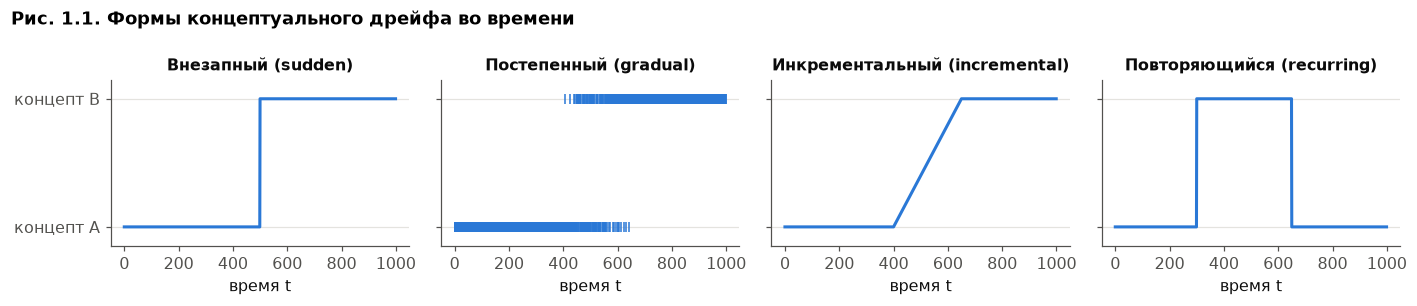

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from scendrift.reporting.style import CATEGORICAL, apply_style

apply_style()
t = np.arange(1000)
illus_rng = np.random.default_rng(GLOBAL_SEED)
ramp = np.clip((t - 400) / 250, 0, 1)
panels = {
    "Внезапный (sudden)": (t >= 500).astype(float),
    "Постепенный (gradual)": (illus_rng.random(t.size) < ramp).astype(float),
    "Инкрементальный (incremental)": ramp,
    "Повторяющийся (recurring)": ((t >= 300) & (t < 650)).astype(float),
}
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharey=True)
for ax, (title, signal) in zip(axes, panels.items()):
    style = {"linestyle": "none", "marker": "|", "markersize": 6} if "gradual" in title else {}
    ax.plot(t, signal, color=CATEGORICAL[0], **style)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel("время t")
    ax.set_yticks([0, 1], ["концепт A", "концепт B"])
    ax.set_ylim(-0.15, 1.15)
    ax.grid(axis="x", visible=False)
fig.suptitle("Рис. 1.1. Формы концептуального дрейфа во времени", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("docs/figures/fig_1_1_drift_forms.png")
plt.show()

### 1.3. Методы обнаружения дрейфа [Т]

Детекторы с учителем получают поток индикаторов ошибки $e_t = \mathbb{1}[\hat y_t \neq y_t]$ базового классификатора и сигнализируют о существенном изменении частоты ошибок [1; 2]. Направленность у них разная:
- DDM, EDDM и HDDM_A/W реагируют только на рост ошибки;
- ADWIN, KSWIN и Page–Hinkley (в river по умолчанию `mode="both"`) — на изменение в обе стороны.

Семь детекторов, сравниваемых в работе, относятся к трём группам.

**1. Статистический контроль частоты ошибок.**
* **DDM** (Drift Detection Method) [21] моделирует число ошибок биномиальным законом. Он отслеживает минимум величины $p_t + s_t$, где $p_t$ — частота ошибок, $s_t = \sqrt{p_t(1 - p_t)/t}$. Предупреждение выдаётся при $p_t + s_t \ge p_{\min} + 2s_{\min}$, дрейф — при $p_t + s_t \ge p_{\min} + 3s_{\min}$.
* **EDDM** (Early DDM) [22] отслеживает расстояние между соседними ошибками. Это повышает чувствительность к медленному, постепенному дрейфу.
* **HDDM_A** и **HDDM_W** [23] сравнивают оценки средней ошибки до и после возможной точки изменения с помощью границ типа Хёффдинга. Вариант A использует обычные средние, вариант W — экспоненциально взвешенные (в river для W граница записана в форме Мак-Диармида). Предположений о виде распределения нет, нужна только ограниченность значений.

**2. Адаптивные окна и сравнение распределений.**
* **ADWIN** (ADaptive WINdowing) [24] хранит окно переменной длины. Если найдено разбиение окна на две части со статистически различными средними (граница Хёффдинга с уровнем $\delta$), устаревшая часть отбрасывается. Для ADWIN доказаны оценки вероятности ложного срабатывания и пропуска изменения, а также оценка задержки после резкого изменения.
* **KSWIN** (Kolmogorov–Smirnov WINdowing) [25] сравнивает критерием Колмогорова–Смирнова последние `stat_size` значений со случайной выборкой из более ранней части окна.

**3. Последовательный анализ.**
* **Page–Hinkley** [26] — вариант кумулятивных сумм (CUSUM). Накапливается сумма $M_T = \sum_{t \le T} (x_t - \bar x_t - \delta)$, и дрейф фиксируется, когда $M_T - \min_{t \le T} M_t > \lambda$. В river суммы затухают с коэффициентом забывания $\alpha$, по умолчанию проверяется изменение в обе стороны.

Гиперпараметры по умолчанию в river 0.26.1 [9] (используются в основном эксперименте):

| Детектор | Группа | Вход | Гиперпараметры по умолчанию (river 0.26.1) | Источник |
|---|---|---|---|---|
| ADWIN | окно | вещественный | `delta=0.002`, `clock=32`, `grace_period=10` | [24] |
| DDM | контроль ошибок | бинарный | `warm_start=30`, `warning_threshold=2.0`, `drift_threshold=3.0` | [21] |
| EDDM | контроль ошибок | бинарный | `warm_start=30`, `alpha=0.95`, `beta=0.9` | [22] |
| KSWIN | окно | вещественный | `alpha=0.005`, `window_size=100`, `stat_size=30` | [25] |
| Page–Hinkley | последов. анализ | вещественный | `min_instances=30`, `delta=0.005`, `threshold=50`, `alpha=0.9999`, `mode="both"` | [26] |
| HDDM_A | контроль ошибок | ограниченный (в river — `HDDMA`, бинарный) | `drift_confidence=0.001`, `warning_confidence=0.005`, `two_sided_test=False` | [23] |
| HDDM_W | контроль ошибок | ограниченный (в river — `HDDMW`, бинарный) | `drift_confidence=0.001`, `warning_confidence=0.005`, `lambda_val=0.05`, `two_sided_test=False` | [23] |

Известно, что результаты сравнения детекторов существенно зависят от свойств тестовых потоков и от протокола оценки [18; 19; 27]. В частности:
- Barros и Santos сравнили 14 детекторов на большом числе вручную сконфигурированных синтетических потоков [18];
- Bifet показал, что популярный протокол «accuracy при перезапуске классификатора» может создавать «иллюзию прогресса» [27].

Для оценки качества обнаружения относительно истинных моментов изменения в CD-MOA предложены метрики [10]:
- MTFA — среднее время между ложными тревогами;
- MTD — среднее время до обнаружения;
- MDR — доля пропущенных изменений;
- MTR — их сводное отношение.

Эти наблюдения мотивируют главное требование к бенчмарку: систематически варьировать свойства сценария и знать истинную разметку.

### 1.4. Бенчмарки, генераторы потоков и средства оценки детекторов [Т]

**Программные средства.**

- **MOA** [28; 13] — эталонная платформа на Java. Её состав:
  - генераторы SEA [29], Agrawal [30], STAGGER [31], вращающаяся гиперплоскость [32] и др.;
  - обёртка `ConceptDriftStream` с сигмоидным переходом (позиция, ширина), которую можно вкладывать саму в себя;
  - 15 детекторов;
  - модуль CD-MOA с метриками MTFA, MTD, MDR и MTR [10];
  - экспериментатор со статистическими тестами.
- **scikit-multiflow** [33] перенёс генераторы и детекторы MOA на Python и в 2020 г. влился в **river** [9]. River — основная Python-библиотека для потоков: 19 синтетических генераторов, `ConceptDriftStream`, детекторы ADWIN, DDM, EDDM, FHDDM [34], HDDM_A/W, KSWIN и Page–Hinkley с единым интерфейсом. Метрик качества обнаружения, экспорта ground truth и описания сценариев в river нет.
- **CapyMOA** [35] — Python-обёртка над MOA:
  - сценарий собирается декларативно из чередующихся концептов и переходов (`DriftStream`), моменты дрейфа выдаются методом `get_drifts()`;
  - оценщик `EvaluateDriftDetector` считает precision, recall, F1, задержку и частоту ложных тревог.
- **stream-learn** [36]: генератор `StreamGenerator` одним вызовом задаёт число дрейфов, их резкость, инкрементальность и повторяемость, шум меток и (в том числе динамический) дисбаланс. Однако позиции дрейфов всегда равноотстоящие, а величину дрейфа концепта задать нельзя: каждый новый концепт случаен.
- **Frouros** [37] и **Menelaus** [38] — библиотеки детекторов. В Frouros генерации сценариев почти нет. В Menelaus в ветке разработки есть операторы внедрения дрейфа в реальные данные: ковариатного, реального и априорного, на заданном окне.
- **Генератор Петижана–Уэбба для MOA** [5] к работе [3] порождает категориальные потоки с внезапным дрейфом заданной величины (расстояние Хеллингера) раздельно для $P(X)$ и $P(y \mid X)$. Величина достигается итерационным подбором с допуском.

Сравнение по признакам, существенным для автоматического бенчмаркинга, приведено ниже. Оно составлено по исходному коду и документации актуальных версий (октябрь 2026 г.). Обозначения: ✔ — есть, ◐ — частично, ✘ — нет.

| Признак | MOA + CD-MOA | scikit-multiflow | river | CapyMOA | stream-learn | Frouros | Menelaus | генератор Петижана–Уэбба | **scendrift** |
|---|---|---|---|---|---|---|---|---|---|
| Формы: sudden / gradual / incremental / recurring | ✔ | ◐ | ◐ | ✔ | ✔ | ◐ | ◐ | ◐ (только sudden) | ✔ |
| Явный вид дрейфа (real / virtual / prior) | ◐ | ✘ | ◐ | ◐ | ◐ | ◐ | ✔ | ◐ (без prior) | ✔ |
| Величина с измеримой семантикой | ◐ | ◐ | ◐ | ◐ | ✘ | ✘ | ◐ | ✔ (Хеллингер) | ✔ (TV, аналитически) |
| Ground truth как данные | ◐ (только CD-MOA) | ✘ | ◐ | ✔ | ◐ | ✘ | ◐ | ◐ | ✔ |
| Декларативный сценарий | ◐ (строка CLI) | ✘ | ✘ | ◐ (Python-список) | ✘ | ✘ | ✘ | ◐ (строка CLI) | ✔ (YAML / JSON Schema) |
| Ограничения допустимости сценария | ◐ | ◐ | ◐ | ◐ | ◐ | ◐ | ◐ | ◐ | ✔ (C1–C14) |
| Автоматическое формирование наборов | ◐ (один параметр) | ✘ | ✘ | ✘ | ✘ | ✘ | ✘ | ✘ | ✔ (этап 3) |
| Метрики обнаружения (задержка, ложные тревоги) | ◐ | ✘ | ✘ | ✔ | ◐ | ✘ | ✘ | ✘ | ✔ (этап 4) |
| Статистическое сравнение детекторов | ✔ | ✘ | ✘ | ✘ | ✘ | ✘ | ✘ | ✘ | ✔ (этап 4) |

**Исследовательские бенчмарки.**
- Barros и Santos сравнили детекторы на большом числе вручную сконфигурированных искусственных потоков с двумя базовыми классификаторами [18]. Gonçalves и др. сравнили восемь детекторов [19].
- Aguiar и Cano построили полным перебором 2760 потоков с дрейфом разной локальности и сравнили 9 детекторов [7]. Brzezinski и др. систематически варьировали факторы сложности несбалансированных потоков [39].
- Cerqueira и др. (2026) предложили каркас оценки детекторов [8]: внедрение в реальные данные изменений четырёх типов со случайными (Монте-Карло) параметрами, метрики с учётом времени и подбор гиперпараметров.
- Žliobaitė предложила контролируемые перестановки для получения множества тестовых наборов [40].
- Зависимость качества обнаружения от свойств изменения изучалась по отдельным параметрам: от размерности при фиксированной величине [41], от доли затронутой подгруппы [42], от величины и доли затронутых данных в пакетной постановке [43].
- Souza и др. показали ограничения бенчмарков на реальных данных: истинные моменты дрейфа в них неизвестны [44].

### 1.5. Анализ пробелов и постановка задачи [К+Т]

Из обзора следует пять пробелов.

1. **Нет общей семантики величины дрейфа.** У большинства генераторов «величина» — внутренний параметр, несопоставимый между генераторами и видами дрейфа. Калиброванная величина известна для категориальных данных и внезапного дрейфа (генератор Петижана–Уэбба, расстояние Хеллингера, итерационный подбор) и для ковариатного сдвига (Carrera и Boracchi, дивергенция Кульбака–Лейблера, итерационный подбор) [5; 6]. Единой шкалы для реального, виртуального и априорного дрейфа с аналитической калибровкой в проанализированных источниках не выявлено.
2. **Сценарий не является проверяемым объектом.** В MOA, river и CapyMOA проверяется только структура описания и диапазоны отдельных опций. Недостижимые сочетания параметров (большая величина при малой доле затронутых признаков, конфликт дисбаланса и величины, перекрытие переходов) молча порождают не тот поток, который заявлен.
3. **Наборы сценариев формируются вручную, полным перебором [7] или случайной выборкой [8].** Пространственно-заполняющие планы (латинский гиперкуб [45], последовательности Соболя [46]) с учётом ограничений допустимости для этой цели в проанализированных источниках не применялись.
4. **Генерация, метрики и статистика разнесены по разным инструментам.** CD-MOA даёт метрики, но три одномерных генератора. CapyMOA даёт сценарии и метрики, но не статистику. River даёт детекторы, но не оценку.
5. **Области отказа детекторов изучаются по одному параметру за раз** [41; 42], без описания многопараметрических областей в пространстве сценариев. Методологический прецедент интерпретируемого описания «где алгоритм работает плохо» есть в анализе пространства экземпляров для статических задач [47].

**Постановка задачи.** Требуется фреймворк, который делает четыре вещи:
1. описывает сценарий дрейфа формальным кортежем параметров с единой калиброванной шкалой величины и проверяемыми ограничениями (пробелы 1–2);
2. автоматически формирует наборы сценариев по планам эксперимента с учётом ограничений (пробел 3);
3. в одном конвейере порождает потоки с ground truth, прогоняет детекторы river, вычисляет метрики обнаружения и выполняет статистическое сравнение (пробел 4);
4. позволяет описывать области отказа детекторов в пространстве параметров сценария (пробел 5).

## 2. Формальная модель сценария [К] (п. 2.6 — [Т])

В разделе вводится формальное определение сценария дрейфа. Задаются семантика его параметров, единая шкала величины, пространство параметров, таксономия и ограничения валидности. Протокол оценки и метрики формализованы в п. 2.6.

Утверждения раздела проверяются численно методом Монте-Карло. Проверочные ячейки используют только numpy и scipy и не зависят от реализации фреймворка (раздел 4), поэтому служат независимой проверкой формул.

**Обозначения.**
- События нумеруются с единицы: $e_1, \dots, e_K$.
- Концепт $c_0$ — исходный, концепт $c_k$ возникает после события $e_k$.
- В коде и в таблицах вывода индексы событий начинаются с нуля, как принято в Python.

### 2.1. Поток данных и концептуальный дрейф

**Поток данных** — последовательность $(x_t, y_t)$, $t = 1, \dots, n$, где $x_t \in \mathbb{R}^d$, $y_t \in \{0, 1\}$, а пара $(x_t, y_t)$ порождается распределением $P_t(X, y)$.

**Концепт** — совместное распределение $P_t(X, y)$ [1]. **Концептуальный дрейф** между моментами $t$ и $u$ — неравенство $P_t(X, y) \neq P_u(X, y)$.

Используются два разложения совместного распределения:
$$P(X, y) = P(X)\,P(y \mid X) = P(y)\,P(X \mid y).$$
От того, какая компонента меняется, зависит вид дрейфа [20; 3]:
- реальный дрейф (real) — меняется $P(y \mid X)$;
- виртуальный (virtual, covariate shift) — меняется только $P(X)$;
- дрейф априорных вероятностей (prior, label shift) — меняется $P(y)$ при неизменном распределении $P(X \mid y)$.

### 2.2. Определение сценария

**Определение 1 (сценарий дрейфа).** Сценарий — кортеж
$$S = \langle B, E, \Omega, s \rangle,$$
где:

* $B = (f, n, d, \pi_0, \eta, c)$ — базовая конфигурация потока:
  - $f$ — семейство генератора;
  - $n$ — длина потока;
  - $d$ — размерность;
  - $\pi_0 \in [0{,}01;\,0{,}5]$ — исходная доля положительного (миноритарного) класса;
  - $\eta \in [0;\,0{,}5)$ — вероятность инверсии метки;
  - $c$ — **структурный seed**.
* $E = (e_1, \dots, e_K)$ — упорядоченный список событий дрейфа. Событие $e_k = (\tau_k, \ell_k, \varphi_k, \kappa_k, m_k, \alpha_k, \rho_k)$:
  - $\tau_k$ — центр перехода;
  - $\ell_k$ — ширина перехода;
  - $\varphi_k \in \{\text{sudden}, \text{gradual}, \text{incremental}\}$ — форма перехода;
  - $\kappa_k \in \{\text{real}, \text{virtual}, \text{prior}\}$ — вид;
  - $m_k \in (0, 1]$ — величина;
  - $\alpha_k \in (0, 1]$ — доля затронутых признаков;
  - $\rho_k$ — номер концепта, к которому поток возвращается (повторяющийся дрейф).
* $\Omega$ — протокол оценки (п. 2.6).
* $s$ — **seed реализации**.

Интервал перехода события — полуинтервал $[\mathrm{onset}_k, \mathrm{end}_k)$, где $\mathrm{onset}_k = \tau_k - \lfloor \ell_k/2 \rfloor$ и $\mathrm{end}_k = \mathrm{onset}_k + \ell_k$. Положение объекта внутри перехода задаёт функция перехода $p_k(t)$: она растёт от 0 до 1, бывает линейной или сигмоидной.

Формы перехода различаются так:
- **внезапный** дрейф (sudden, $\ell_k = 0$) — концепт меняется мгновенно;
- **постепенный** (gradual) — объект порождается новым концептом с вероятностью $p_k(t)$, иначе старым;
- **инкрементальный** (incremental) — параметры концепта непрерывно меняются от $c_{k-1}$ к $c_k$:
  - угол поворота нормали $\psi(t) = p_k(t)\,\psi_k$;
  - сдвиг $\delta(t) = p_k(t)\,\delta_k$;
  - доля класса $\pi(t) = (1 - p_k(t))\,\pi_{k-1} + p_k(t)\,\pi_k$.

**Повторяющийся** дрейф (recurring) не считается отдельной формой. Это событие с заданным $\rho_k$, то есть возврат к ранее встречавшемуся концепту, а сам возврат может быть внезапным или постепенным. Так виды дрейфа во времени [1] раскладываются на две независимые оси: форма перехода и повторяемость.

**Определение 2 (генератор).** Генератор семейства $f$ — детерминированное отображение
$$\Gamma_f : S \mapsto (X_{1..n},\ y_{1..n},\ G),$$
где $G$ — истинная разметка дрейфа (ground truth, п. 2.5).

**Два seed вместо одного.** Структурный seed $c$ задаёт геометрию концептов: какие признаки затронуты, направления поворота и сдвига, случайное расписание. Seed реализации $s$ задаёт выборку объектов и шум. Отсюда два следствия:
1. повторы сценария с разными $s$ имеют одни и те же концепты, а значит, одну и ту же истинную величину дрейфа;
2. проверку допустимости можно выполнить заранее, не порождая данных.

### 2.3. Семантика величины дрейфа: единая шкала

Параметр «величина дрейфа» в существующих генераторах обычно не имеет общей семантики. Это:
- номер варианта (функции классификации), на который переключается генератор SEA [29] или Agrawal [30];
- скорость вращения гиперплоскости [32];
- иной внутренний параметр генератора.

Поэтому нельзя сказать, что дрейф величины 0,2 в одном потоке «такой же», как в другом.

Идея измерять величину расстоянием между распределениями не нова:
- Webb и соавторы определяют magnitude через расстояние Хеллингера [3], а генератор Петижана–Уэбба для MOA подбирает категориальные распределения под заданное расстояние Хеллингера [5];
- Carrera и Boracchi итерационно калибруют ротрансляцию гауссовых данных под заданную дивергенцию Кульбака–Лейблера [6].

В этой работе величина определяется **одной метрикой для всех трёх видов дрейфа** — расстоянием полной вариации между совместными распределениями. Для калиброванного семейства она обращается аналитически.

**Семейство `hyperplane_gauss`.** Концепт $k$ задаётся состоянием $(w_k, \mu_k, \pi_k)$:
- $w_k$ — единичная нормаль, $\|w_k\| = 1$;
- $\mu_k$ — центр базового распределения признаков $\mathcal{N}(\mu_k, I)$;
- $\pi_k$ — текущая доля положительного класса.

Метка задаётся правилом
$$g_k(x) = \mathbb{1}\left[w_k^\top (x - \mu_k) > z\right], \qquad z = \Phi^{-1}(1 - \pi_0).$$
Объекты порождаются по схеме label shift: сначала $y \sim \mathrm{Bernoulli}(\pi_k)$, затем $x \mid y$ из $\mathcal{N}(\mu_k, I)$, усечённого на полупространство класса $y$. Затем метка с вероятностью $\eta$ инвертируется. Плотность $P_k(X)$ — это $\mathcal{N}(\mu_k, I)$, перевзвешенная множителями $\pi_k/\pi_0$ и $(1-\pi_k)/(1-\pi_0)$ на полупространствах классов. В исходном концепте $w_0 = \mathbf{1}/\sqrt{d}$ (все признаки одинаково информативны), $\mu_0 = 0$.

Каждый вид дрейфа меняет **ровно одну группу параметров** концепта. Что при этом происходит с распределениями (для чистых меток):

| Вид | Преобразование | Меняется | Сохраняется |
|---|---|---|---|
| real | поворот $w$ на угол $\psi$ внутри подпространства затронутых признаков $A$ | $P(y \mid X)$ | $P(y)$; $P(X)$ — при $\pi_k = \pi_0$ (см. W3) |
| virtual | сдвиг $\mu \to \mu + \delta v$, $v \perp w$, $\operatorname{supp} v \subseteq A$ | $P(X)$ | $P(y \mid X)$, $P(y)$ |
| prior | $\pi_k \to \pi_{k+1}$ | $P(y)$ | $P(X \mid y)$, $P(y \mid X)$ |

Две оговорки:
1. Если до реального дрейфа был prior-дрейф ($\pi_k \neq \pi_0$), то поворот нормали меняет и $P(X)$: перевзвешивание классов «переезжает» вместе с границей. Валидатор отмечает такие события предупреждением W3, поскольку это существенно для детекторов, отслеживающих только признаки.
2. При шуме меток $\eta > 0$ prior-дрейф меняет и наблюдаемое распределение $P(X \mid \tilde y)$ для зашумлённой метки $\tilde y$.

**Определение 3 (величина дрейфа).** Величина обычного события $e_k$ — расстояние полной вариации (total variation, TV) между совместными распределениями чистых данных до и после события:
$$m_k = \mathrm{TV}\big(P_{k-1}(X, y),\, P_k(X, y)\big) = \tfrac12 \sum_{y} \int \big|p_{k-1}(x, y) - p_k(x, y)\big|\,dx.$$

**Утверждение 1 (единая шкала).** Для каждого вида TV имеет точную форму:
- real: $m = P_{x \sim P_{k-1}}\big(g_{k-1}(x) \neq g_k(x)\big)$ — вероятностная мера той части входного пространства, где меняется метка. Это адаптация понятия severity из [4] на неограниченное пространство признаков.
- virtual: $m = 2\Phi(\delta/2) - 1$, где $\delta$ — норма сдвига.
- prior: $m = |\pi_k - \pi_{k-1}|$.

*Набросок доказательства.*
- **real.** Для выборки из $P_{k-1}$ выполняется $p_k(x, y)/p_{k-1}(x, y) = \mathbb{1}[g_k(x) = y]$: множители классов и нормировки совпадают, потому что базовые доли $P(g = 1)$ при повороте не меняются. Отсюда $\mathrm{TV} = P_{k-1}(g_k \neq y) = P_{k-1}(g_{k-1} \neq g_k)$, в том числе при $\pi_k \ne \pi_0$.
- **virtual.** Плотность раскладывается в произведение компоненты вдоль $w$ (от неё зависит класс) и независимой гауссовой компоненты в $w^\perp$. Сдвиг затрагивает только вторую, поэтому TV совпадает с TV двух гауссиан, сдвинутых на $\delta$.
- **prior.** Классы занимают непересекающиеся полупространства, а $P(X \mid y)$ не меняется, поэтому $\mathrm{TV} = \tfrac12 \sum_y |\pi^{(y)}_{k} - \pi^{(y)}_{k-1}| = |\Delta \pi|$.

$\square$

**Утверждение 2 (калибровка реального дрейфа).** При повороте нормали на угол $\theta$
$$m(\theta) = \big(\pi_0 - \Phi_2(-z, -z;\, \cos\theta)\big)\left(\frac{\pi_k}{\pi_0} + \frac{1 - \pi_k}{1 - \pi_0}\right),$$
где $\Phi_2(\cdot,\cdot;\rho)$ — функция распределения стандартного двумерного нормального закона с корреляцией $\rho$. При $\pi_0 = \pi_k = 1/2$ отсюда следует $m = \theta/\pi$. Это тот же геометрический факт, что и вероятность разделения двух векторов случайной гиперплоскостью [12].

*Набросок доказательства.* Величины $u = w_{k-1}^\top(x - \mu)$ и $v = w_k^\top(x - \mu)$ имеют стандартное двумерное нормальное распределение с корреляцией $\cos\theta$. Тогда $P(u > z,\ v \le z) = \pi_0 - \Phi_2(-z, -z; \cos\theta)$, а перевзвешивание классов даёт множитель в скобках. $\Phi_2$ вычисляется точно, через T-функцию Оуэна [48]. $\square$

**Утверждение 3 (обратимость).** Функция $m(\theta)$ строго возрастает на $[0, \pi]$, потому что $\partial \Phi_2 / \partial \rho > 0$ (формула Плакетта [49]). Следовательно, для любой достижимой величины $m$ угол $\theta$ единствен и находится методом Брента.

**Утверждение 4 (ограничение доли затронутых признаков).** При повороте на угол $\psi$ внутри подпространства $A$ с сохранением нормы $\|w_A\|$
$$\cos\theta = 1 - q\,(1 - \cos\psi), \qquad q = \|w_A\|^2.$$
Отсюда наибольший угол $\theta_{\max} = \arccos(1 - 2q)$ и наибольшая достижимая величина $m_{\max} = m(\theta_{\max})$ (ограничение C10). Для исходного концепта $q = |A|/d \approx \alpha$. Например, при $\alpha = 0{,}3$ и балансе классов $m_{\max} = \arccos(0{,}4)/\pi \approx 0{,}369$.

**Утверждение 5 (калибровка виртуального дрейфа).** Сдвиг заданной величины $m$ — это $\delta = 2\Phi^{-1}\big((1 + m)/2\big)$. Расстояние Хеллингера $H$, которое используют Webb и соавторы, связано с TV неравенствами $H^2 \le \mathrm{TV} \le H\sqrt{2 - H^2}$. Мы выбираем TV, потому что только эта метрика даёт одну и ту же шкалу для всех трёх видов.

**Утверждение 6 (наблюдаемость реального дрейфа при шуме меток).** Классификатор, оптимальный для концепта $c_{k-1}$, на зашумлённых метках концепта $c_k$ ошибается с вероятностью $\eta + m(1 - 2\eta)$. Значит, прирост ошибки равен $m_{\text{eff}} = m\,(1 - 2\eta)$, и TV для зашумлённых данных — тоже $m(1-2\eta)$. Утверждение относится только к реальному дрейфу:
- при виртуальном и prior-дрейфе правило разметки не меняется, и ошибка старого классификатора остаётся равной $\eta$;
- TV зашумлённых данных для этих видов не зависит от $\eta$.

Отсюда предупреждение W1.

Для **повторяющегося** события величина не задаётся, а вычисляется. Переход раскладывается по группам параметров:
$$\tilde m = (m_{\text{real}}, m_{\text{virtual}}, m_{\text{prior}}),$$
где
- $m_{\text{real}}$ — доля смены метки;
- $m_{\text{virtual}}$ — TV между базовыми распределениями $\mathcal{N}(\mu, I)$;
- $m_{\text{prior}} = |\Delta\pi|$.

#### Численная проверка утверждений (Монте-Карло, независимо от кода фреймворка)

Каждая проверка строит выборку прямо из определения модели и сравнивает оценку с формулой. Допуск для каждой строки — четыре стандартные ошибки **этой** оценки:
- для долей — $\sqrt{\hat p(1-\hat p)/n}$;
- для TV — выборочное стандартное отклонение подынтегральной величины, делённое на $\sqrt n$.

Для угла $\theta_{\max}$ проверка точная.

In [6]:
import math

import numpy as np
import pandas as pd
from scipy.special import ndtri
from scipy.stats import multivariate_normal

rng = np.random.default_rng(GLOBAL_SEED)


def phi2(h: float, k: float, rho: float) -> float:
    """Φ₂(h, k; ρ) средствами scipy (независимо от реализации фреймворка)."""
    rho = min(1 - 1e-7, max(-1 + 1e-7, rho))  # scipy требует невырожденную ковариацию
    return float(multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]]).cdf([h, k]))


def formula_real(theta: float, pi0: float, prior: float) -> float:
    z = ndtri(1 - pi0)
    return (pi0 - phi2(-z, -z, math.cos(theta))) * (prior / pi0 + (1 - prior) / (1 - pi0))


def sample_label_shift(w, z, prior, n, d):
    """x | y по схеме label shift через отбор из N(0, I) (без формул модели)."""
    out = []
    count1 = int(rng.binomial(n, prior))
    for cls, count in ((1, count1), (0, n - count1)):
        got = []
        while sum(len(g) for g in got) < count:
            x = rng.standard_normal((4 * count + 1000, d))
            got.append(x[((x @ w) > z) == bool(cls)])
        out.append(np.vstack(got)[:count])
    return np.vstack(out)


def rotate_in_plane(w, theta, d):
    u = rng.standard_normal(d)
    u -= (u @ w) * w
    u /= np.linalg.norm(u)
    return math.cos(theta) * w + math.sin(theta) * u


def share_row(name, cond, flags, ref):
    est = float(np.mean(flags))
    return (name, cond, est, ref, 4 * math.sqrt(max(est * (1 - est), 1e-12) / flags.size))


rows, n_mc, d = [], 200_000, 8
w = np.ones(d) / math.sqrt(d)
for pi0, prior, theta in [(0.5, 0.5, 0.6), (0.5, 0.5, 2.0), (0.2, 0.2, 0.8), (0.1, 0.4, 1.2)]:
    z = ndtri(1 - pi0)
    x = sample_label_shift(w, z, prior, n_mc, d)
    w2 = rotate_in_plane(w, theta, d)
    ref = theta / math.pi if pi0 == prior == 0.5 else formula_real(theta, pi0, prior)
    rows.append(share_row("Утв. 1–2: real, TV = доля смены метки",
                          f"π₀={pi0}, π={prior}, θ={theta}", ((x @ w) > z) != ((x @ w2) > z), ref))

# Утверждение 4: поворот внутри A, |A| = 3 из 10, ψ = π (предельный)
d4, k4 = 10, 3
w4 = np.ones(d4) / math.sqrt(d4)
q = k4 / d4
w4_rot = w4.copy()
w4_rot[:k4] = -w4[:k4]  # поворот на ψ = π внутри A
rows.append(("Утв. 4: θ_max", "α=0,3, ψ=π", math.acos(w4 @ w4_rot), math.acos(1 - 2 * q), 1e-12))
x = rng.standard_normal((n_mc, d4))
rows.append(share_row("Утв. 4: m_max", "α=0,3, баланс", ((x @ w4) > 0) != ((x @ w4_rot) > 0),
                      math.acos(1 - 2 * q) / math.pi))

# Утверждения 1 (virtual) и 5: TV = E_p[(1 − q/p)⁺] при перевзвешивании классов
for m_target, prior in [(0.3, 0.5), (0.6, 0.2)]:
    delta = 2 * ndtri((1 + m_target) / 2)
    x = sample_label_shift(w, 0.0, prior, n_mc, d)
    v = rng.standard_normal(d)
    v -= (v @ w) * w
    v /= np.linalg.norm(v)
    # множители классов в q/p сокращаются, т.к. сдвиг ⊥ w
    integrand = np.clip(1 - np.exp(delta * (x @ v) - delta**2 / 2), 0, None)
    rows.append(("Утв. 1, 5: virtual, TV", f"m={m_target}, π={prior}", integrand.mean(), m_target,
                 4 * integrand.std() / math.sqrt(n_mc)))

# Утверждение 1 (prior): TV совместных распределений = |Δπ|
p_from, p_to = 0.5, 0.8
y = rng.random(n_mc) < p_from
ratio = np.where(y, p_to / p_from, (1 - p_to) / (1 - p_from))  # P(X|y) не меняется
integrand = np.clip(1 - ratio, 0, None)
rows.append(("Утв. 1: prior, TV", "π: 0,5 → 0,8", integrand.mean(), abs(p_to - p_from),
             4 * integrand.std() / math.sqrt(n_mc)))

# Утверждение 6: прирост ошибки старого концепта на зашумлённых метках нового (real)
eta, theta = 0.15, 0.9
x = rng.standard_normal((n_mc, d))
w6 = rotate_in_plane(w, theta, d)
y_new = ((x @ w6) > 0).astype(int)
y_noisy = np.where(rng.random(n_mc) < eta, 1 - y_new, y_new)
err = ((x @ w) > 0).astype(int) != y_noisy
row = share_row("Утв. 6: real, m_eff", f"η={eta}, m={theta / math.pi:.3f}", err,
                eta + theta / math.pi * (1 - 2 * eta))
rows.append((row[0], row[1], row[2] - eta, row[3] - eta, row[4]))

check = pd.DataFrame(rows, columns=["утверждение", "условия", "Монте-Карло", "формула", "допуск (4·SE)"])
check["|разность|"] = (check["Монте-Карло"] - check["формула"]).abs()
check["ок"] = check["|разность|"] <= check["допуск (4·SE)"]
assert check["ок"].all(), check
check.round(5)

,утверждение,условия,Монте-Карло,формула,допуск (4·SE),|разность|,ок
0,"Утв. 1–2: real, TV = доля смены метки","π₀=0.5, π=0.5, θ=0.6",0.19132,0.19099,0.00352,0.00034,True
1,"Утв. 1–2: real, TV = доля смены метки","π₀=0.5, π=0.5, θ=2.0",0.63674,0.63662,0.00430,0.00012,True
2,"Утв. 1–2: real, TV = доля смены метки","π₀=0.2, π=0.2, θ=0.8",0.17564,0.17516,0.00340,0.00048,True
3,"Утв. 1–2: real, TV = доля смены метки","π₀=0.1, π=0.4, θ=1.2",0.35210,0.35149,0.00427,0.00060,True
4,Утв. 4: θ_max,"α=0,3, ψ=π",1.15928,1.15928,0.00000,0.00000,True
5,Утв. 4: m_max,"α=0,3, баланс",0.36945,0.36901,0.00432,0.00044,True
6,"Утв. 1, 5: virtual, TV","m=0.3, π=0.5",0.29984,0.30000,0.00260,0.00016,True
7,"Утв. 1, 5: virtual, TV","m=0.6, π=0.2",0.59895,0.60000,0.00333,0.00105,True
8,"Утв. 1: prior, TV","π: 0,5 → 0,8",0.29948,0.30000,0.00268,0.00052,True
9,"Утв. 6: real, m_eff","η=0.15, m=0.286",0.20022,0.20054,0.00427,0.00032,True


Все утверждения подтверждаются в пределах статистической погрешности. На рисунке ниже — калибровочная кривая $m(\theta)$ и область достижимых величин $m_{\max}(\alpha)$ для поворота внутри $A$ при разной доле положительного класса $\pi_0$.

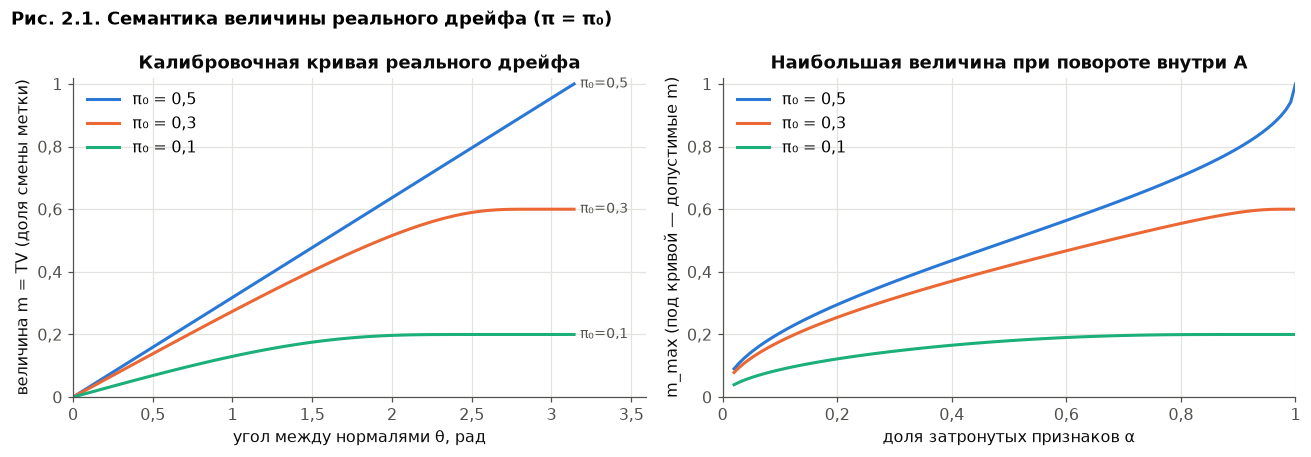

In [7]:
import matplotlib.pyplot as plt

from scendrift.reporting.style import CATEGORICAL, TEXT_SECONDARY, apply_style, decimal_comma

apply_style()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
thetas = np.linspace(0, math.pi, 120)
alphas = np.linspace(0.02, 1.0, 120)
for color, pi0 in zip(CATEGORICAL, [0.5, 0.3, 0.1]):
    curve = [formula_real(t, pi0, pi0) for t in thetas]
    axes[0].plot(thetas, curve, color=color, label=f"π₀ = {pi0}".replace(".", ","))
    axes[0].annotate(f"π₀={pi0}".replace(".", ","), (thetas[-1], curve[-1]), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=9, color=TEXT_SECONDARY)
    m_max = [formula_real(math.acos(1 - 2 * a), pi0, pi0) for a in alphas]
    axes[1].plot(alphas, m_max, color=color, label=f"π₀ = {pi0}".replace(".", ","))
axes[0].set(title="Калибровочная кривая реального дрейфа",
            xlabel="угол между нормалями θ, рад", ylabel="величина m = TV (доля смены метки)",
            xlim=(0, math.pi + 0.45), ylim=(0, 1.02))
axes[1].set(title="Наибольшая величина при повороте внутри A",
            xlabel="доля затронутых признаков α", ylabel="m_max (под кривой — допустимые m)",
            xlim=(0, 1), ylim=(0, 1.02))
for ax in axes:
    ax.legend(loc="upper left")
decimal_comma(*axes)
fig.suptitle("Рис. 2.1. Семантика величины реального дрейфа (π = π₀)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("docs/figures/fig_2_1_severity.png")
plt.show()

Из рис. 2.1 следуют два вывода, существенных для формирования сценариев:

1. При дисбалансе классов (малое $\pi_0$) та же величина требует большего угла поворота, а наибольшая величина ограничена: при полном развороте $m_{\max} = 2\pi_0$ для $\pi = \pi_0$. Поэтому дисбаланс и величину нельзя выбирать независимо, если не делать проверку.
2. В принятой модели (поворот нормали внутри $A$ с сохранением $\|w_A\|$) величина реального дрейфа ограничена сверху значением $m_{\max}(\alpha)$, которое растёт с долей затронутых признаков $\alpha$. Генератор этого семейства без проверки молча выдал бы дрейф меньшей величины, чем заявлено, а в нашем фреймворке это нарушение C10.

   Другие преобразования весов (например, растяжение $w_A$ без сохранения нормы) дают иные ограничения: это свойство выбранной параметризации, а не дрейфа вообще.

### 2.4. Пространство параметров и таксономия сценариев

Параметризованное семейство сценариев задаётся отображением $\xi \mapsto S(\xi)$ точек пространства параметров
$$\Xi = \Xi_1 \times \dots \times \Xi_D$$
в сценарии. Оно реализуется на этапе 3. Таблица пространства по умолчанию для семейства `hyperplane_gauss` строится из кода (`DEFAULT_SPACE`) при сборке ноутбука:

| Параметр | Обозн. | Часть | Домен | По умолч. | Активен, если |
|---|---|---|---|---|---|
| длина потока | n | stream | {10000, …, 50000} | 20000 | всегда |
| размерность пространства признаков | d | stream | {2, …, 50}, лог. | 10 | всегда |
| исходная доля положительного класса P(y=1) | π | stream | [0,05; 0,5] | 0,5 | всегда |
| вероятность инверсии метки | η | stream | [0; 0,3] | 0,0 | всегда |
| число событий дрейфа | K | schedule | {1, …, 5} | 1 | всегда |
| чередование концептов A → B → A → … | alt | schedule | {False, True} | False | n_drifts ≥ 2 |
| форма перехода | φ | event | {sudden, gradual, incremental} | sudden | всегда |
| ширина перехода | ℓ | event | {100, …, 4000}, лог. | 1000 | form ∈ {gradual, incremental} |
| вид дрейфа (какая компонента P(X, y) меняется) | κ | event | {real, virtual, prior} | real | всегда |
| величина дрейфа | m | event | [0,02; 0,5] | 0,2 | всегда |
| доля признаков, затронутых дрейфом | α | event | [0,2; 1] | 1,0 | kind ∈ {real, virtual} |
| длина разогрева | W | evaluation | {1000} | 1000 | всегда |
| окно допуска обнаружения | Δ | evaluation | {2000} | 2000 | всегда |

Разогрев $W$ и окно допуска $\Delta$ зафиксированы протоколом оценки.

Условные параметры (например, ширина $\ell$ при внезапном дрейфе) в неактивном состоянии получают значение по умолчанию. Их координата в плане эксперимента при этом сохраняется, чтобы не нарушить стратификацию латинского гиперкуба и равномерность последовательности Соболя по остальным координатам.

**Таксономия.** Каждый сценарий относится к классам по восьми осям, и по ним группируются результаты бенчмарка. Все величины измеряются в TV, поэтому ось «величина» сравнивает события разных видов на одной шкале.

| Ось | Классы |
|---|---|
| вид | real / virtual / prior (и их сочетания) |
| форма | sudden / gradual / incremental |
| повторяемость | есть возврат / нет |
| величина | low ($m < 0{,}1$) / medium ($0{,}1 \le m < 0{,}3$) / high ($m \ge 0{,}3$) |
| скорость | abrupt ($\ell = 0$) / fast ($\ell < \Delta/2$) / slow ($\ell \ge \Delta/2$) |
| охват | global ($\alpha = 1$ у всех событий real и virtual) / partial / n/a (таких событий нет) |
| баланс | balanced ($\pi_0 \ge 0{,}4$) / imbalanced |
| шум | clean ($\eta = 0$) / noisy |

Пороги — договорённость авторов; они вынесены в константы модуля `taxonomy`.

### 2.5. Ограничения валидности и ground truth

Сценарий **допустим**, если не нарушено ни одно ограничение C1–C14:
- C1 и C3 проверяются при создании объекта: они не зависят от семейства;
- остальные проверяет валидатор с учётом возможностей семейства.

Пример зависимости от семейства — C2. Величина $m$ обязательна для **калиброванного** семейства (`hyperplane_gauss`, реальные данные): генератор строит поток по заданной TV. Для **некалиброванного** семейства (классические генераторы river) величина запрещена: смена концепта там — смена встроенной функции, а её TV не задаётся, а вычисляется (п. 4.5.1). Если разрешить $m$ для таких семейств, сценарий заявлял бы величину, которую генератор не реализует.

Предупреждения W1–W4 сценарий не отклоняют, но учитываются при интерпретации результатов. W4 относится только к реальным данным: там событие real или virtual может заметно изменить и $P(y)$ (п. 4.5.2). Таблица строится из каталога ограничений в коде (`CONSTRAINTS`):

| Код | Область проверки | Ограничение |
|---|---|---|
| C1 | событие | φ = sudden ⇔ ℓ = 0; при φ ∈ {gradual, incremental} ℓ ≥ 2; onset ≥ 0 |
| C2 | семейство | обычное событие: m ∈ (0, 1] задана для калиброванного семейства и не задана для некалиброванного (там m оценивается по данным) |
| C3 | событие | для повторяющегося события (ρ задано) κ и m не задаются |
| C4 | сценарий | onset₁ ≥ W: дрейф не начинается во время разогрева |
| C5 | сценарий | end_K + Δ ≤ n: после последнего перехода есть окно допуска |
| C6 | сценарий | onset_{k+1} ≥ end_k + Δ: следы событий [onset, end + Δ) не пересекаются |
| C7 | сценарий | ρ_k ≤ k − 1 (концепт уже существует), и возврат меняет распределение: c_{ρ_k} ≠ c_{k−1} |
| C8 | семейство | вид κ, форма φ, возврат и ключи family_params поддерживаются семейством f |
| C9 | семейство | число затронутых признаков ⌊α·d⌉ ≥ 2 (для κ ∈ {real, virtual}) |
| C10 | семейство | real: m ≤ m_max(q, π₀, π_k) — величина достижима поворотом внутри A |
| C11 | семейство | virtual: m ≤ 0,99 (TV < 1 при конечном сдвиге) |
| C12 | семейство | prior: новая доля P(y=1) лежит в [0,01; 0,99] |
| C13 | семейство | семейство f зарегистрировано в реестре |
| C14 | сценарий | W + Δ ≤ n: протокол оценки помещается в поток |
| W1 | предупреждение | real: m·(1 − 2η) < 0,02 — дрейф почти не наблюдаем на фоне шума меток |
| W2 | предупреждение | virtual: P(y\|X) не меняется, детекторы по ошибке могут его не видеть |
| W3 | предупреждение | real при π_k ≠ π₀: вместе с P(y\|X) меняется и P(X) (перевзвешивание классов) |
| W4 | предупреждение | реальные данные: событие real или virtual меняет и P(y) более чем на 0,02 |

Ограничение C6 гарантирует, что **окна допуска** $\Lambda_k = [\mathrm{onset}_k, \mathrm{end}_k + \Delta)$ разных событий не пересекаются. Поэтому любое срабатывание детектора однозначно относится не более чем к одному событию.

Ограничение C7 проверяет не только номер концепта, но и распределение. Возврат к концепту, который совпадает с текущим по всем параметрам, отклоняется: такое событие нельзя обнаружить, и оно исказило бы recall.

Исправление сценария (repair) работает так:
- если нарушены C9–C12, валидатор предлагает ближайшее допустимое значение (например, $m := m_{\max}$);
- если нарушены C4–C6, все события переносятся по равномерному расписанию. Свободное место делится поровну, поэтому раскладка допустима при любых ширинах переходов;
- если следы событий не помещаются в поток, последние события отбрасываются ($K$ уменьшается);
- если не помещается ни одно, исправление невозможно.

Эту процедуру использует модуль формирования сценариев (этап 3).

**Ground truth** сценария — набор записей
$$G = \{(\mathrm{onset}_k, \tau_k, \mathrm{end}_k, \varphi_k, \kappa_k, m_k, \tilde m_k)\}_{k=1}^{K},$$
где $\tilde m_k = (m_{\text{real}}, m_{\text{virtual}}, m_{\text{prior}})$ — **фактическая** величина события по группам параметров. Для обычного события ненулевая только компонента его вида, и она равна заданной $m_k$ (проверяется в п. 4.1 и в эксперименте Э1). Для повторяющегося события компоненты вычисляются.

### 2.6. Протокол оценки и формализация метрик [Т]

**Протокол оценки** $\Omega = (h, a, W, \Delta, r)$:
- $h$ — базовая онлайн-модель (по умолчанию гауссовский наивный байесовский классификатор из river [9]);
- $a \in \{\text{reset}, \text{none}\}$ — реакция на срабатывание детектора;
- $W$ — разогрев;
- $\Delta$ — окно допуска;
- $r \in \{\text{onset}, \text{center}\}$ — точка отсчёта задержки.

Оценка ведётся по схеме prequential (test-then-train) [50]. Сначала модель предсказывает $\hat y_t$, затем обучается на $(x_t, y_t)$. Детектор получает индикатор ошибки $e_t = \mathbb{1}[\hat y_t \ne y_t]$.

Пусть $\hat D = \{\hat t_1 < \hat t_2 < \dots\}$ — моменты срабатываний после разогрева, а $\Lambda_k$ — окно допуска события $k$.

**Правило сопоставления.**
- Событие $k$ **обнаружено** (TP), если $\hat D \cap \Lambda_k \neq \varnothing$. Его момент обнаружения $\hat t_k^* = \min(\hat D \cap \Lambda_k)$.
- Задержка при $r = \text{onset}$ — число объектов от начала перехода до срабатывания включительно: $\delta_k = \hat t_k^* - \mathrm{onset}_k + 1 \ge 1$.
- При $r = \text{center}$ задержка $\delta_k = \hat t_k^* - \tau_k$ может быть отрицательной: обнаружение до середины постепенного перехода.
- Иначе событие **пропущено** (FN).
- Срабатывания вне всех окон — **ложные тревоги** $FP_{\text{out}}$; повторные срабатывания внутри окна — **избыточные** $FP_{\text{red}}$.

Окна не пересекаются (C6), поэтому правило однозначно.

**Метрики** (по CD-MOA [10] с обобщением на несколько событий):

| Метрика | Определение |
|---|---|
| Precision / Recall / F1 | $P = TP / \lvert \hat D\rvert$, $R = TP / K$, $F_1 = 2PR/(P + R)$ |
| MDR (missed detection rate) | $FN / K = 1 - R$ |
| MTD (mean time to detection) | $\frac{1}{TP}\sum_{k \in TP} \delta_k$ |
| MTFA (mean time between false alarms) | $T_{\text{stable}} / FP_{\text{out}}$, где $T_{\text{stable}} = (n - W) - \sum_k \lvert \Lambda_k \rvert$ |
| MTR (mean time ratio) | $\dfrac{\text{MTFA}}{\text{MTD}}\,(1 - \text{MDR})$, только при $r = \text{onset}$ |
| FAR | $1000 \cdot FP_{\text{out}} / T_{\text{stable}}$ — ложные тревоги на 1000 объектов |
| Accuracy | prequential accuracy на $t \ge W$; $\Delta\mathrm{acc}$ относительно базовой линии без детектора и разрыв до «оракула», сбрасывающего модель в истинные моменты дрейфа |

Соглашения для вырожденных случаев:
- если срабатываний нет ($|\hat D| = 0$), precision не определена (NaN);
- при $TP = 0$ полагается $F_1 = 0$, а MTD и MTR не определены (NaN);
- если ложных тревог нет, MTFA и MTR равны $+\infty$; при агрегировании используется ограничение сверху $T_{\text{stable}}$.

Bifet показал, что оценка детектора по accuracy классификатора, который перезапускается при каждом срабатывании, вводит в заблуждение [27]. Из-за временной зависимости данных даже «детектор», не обнаруживающий изменений, может повышать accuracy. Отсюда три решения:
- основные метрики считаются относительно ground truth;
- accuracy используется как дополнительная характеристика;
- в число сравниваемых методов включаются базовые линии «без детектора» и «периодический сброс».

Детектор, срабатывающий слишком часто, может также получить высокий recall за счёт окон допуска. Это выявляют precision, MTFA и периодическая базовая линия.

Ещё одна особенность протокола: ADWIN, KSWIN и Page–Hinkley (в river по умолчанию двусторонние) срабатывают и на **снижение** ошибки, например после сброса модели. Такие срабатывания вне окон допуска считаются ложными тревогами, поэтому в эксперименте отдельно сравниваются двусторонний и односторонний (`mode="up"`) варианты Page–Hinkley. Метрики реализуются на этапе 4 (п. 4.9).

## 3. Проектирование фреймворка [К+Т]

### 3.1. Требования

**Функциональные требования**

| № | Требование | Где реализуется |
|---|---|---|
| Ф1 | Описывать сценарий декларативно (YAML/JSON) и программно (Python API) | п. 3.3, 4.1, 4.2 |
| Ф2 | Проверять допустимость сценария и исправлять недопустимые параметры | п. 4.1 |
| Ф3 | Порождать поток с контролируемым дрейфом: вид и форма, позиция, ширина, величина, число и расписание дрейфов, шум, дисбаланс, размерность, доля затронутых признаков | п. 4.3 |
| Ф4 | Внедрять дрейф в реальные наборы данных | п. 4.5 |
| Ф5 | Строить ground truth автоматически: точки, интервалы и фактические величины дрейфа | п. 4.4 |
| Ф6 | Формировать наборы сценариев автоматически: сетка, случайная выборка, латинский гиперкуб, последовательности Соболя, шаблоны, композиция, шкала сложности | п. 4.6 (этап 3) |
| Ф7 | Подключать детекторы через единый интерфейс (river: ADWIN, DDM, EDDM, KSWIN, PH, HDDM_A/W) | п. 4.7 (этап 4) |
| Ф8 | Выполнять бенчмарк по схеме prequential с повторами по seed и параллельно | п. 4.8 (этап 4) |
| Ф9 | Вычислять метрики обнаружения и влияние на accuracy, проводить статистическое сравнение | п. 4.9–4.10 (этап 4) |
| Ф10 | Формировать отчёты: таблицы, графики, экспорт в HTML/CSV/Markdown | п. 4.11 (этап 4) |

**Нефункциональные требования**

| № | Требование | Как обеспечивается |
|---|---|---|
| Н1 | Воспроизводимость | детерминированный генератор по $(S, s)$; идентификатор сценария по содержимому; зафиксированные версии библиотек |
| Н2 | Проверяемость | семантика величины с аналитической калибровкой; тесты pytest; численная проверка утверждений |
| Н3 | Расширяемость | реестр семейств генераторов и детекторов; интерфейсы на `typing.Protocol` |
| Н4 | Производительность | параллельные прогоны (joblib); кэш результатов по идентификатору; режимы FAST и FULL |
| Н5 | Документированность | type hints, docstrings, JSON Schema сценария, ноутбук как документация |
| Н6 | Разделение авторства | у каждого модуля указан ответственный; цвет на схемах архитектуры |

### 3.2. Архитектура

Фреймворк состоит из шести подпакетов. Цвет на схемах обозначает ответственного исполнителя.

**Сценарии и данные** (Будаев К. В.):
- `scenario` — формальная модель;
- `formation` — формирование наборов сценариев;
- `generators` — генерация потоков.

**Оценка и анализ** (Гарифзянов Т. Р.):
- `detectors` — детекторы;
- `evaluation` — протокол, раннер, метрики, статистика;
- `reporting` — отчёты.

Внешние библиотеки показаны отдельно: они не являются вкладом авторов. Схемы строит скрипт `tools/diagrams.py` средствами matplotlib, без внешних программ.

In [8]:
%%writefile tools/diagrams.py
"""Схемы архитектуры фреймворка: компоненты, поток данных, диаграмма классов.

Ответственные: Будаев К. В., Гарифзянов Т. Р.

Схемы рисуются средствами matplotlib, поэтому ноутбук и записка не зависят
от внешних программ вроде graphviz. Цвет блока обозначает ответственного
исполнителя: синий — Будаев К. В., зелёный — Гарифзянов Т. Р., серый —
совместная зона или внешние библиотеки.

Запуск: ``python tools/diagrams.py [каталог]`` (по умолчанию docs/figures).
"""

from __future__ import annotations

import sys
from collections.abc import Sequence
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch  # noqa: E402

COLORS = {
    "K": ("#dbe7f5", "#2f5d8a"),  # Будаев К. В.
    "T": ("#dcefe2", "#2e7d4f"),  # Гарифзянов Т. Р.
    "J": ("#eeeeee", "#6b6b6b"),  # совместно
    "X": ("#ffffff", "#9a9a9a"),  # внешние библиотеки
}
TEXT = "#1f1f1f"


def _box(ax, x, y, w, h, title, lines=(), who="J", title_size=11, body_size=9):
    face, edge = COLORS[who]
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.008,rounding_size=0.012",
            linewidth=1.4,
            edgecolor=edge,
            facecolor=face,
            linestyle="--" if who == "X" else "-",
        )
    )
    ax.text(
        x + w / 2,
        y + h - 0.012,
        title,
        ha="center",
        va="top",
        fontsize=title_size,
        fontweight="bold",
        color=edge,
    )
    for i, line in enumerate(lines):
        ax.text(
            x + 0.012,
            y + h - 0.045 - i * 0.03,
            line,
            ha="left",
            va="top",
            fontsize=body_size,
            color=TEXT,
        )


def _arrow(ax, start, end, text="", rad=0.0, color="#444444", style="-|>"):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle=style,
            mutation_scale=13,
            linewidth=1.2,
            color=color,
            connectionstyle=f"arc3,rad={rad}",
        )
    )
    if text:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
        horizontal = abs(end[1] - start[1]) < 1e-9
        ax.text(
            mx if horizontal else mx + 0.008,
            my + (0.01 if horizontal else 0.0),
            text,
            fontsize=8,
            color=color,
            ha="center" if horizontal else "left",
            va="bottom" if horizontal else "center",
            style="italic",
        )


def _legend(ax, y=0.02):
    items = [
        ("K", "Будаев К. В."),
        ("T", "Гарифзянов Т. Р."),
        ("J", "совместно"),
        ("X", "внешние библиотеки"),
    ]
    x = 0.02
    for who, label in items:
        face, edge = COLORS[who]
        ax.add_patch(
            FancyBboxPatch(
                (x, y),
                0.02,
                0.022,
                boxstyle="round,pad=0.002",
                facecolor=face,
                edgecolor=edge,
                linestyle="--" if who == "X" else "-",
            )
        )
        ax.text(x + 0.027, y + 0.011, label, va="center", fontsize=9, color=TEXT)
        x += 0.17


def _canvas(title: str, size=(15, 9.5)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", color=TEXT, loc="left", pad=8)
    return fig, ax


def component_diagram(path: Path) -> Path:
    """Компонентная схема фреймворка scendrift."""
    fig, ax = _canvas("Рис. А. Компоненты фреймворка scendrift и зоны ответственности")
    xs, w = (0.02, 0.35, 0.68), 0.30
    _box(
        ax,
        0.30,
        0.86,
        0.40,
        0.09,
        "Вход: описание сценария",
        ["YAML / JSON (JSON Schema) или Python API", "компактная форма: расписание + defaults"],
        who="J",
    )
    _box(
        ax,
        xs[0],
        0.55,
        w,
        0.27,
        "scenario — формальная модель",
        [
            "schema: ScenarioSpec = ⟨B, E, Ω, s⟩",
            "semantics: цепочка концептов,",
            "   калибровка величины m (TV)",
            "validation: C1–C14, W1–W4, repair",
            "io: канонический JSON, id, схема",
            "space, taxonomy",
        ],
        who="K",
    )
    _box(
        ax,
        xs[1],
        0.55,
        w,
        0.27,
        "formation — формирование",
        [
            "samplers: grid, random, LHS, Sobol",
            "catalog: easy / medium / hard",
            "наследование extends + overrides",
            "композиция из блоков",
            "шкала сложности λ ∈ [0, 1]",
            "манифест набора (версия, хэши)",
        ],
        who="K",
    )
    _box(
        ax,
        xs[2],
        0.55,
        w,
        0.27,
        "generators — генерация",
        [
            "hyperplane_gauss (калиброванное)",
            "river:* — классические потоки",
            "real:* — внедрение в реальные данные",
            "переходы: linear / sigmoid",
            "ground truth: интервалы, величины",
            "StreamData(X, y, GT)",
        ],
        who="K",
    )
    _box(
        ax,
        xs[0],
        0.21,
        w,
        0.27,
        "detectors — детекторы",
        [
            "единый интерфейс DriftDetector",
            "ADWIN, DDM, EDDM, KSWIN,",
            "PageHinkley, HDDM_A, HDDM_W",
            "базовые линии: NoDrift,",
            "Periodic, Oracle",
            "реестр + гиперпараметры",
        ],
        who="T",
    )
    _box(
        ax,
        xs[1],
        0.21,
        w,
        0.27,
        "evaluation — оценка",
        [
            "protocol: Ω = (h, a, W, Δ, r)",
            "runner: prequential, seeds,",
            "   joblib, кэш по id",
            "metrics: delay, MTD, MDR, MTFA,",
            "   MTR, P/R/F1, Δaccuracy",
            "stats: Friedman, Nemenyi, Wilcoxon",
        ],
        who="T",
    )
    _box(
        ax,
        xs[2],
        0.21,
        w,
        0.27,
        "reporting — отчёты",
        [
            "сводные таблицы и ранги",
            "тепловые карты, CD-диаграммы",
            "области отказа (дерево решений)",
            "экспорт HTML / CSV / Markdown",
        ],
        who="T",
    )
    _box(
        ax,
        0.02,
        0.06,
        0.96,
        0.11,
        "Внешние библиотеки (не являются вкладом авторов)",
        [
            "river 0.26: детекторы, GaussianNB, генераторы SEA/Agrawal/…   ·   "
            "scipy: qmc (LHS/Sobol), stats, special.owens_t",
            "pydantic   ·   PyYAML   ·   joblib   ·   numpy / pandas / matplotlib   ·   "
            "scikit-learn",
        ],
        who="X",
    )
    _arrow(ax, (0.36, 0.86), (0.17, 0.825))
    _arrow(ax, (0.50, 0.86), (0.50, 0.825))
    _arrow(ax, (xs[0] + w, 0.685), (xs[1], 0.685))
    _arrow(ax, (xs[1] + w, 0.685), (xs[2], 0.685))
    _arrow(ax, (0.83, 0.55), (0.60, 0.485), "StreamData", rad=-0.15)
    _arrow(ax, (0.17, 0.55), (0.40, 0.485), "ScenarioSpec, id", rad=0.15)
    _arrow(ax, (xs[0] + w, 0.345), (xs[1], 0.345))
    _arrow(ax, (xs[1] + w, 0.345), (xs[2], 0.345))
    _legend(ax, y=0.005)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def dataflow_diagram(path: Path) -> Path:
    """Конвейер: от пространства параметров до отчёта (змейкой в две строки)."""
    fig, ax = _canvas(
        "Рис. Б. Конвейер автоматического формирования и исполнения бенчмарка", size=(15, 7.5)
    )
    row1: Sequence[tuple[str, list[str], str]] = [
        ("1. Пространство Θ", ["домены параметров,", "условия активности"], "K"),
        ("2. План эксперимента", ["grid / random /", "LHS / Sobol / шкала λ"], "K"),
        ("3. Сборка S(θ)", ["точка θ → сценарий", "(шаблоны, композиция)"], "K"),
        ("4. Проверка", ["ограничения C1–C14:", "отклонить / исправить"], "K"),
        ("5. Набор сценариев", ["ScenarioSpec + id,", "манифест YAML"], "K"),
    ]
    row2: Sequence[tuple[str, list[str], str]] = [
        ("6. Генерация Γ(S, s)", ["StreamData:", "X, y, ground truth"], "K"),
        ("7. Раннер", ["prequential,", "seeds × детекторы"], "T"),
        ("8. Метрики", ["сопоставление", "срабатываний по окну Δ"], "T"),
        ("9. Анализ", ["ранги, тесты Фридмана", "и Неменьи, области отказа"], "T"),
        ("10. Отчёт", ["HTML / CSV / Markdown,", "графики"], "T"),
    ]
    w, h = 0.17, 0.20
    gap = (0.96 - 5 * w) / 4
    y1, y2 = 0.60, 0.22
    for i, (title, lines, who) in enumerate(row1):
        x = 0.02 + i * (w + gap)
        _box(ax, x, y1, w, h, title, lines, who=who, title_size=10.5, body_size=9)
        if i < 4:
            _arrow(ax, (x + w, y1 + h / 2), (x + w + gap, y1 + h / 2))
    for i, (title, lines, who) in enumerate(row2):
        x = 0.02 + (4 - i) * (w + gap)
        _box(ax, x, y2, w, h, title, lines, who=who, title_size=10.5, body_size=9)
        if i < 4:
            _arrow(ax, (x, y2 + h / 2), (x - gap, y2 + h / 2))
    x_last = 0.02 + 4 * (w + gap) + w / 2
    _arrow(ax, (x_last, y1), (x_last, y2 + h))
    ax.text(
        0.02,
        0.86,
        "Формирование бенчмарка (сценарии и данные)",
        fontsize=11,
        color=COLORS["K"][1],
        fontweight="bold",
    )
    ax.text(
        0.02,
        0.47,
        "Исполнение и анализ (детекторы и метрики)",
        fontsize=11,
        color=COLORS["T"][1],
        fontweight="bold",
    )
    ax.text(
        0.02,
        0.10,
        "Идентификатор сценария — SHA-256 канонического JSON ⟨B, E, Ω, s⟩: по нему "
        "кэшируются результаты.\nSeed реализации s (выборка X, y, шум) отделён "
        "от структурного seed c (геометрия концептов, расписание).",
        fontsize=9.5,
        color=TEXT,
        va="center",
    )
    _legend(ax, y=-0.03)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def class_diagram(path: Path) -> Path:
    """Упрощённая UML-диаграмма основных классов и интерфейсов."""
    fig, ax = _canvas(
        "Рис. В. Основные классы и интерфейсы (упрощённая UML-диаграмма)", size=(15, 10)
    )
    _box(
        ax,
        0.36,
        0.72,
        0.28,
        0.22,
        "ScenarioSpec",
        [
            "schema_version, name, tags",
            "stream: StreamSpec",
            "events: tuple[DriftEvent]",
            "evaluation: EvaluationSpec",
            "seed: int",
            "with_seed(s)",
        ],
        who="K",
    )
    _box(
        ax,
        0.02,
        0.76,
        0.27,
        0.18,
        "StreamSpec  (B)",
        [
            "family, n_samples, n_features",
            "minority_share π, label_noise η",
            "concept_seed c, family_params",
        ],
        who="K",
    )
    _box(
        ax,
        0.71,
        0.74,
        0.27,
        0.20,
        "DriftEvent  (e_k)",
        [
            "position τ, width w, form φ",
            "kind κ, magnitude m",
            "affected_share α",
            "returns_to ρ, shape",
            "onset / end / is_recurring",
        ],
        who="K",
    )
    _box(
        ax,
        0.71,
        0.50,
        0.27,
        0.17,
        "EvaluationSpec  (Ω)",
        ["base_model h, on_detection a", "warmup W, acceptance_window Δ", "delay_reference r"],
        who="T",
    )
    _box(
        ax,
        0.02,
        0.48,
        0.27,
        0.22,
        "ConceptChain",
        [
            "states: list[ConceptState]",
            "  (w, μ, π, π₀, concept_id)",
            "geometry: list[EventGeometry]",
            "  (A, u/v, φ, θ, δ, realized)",
            "violations: list[Violation]",
        ],
        who="K",
    )
    _box(
        ax,
        0.36,
        0.45,
        0.28,
        0.20,
        "ValidationReport",
        [
            "violations: list[Violation]",
            "  (code, path, level, suggestion)",
            "ok, errors, warnings",
            "check(S) · repair(S) · ensure_valid(S)",
        ],
        who="K",
    )
    _box(
        ax,
        0.02,
        0.17,
        0.27,
        0.23,
        "«protocol» StreamGenerator",
        [
            "family: str",
            "generate(S, seed) → StreamData",
            "",
            "StreamData: X, y, y_clean,",
            "concept, progress, ground_truth",
        ],
        who="K",
    )
    _box(
        ax,
        0.36,
        0.17,
        0.28,
        0.21,
        "GroundTruth",
        [
            "intervals: tuple[DriftInterval]",
            "  (onset, center, end, form,",
            "   kind, magnitude, realized)",
            "drift_mask(), onsets, to_records()",
        ],
        who="K",
    )
    _box(
        ax,
        0.71,
        0.17,
        0.27,
        0.27,
        "«protocol» DriftDetector / Metric",
        [
            "DriftDetector:",
            "  update(x) → bool, reset(), clone()",
            "Metric:",
            "  (detections, GT, Ω) → float",
            "DetectionRun:",
            "  detections, accuracy, runtime",
        ],
        who="T",
    )
    _box(
        ax,
        0.36,
        0.02,
        0.28,
        0.10,
        "«protocol» ScenarioSampler",
        ["sample(Θ, n, seed) → list[θ]"],
        who="K",
    )
    _arrow(ax, (0.36, 0.88), (0.29, 0.88), "1", style="-|>")
    _arrow(ax, (0.64, 0.88), (0.71, 0.88), "0..K", style="-|>")
    _arrow(ax, (0.64, 0.75), (0.71, 0.62), "1", style="-|>")
    _arrow(ax, (0.36, 0.745), (0.16, 0.705), "build_chain(S)", rad=0.08)
    _arrow(ax, (0.50, 0.72), (0.50, 0.65), "check(S)")
    _arrow(ax, (0.15, 0.48), (0.15, 0.40), "используется Γ")
    _arrow(ax, (0.29, 0.28), (0.36, 0.28), "1")
    _arrow(ax, (0.64, 0.28), (0.71, 0.28), "вход")
    _legend(ax, y=-0.045)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def make_all(out_dir: str | Path = "docs/figures") -> list[Path]:
    """Строит все схемы и возвращает пути к PNG."""
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    return [
        component_diagram(out / "arch_components.png"),
        dataflow_diagram(out / "arch_dataflow.png"),
        class_diagram(out / "arch_classes.png"),
    ]


if __name__ == "__main__":
    for p in make_all(sys.argv[1] if len(sys.argv) > 1 else "docs/figures"):
        print(p)

Overwriting tools/diagrams.py


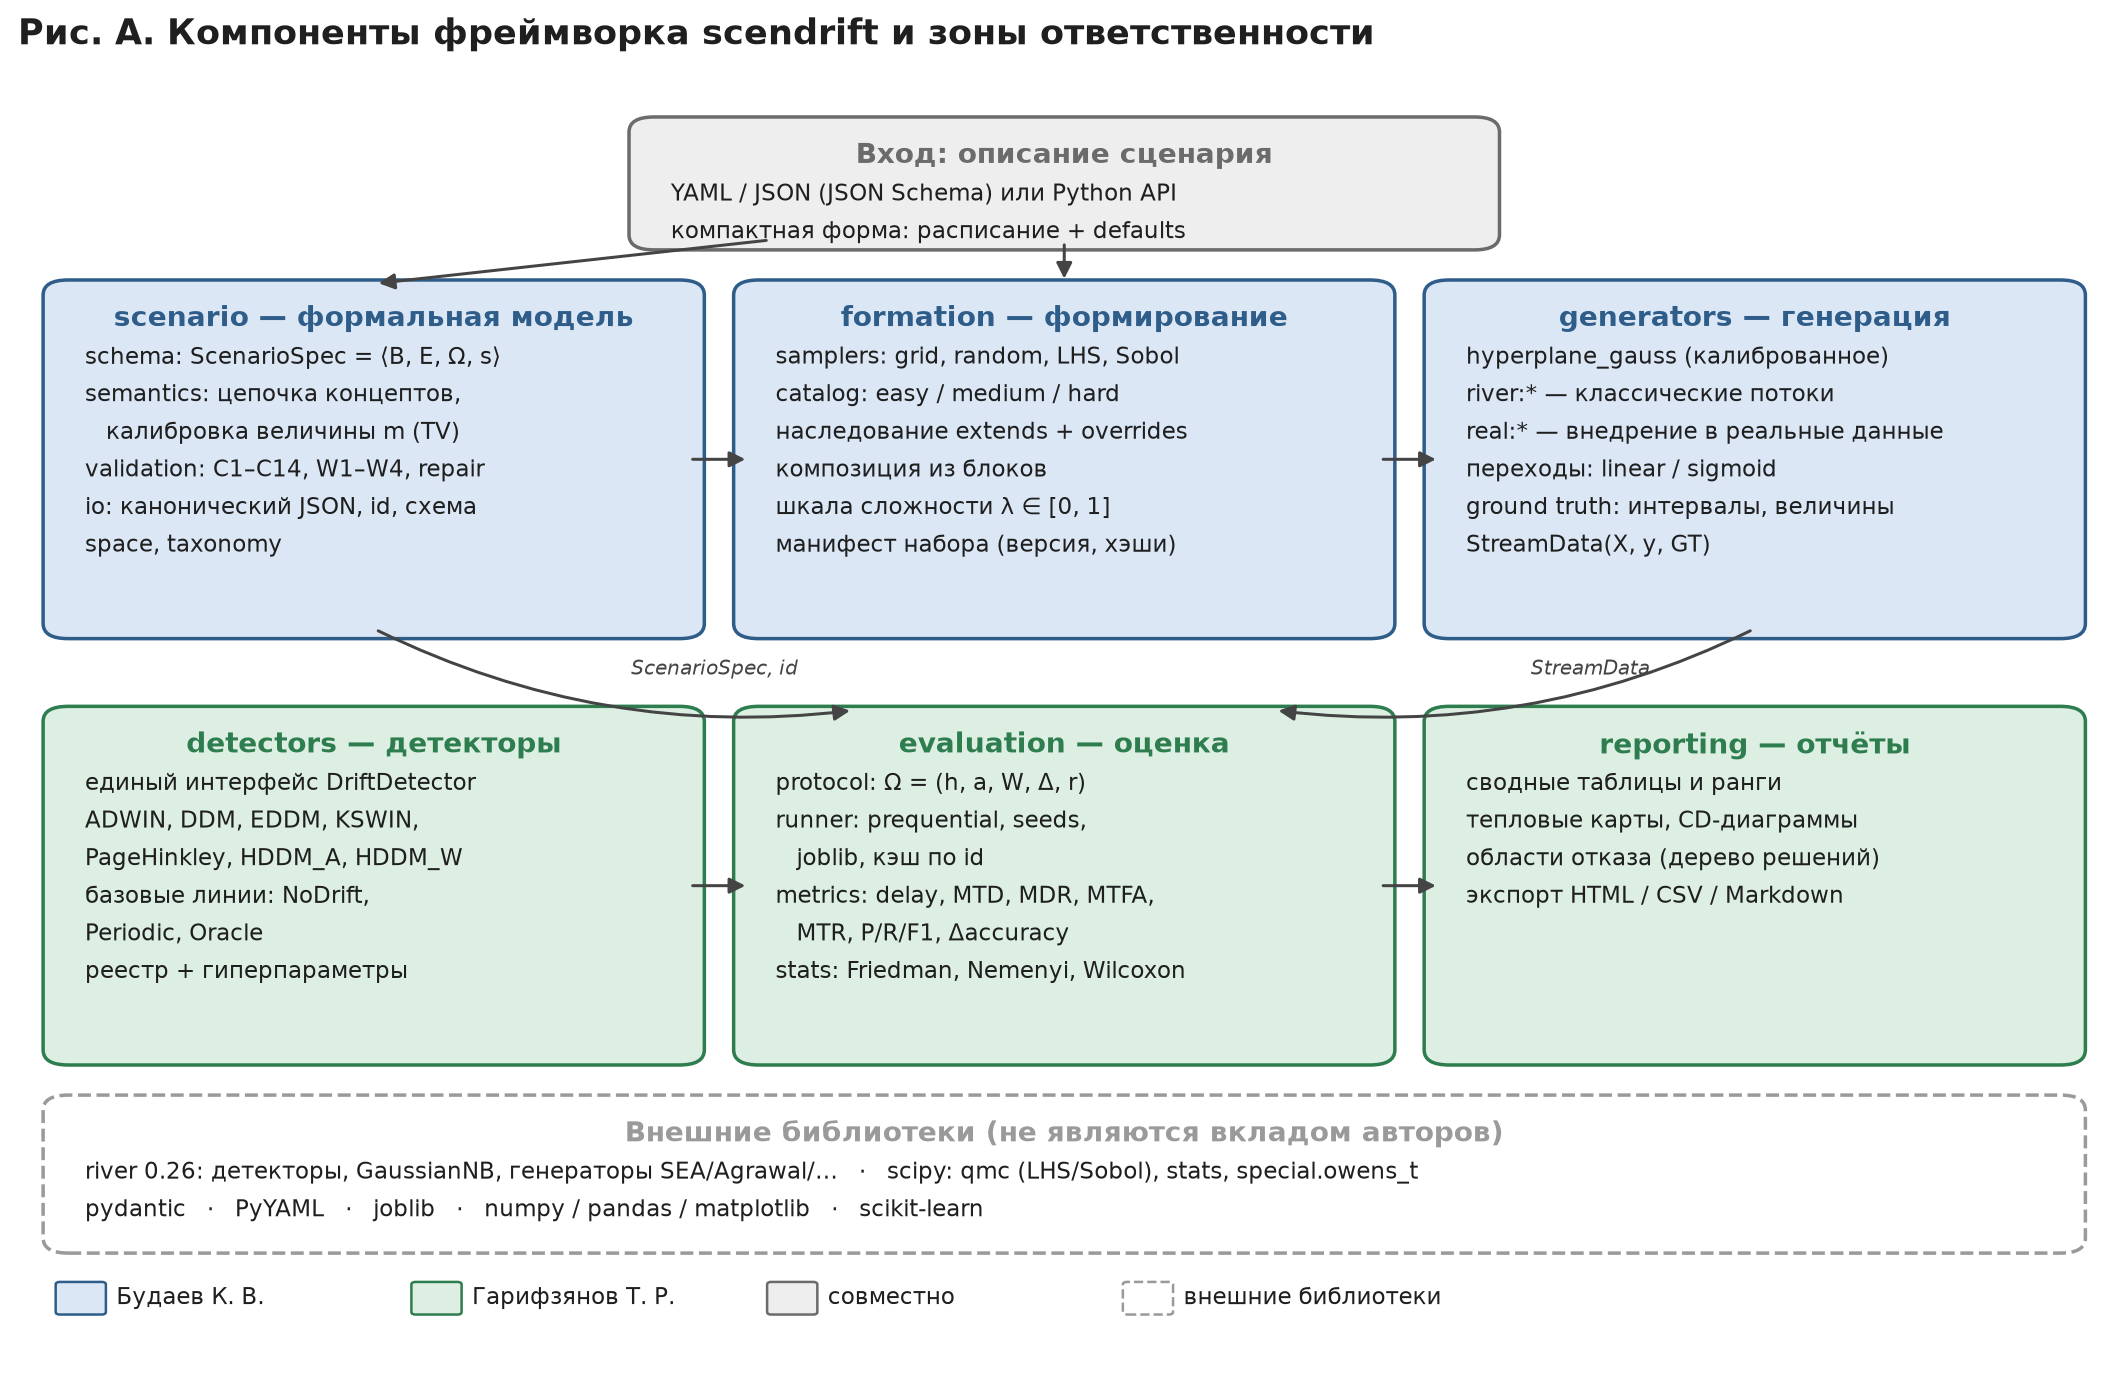

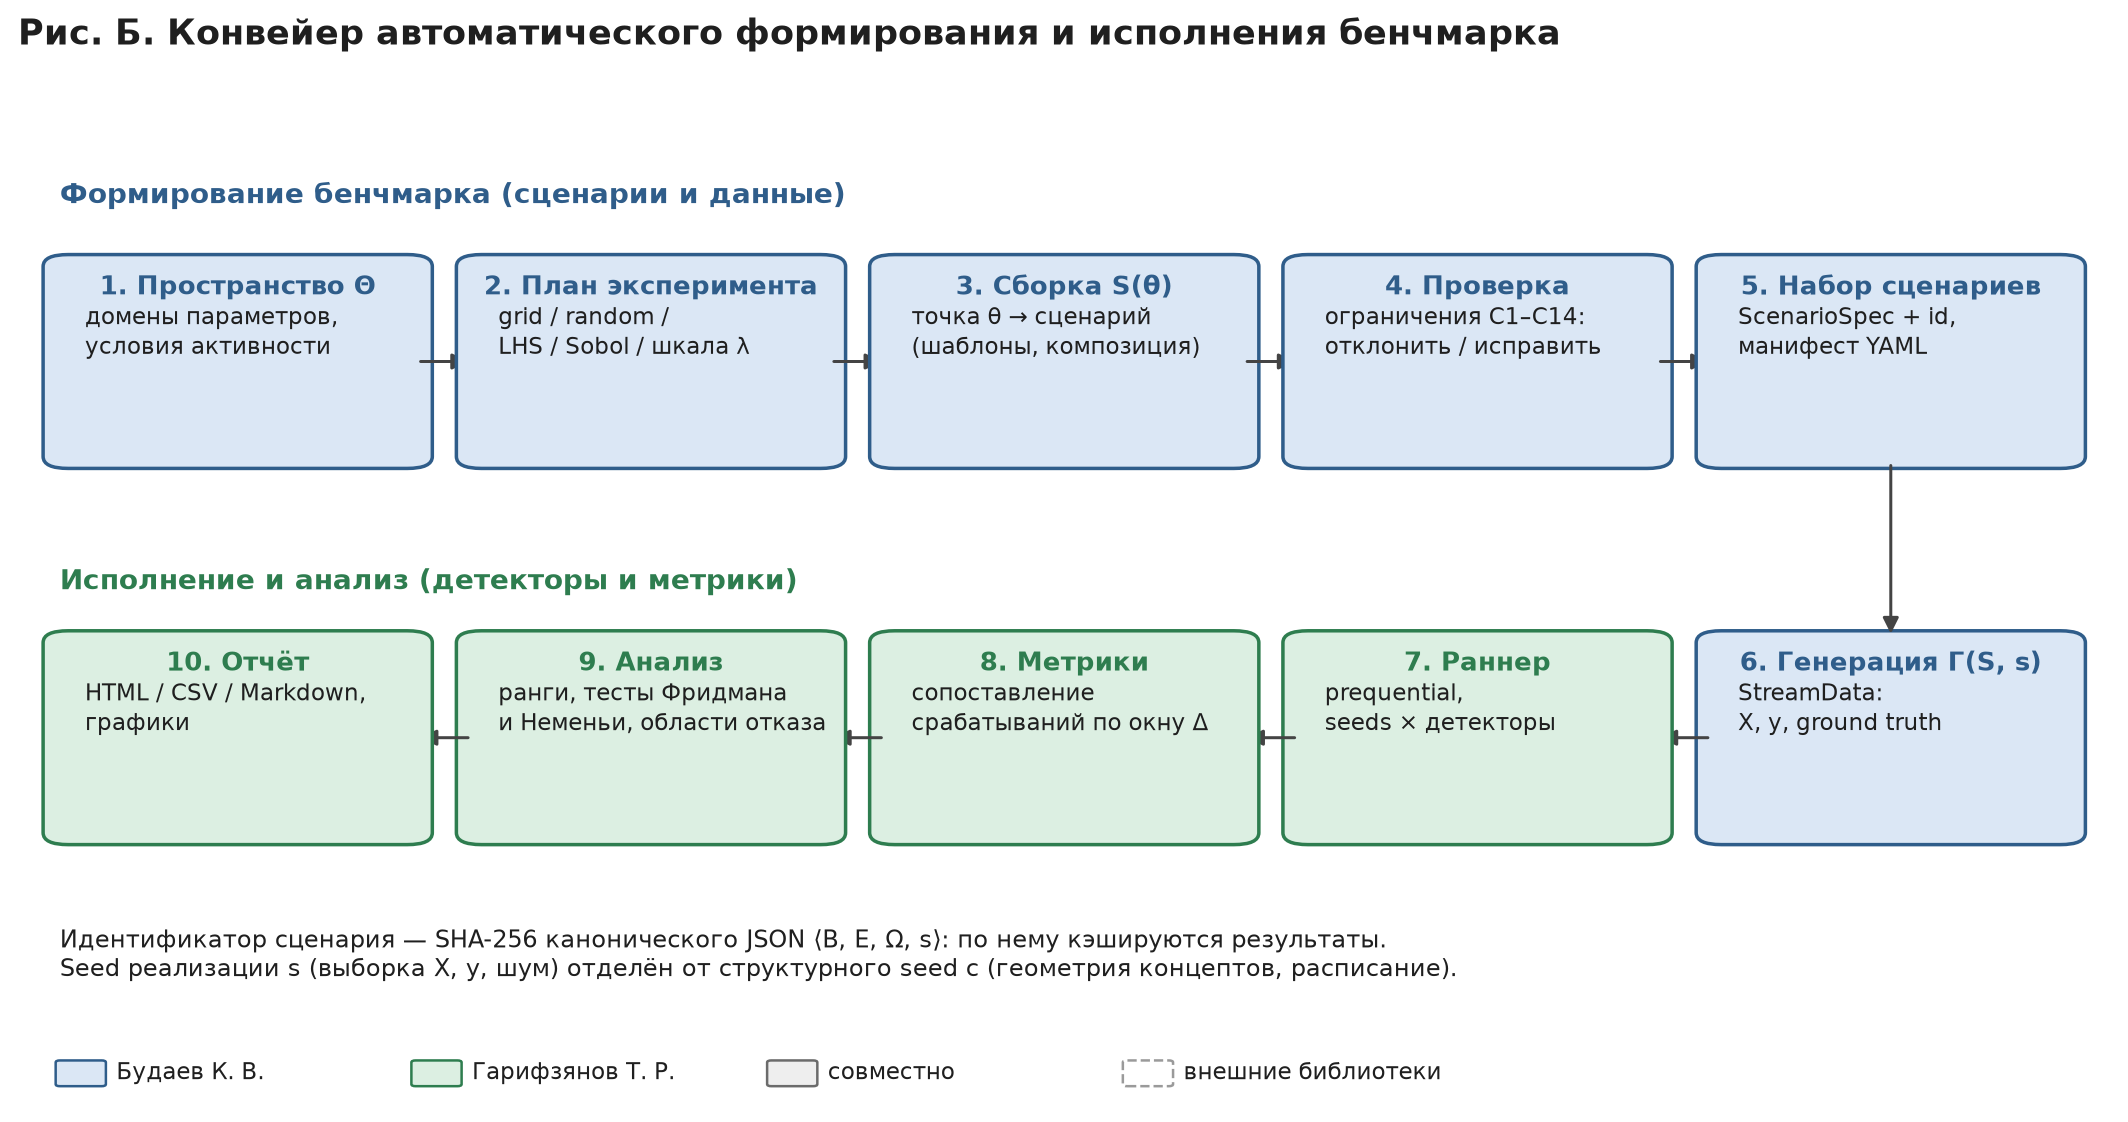

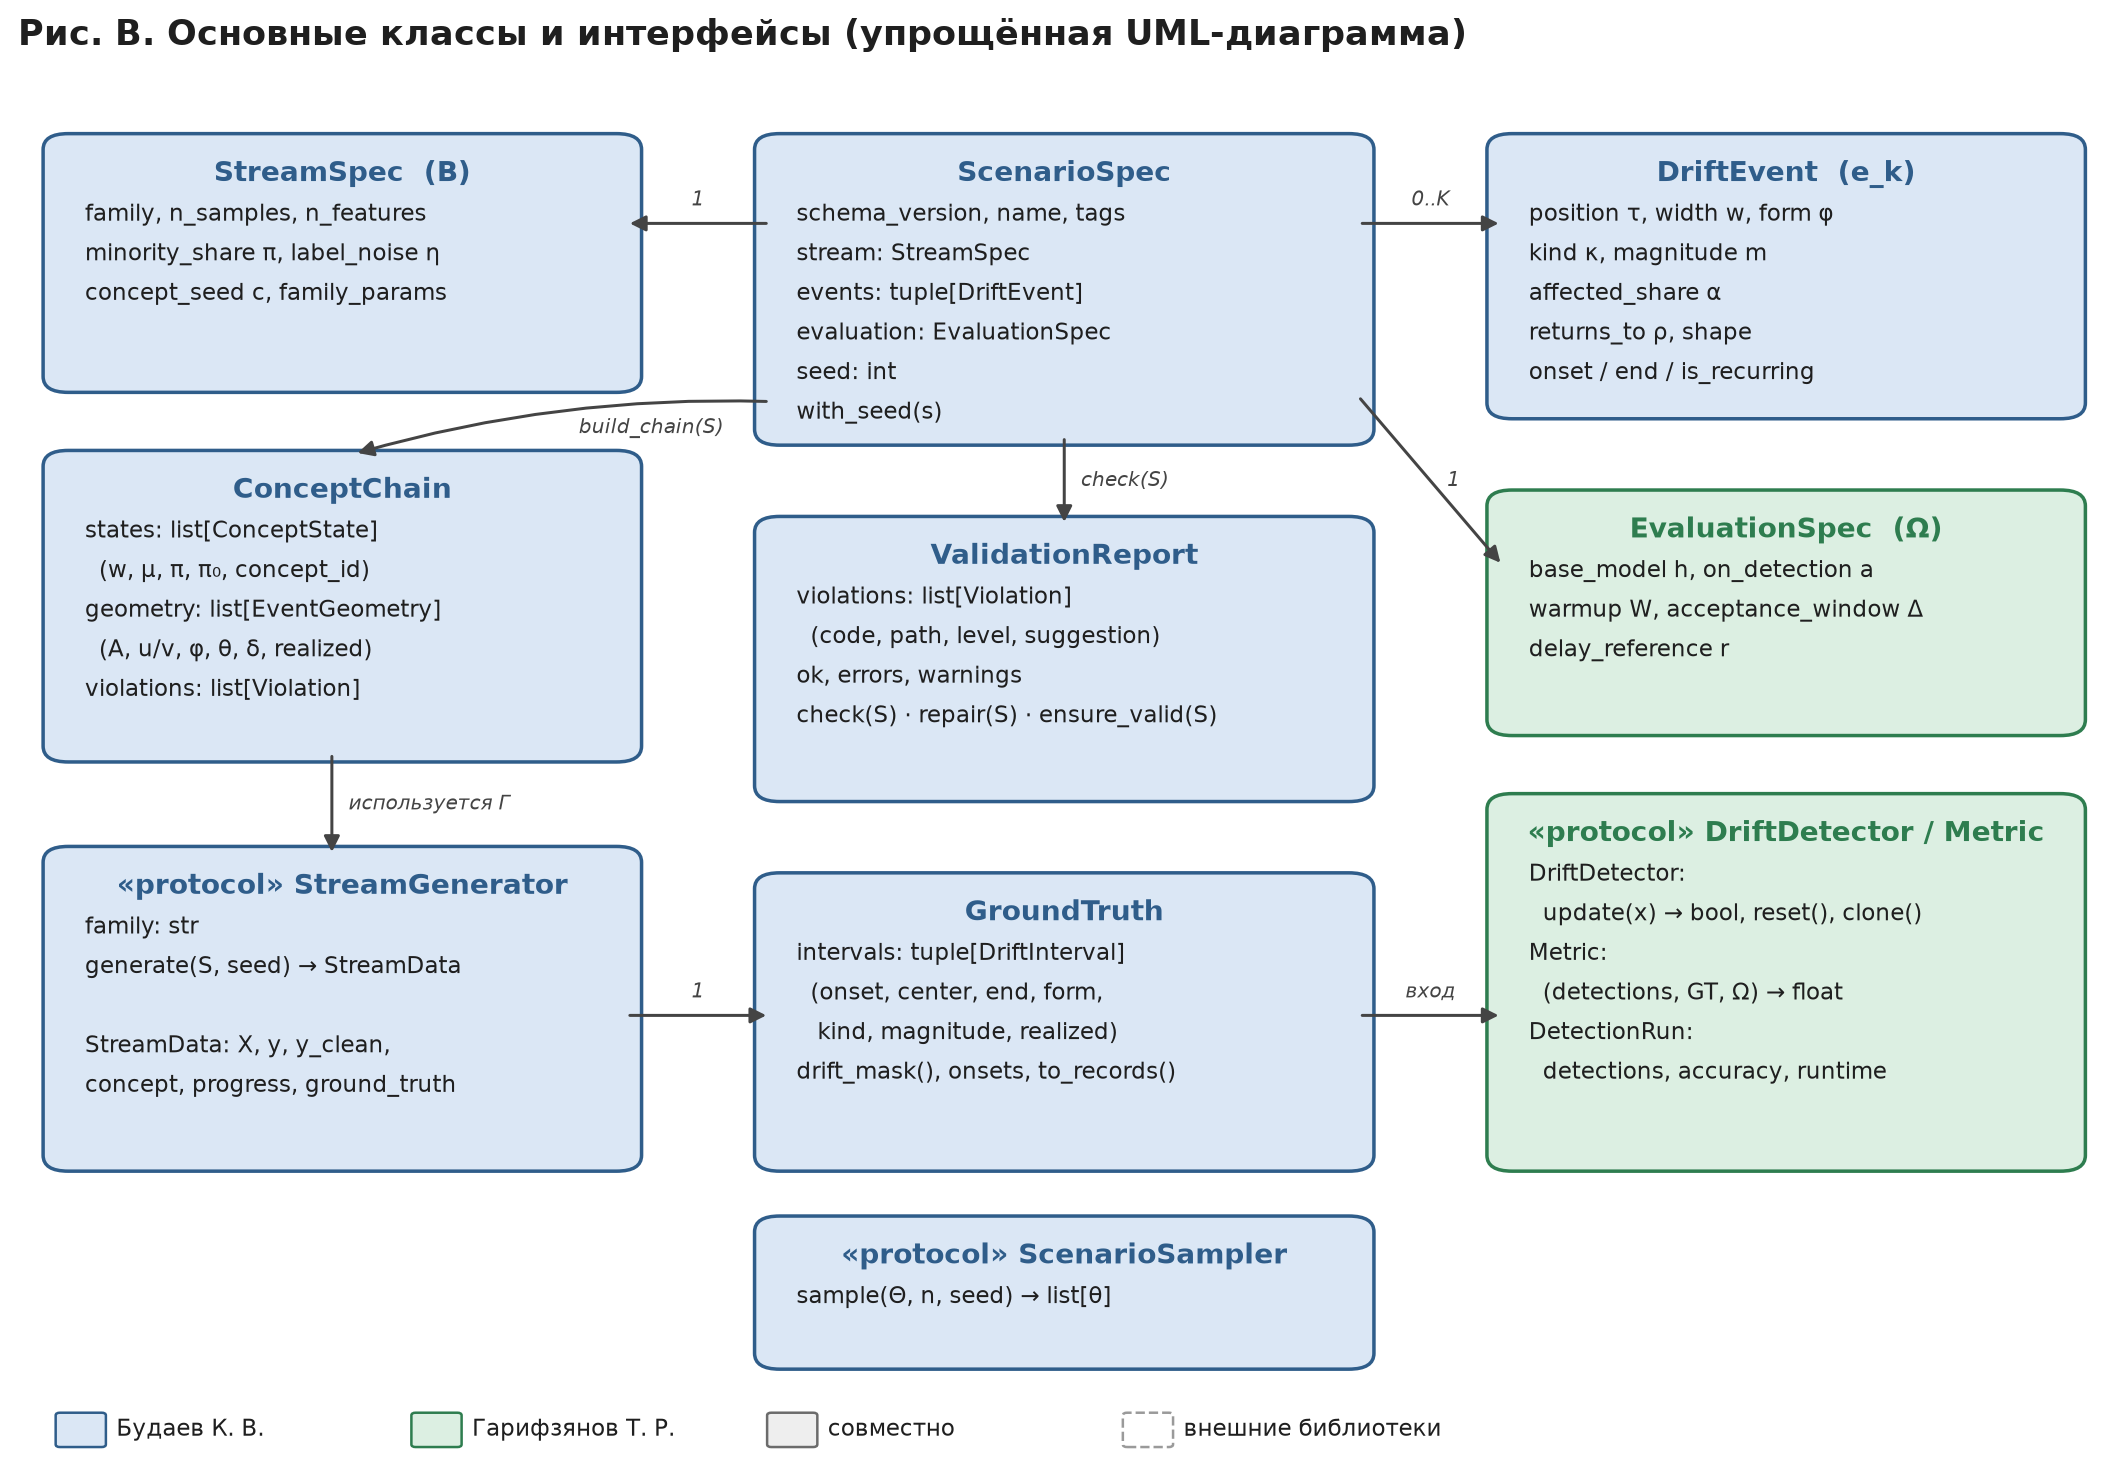

In [9]:
import importlib.util

from IPython.display import Image, display

spec_diagrams = importlib.util.spec_from_file_location("diagrams", "tools/diagrams.py")
diagrams = importlib.util.module_from_spec(spec_diagrams)
spec_diagrams.loader.exec_module(diagrams)
for path in diagrams.make_all("docs/figures"):
    display(Image(filename=str(path), width=980))

Принятые архитектурные решения:

1. **Сценарий — неизменяемый объект-значение** (pydantic, `frozen=True`). Любая модификация (наследование, переопределение, исправление) создаёт новый сценарий с новым идентификатором. Поэтому результаты не могут «перепутаться» со сценарием.
2. **Проверка отделена от схемы.** Pydantic проверяет домены полей и согласованность полей одного события (C1–C3). Ограничения, связывающие разные события и части сценария, и ограничения семейства (C4–C14) вынесены в валидатор. Так модуль формирования может построить недопустимого кандидата и исправить его, а не отбрасывать точку плана эксперимента.
3. **Семантика вынесена из генератора.** Цепочка концептов (`semantics.build_chain`) вычисляется без порождения данных. Генератор (этап 2) только реализует выборку из уже рассчитанных концептов, поэтому валидатор и генератор используют один и тот же расчёт и не расходятся.
4. **Расширение через реестры и интерфейсы.** Новое семейство генераторов регистрируется вместе со своими ограничениями. Новый детектор подключается адаптером, реализующим `DriftDetector`, без наследования.

### 3.3. Декларативное описание сценариев

Сценарий описывается в YAML или JSON в одной из двух форм:

* **каноническая** — явный список событий `events`. Именно она хранится, хэшируется и подаётся генератору;
* **компактная** — блок `drifts`: расписание (`uniform`, `random`, `explicit`), параметры по умолчанию и переопределения отдельных событий. При загрузке она разворачивается в каноническую форму.

Наследование шаблонов (`extends`) и каталог профилей «лёгкий / средний / тяжёлый» добавляются на этапе 3.

Ниже пять примеров, которые входят в репозиторий и проверяются тестами:
1. каноническая форма;
2. компактная форма с дисбалансом и шумом;
3. смешанный сценарий с возвратом к исходному концепту;
4. инкрементальный дрейф со случайным расписанием;
5. дрейф априорных вероятностей.

In [10]:
%%writefile configs/examples/01_sudden_real.yaml
# Пример 1. Один внезапный реальный дрейф: каноническая (явная) форма сценария.
# Нормаль гиперплоскости поворачивается так, что метка меняется на 25 % пространства признаков.
schema_version: "1.0"
name: sudden_real_single
description: Один внезапный реальный дрейф средней величины в середине потока
tags: [example, sudden, real]
stream:
  family: hyperplane_gauss
  n_samples: 20000
  n_features: 10
  minority_share: 0.5
  label_noise: 0.0
  concept_seed: 0
events:
  - {position: 10000, form: sudden, kind: real, magnitude: 0.25, affected_share: 1.0}
evaluation:
  base_model: gaussian_nb
  on_detection: reset
  warmup: 1000
  acceptance_window: 2000
seed: 1

Overwriting configs/examples/01_sudden_real.yaml


In [11]:
%%writefile configs/examples/02_gradual_imbalanced_noisy.yaml
# Пример 2. Компактная форма: расписание + параметры по умолчанию.
# Три постепенных реальных дрейфа на несбалансированном потоке с шумом меток.
schema_version: "1.0"
name: gradual_imbalanced_noisy
tags: [example, gradual, imbalanced, noisy]
stream:
  n_samples: 30000
  n_features: 20
  minority_share: 0.2      # π: доля положительного класса
  label_noise: 0.1         # η: эффективная величина m·(1 − 2η) = 0,12
  concept_seed: 11
drifts:
  schedule: {mode: uniform, count: 3}
  defaults: {form: gradual, kind: real, width: 2000, magnitude: 0.15, affected_share: 0.5}
seed: 2

Overwriting configs/examples/02_gradual_imbalanced_noisy.yaml


In [12]:
%%writefile configs/examples/03_recurring_mixed.yaml
# Пример 3. Смешанный сценарий с возвратом: real → virtual → возврат к исходному концепту.
# Третий дрейф (returns_to: 0) отменяет и поворот, и сдвиг: вид и величина вычисляются.
schema_version: "1.0"
name: recurring_mixed
tags: [example, recurring, mixed]
stream:
  n_samples: 20000
  n_features: 10
  minority_share: 0.3
  label_noise: 0.05
  concept_seed: 7
drifts:
  schedule: {mode: uniform, count: 3}
  defaults: {form: gradual, kind: real, width: 1000, magnitude: 0.2, affected_share: 0.5}
  overrides:
    - {index: 1, kind: virtual, magnitude: 0.4}
    - {index: 2, returns_to: 0}
seed: 42

Overwriting configs/examples/03_recurring_mixed.yaml


In [13]:
%%writefile configs/examples/04_incremental_random_schedule.yaml
# Пример 4. Инкрементальные дрейфы со случайным расписанием (позиции задаёт concept_seed).
# Затронута только часть признаков, поэтому m ограничена сверху (ограничение C10).
schema_version: "1.0"
name: incremental_random_partial
tags: [example, incremental, partial]
stream:
  n_samples: 40000
  n_features: 15
  minority_share: 0.5
  concept_seed: 5
drifts:
  schedule: {mode: random, count: 4, min_gap: 500}
  defaults: {form: incremental, kind: real, width: 3000, magnitude: 0.1, affected_share: 0.3}
  overrides:
    - {index: 3, shape: sigmoid}
seed: 3

Overwriting configs/examples/04_incremental_random_schedule.yaml


In [14]:
%%writefile configs/examples/05_prior_shift.yaml
# Пример 5. Дрейф априорных вероятностей (label shift): P(y) меняется, P(X|y) сохраняется.
schema_version: "1.0"
name: prior_shift_two_steps
tags: [example, prior]
stream:
  n_samples: 20000
  n_features: 5
  minority_share: 0.3
drifts:
  schedule: {mode: explicit, count: 2, positions: [7000, 14000]}
  defaults: {form: sudden, kind: prior, magnitude: 0.2}
seed: 4

Overwriting configs/examples/05_prior_shift.yaml


JSON Schema канонической формы генерируется из pydantic-моделей автоматически (п. 4.2), поэтому схема всегда соответствует коду. Её можно подключить в редакторе (VS Code, PyCharm) для автодополнения и проверки файлов в канонической форме (как пример 1). Компактную форму (`drifts`) проверяет загрузчик при развёртывании.

### 3.4. Интерфейсы модулей [К+Т]

Контракты между модулями заданы через `typing.Protocol` (структурная типизация). Детектор из любой библиотеки достаточно обернуть адаптером с методами `update`, `reset` и `clone`, а наследоваться от классов фреймворка не нужно.

Модуль также определяет общие структуры данных:
- `GroundTruth` и `DriftInterval` — истинная разметка дрейфа;
- `StreamData` — реализация потока;
- `DetectionRun` — результат одного прогона детектора.

In [15]:
%%writefile scendrift/interfaces.py
"""Общие типы данных и интерфейсы модулей фреймворка.

Ответственные: Будаев К. В. (данные, генераторы, формирование сценариев) и
Гарифзянов Т. Р. (детекторы, метрики, раннер).

Контракты между модулями заданы через :class:`typing.Protocol`
(структурная типизация). Поэтому, например, детектор из любой библиотеки
подключается адаптером, без наследования от классов фреймворка.

Поток данных между модулями::

    ScenarioSpec ──generate──▶ StreamData(X, y, GroundTruth)
         │                          │
         └──────── Runner ◀─────────┘ ── DriftDetector, Metric ──▶ DetectionRun
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from typing import TYPE_CHECKING, Any, Protocol, runtime_checkable

import numpy as np

if TYPE_CHECKING:
    from scendrift.evaluation.protocol import EvaluationSpec
    from scendrift.scenario.schema import ScenarioSpec
    from scendrift.scenario.space import ParameterSpace

__all__ = [
    "DriftInterval",
    "GroundTruth",
    "StreamData",
    "StreamGenerator",
    "ScenarioSampler",
    "DriftDetector",
    "Metric",
    "DetectionRun",
]


# ---------------------------------------------------------------------------
# Данные (Будаев К. В.)
# ---------------------------------------------------------------------------


@dataclass(frozen=True)
class DriftInterval:
    """Истинное событие дрейфа в ground truth.

    Attributes:
        index: номер события (с нуля).
        onset: начало перехода (индекс первого объекта, затронутого дрейфом).
        center: центр перехода τ.
        end: конец перехода (исключительно); при внезапном дрейфе end = onset.
        form: форма перехода.
        kind: вид события или ``"recurring"``.
        magnitude: заданная величина (None для повторяющегося события).
        realized: фактическая величина по компонентам real/virtual/prior.
        returns_to: номер концепта возврата.
    """

    index: int
    onset: int
    center: int
    end: int
    form: str
    kind: str
    magnitude: float | None
    realized: Mapping[str, float] = field(default_factory=dict)
    returns_to: int | None = None

    def acceptance_window(self, delta: int) -> tuple[int, int]:
        """Полуинтервал [onset, end + Δ), на котором срабатывание засчитывается."""
        return self.onset, self.end + delta


@dataclass(frozen=True)
class GroundTruth:
    """Истинная разметка дрейфа потока: упорядоченный набор интервалов."""

    intervals: tuple[DriftInterval, ...]
    n_samples: int

    def __len__(self) -> int:
        return len(self.intervals)

    @property
    def onsets(self) -> np.ndarray:
        """Начала переходов."""
        return np.array([iv.onset for iv in self.intervals], dtype=np.int64)

    def drift_mask(self) -> np.ndarray:
        """Булев вектор длины n: объект находится внутри интервала перехода.

        При внезапном дрейфе отмечается ровно один объект (onset).
        """
        mask = np.zeros(self.n_samples, dtype=bool)
        for iv in self.intervals:
            mask[iv.onset : max(iv.end, iv.onset + 1)] = True
        return mask

    def to_records(self) -> list[dict[str, Any]]:
        """Список словарей (для pandas.DataFrame и экспорта в CSV)."""
        rows = []
        for iv in self.intervals:
            row = {
                "index": iv.index,
                "onset": iv.onset,
                "center": iv.center,
                "end": iv.end,
                "form": iv.form,
                "kind": iv.kind,
                "magnitude": iv.magnitude,
                "returns_to": iv.returns_to,
            }
            row.update({f"realized_{k}": v for k, v in iv.realized.items()})
            rows.append(row)
        return rows


@dataclass(frozen=True)
class StreamData:
    """Реализация потока по сценарию.

    Attributes:
        X: матрица признаков n × d.
        y: метки (с шумом), n.
        ground_truth: истинная разметка дрейфа.
        concept: номер состояния цепочки концептов, породившего объект
            (латентная переменная), n. При инкрементальном переходе —
            номер конечного состояния перехода.
        y_clean: метки без шума (для валидации генератора), n.
        scenario_id: идентификатор сценария.
        seed: seed реализации.
        progress: значение функции перехода p(t) для текущего события, n.
        feature_names: имена признаков.
    """

    X: np.ndarray
    y: np.ndarray
    ground_truth: GroundTruth
    concept: np.ndarray
    y_clean: np.ndarray
    scenario_id: str
    seed: int
    progress: np.ndarray | None = None
    feature_names: tuple[str, ...] = ()

    @property
    def n_samples(self) -> int:
        return int(self.X.shape[0])

    @property
    def n_features(self) -> int:
        return int(self.X.shape[1])


@runtime_checkable
class StreamGenerator(Protocol):
    """Генератор потока семейства ``family``: детерминирован при фиксированных (S, seed)."""

    family: str

    def generate(self, spec: ScenarioSpec, seed: int | None = None) -> StreamData:
        """Порождает поток. Если seed не задан, берётся ``spec.seed``."""
        ...


@runtime_checkable
class ScenarioSampler(Protocol):
    """План эксперимента над пространством параметров (этап 3)."""

    def sample(self, space: ParameterSpace, n: int, seed: int) -> list[dict[str, Any]]:
        """Возвращает n точек пространства параметров."""
        ...


# ---------------------------------------------------------------------------
# Оценка (Гарифзянов Т. Р.)
# ---------------------------------------------------------------------------


@runtime_checkable
class DriftDetector(Protocol):
    """Детектор дрейфа: получает поток значений (обычно индикатор ошибки 0/1)."""

    name: str

    def update(self, value: float) -> bool:
        """Обрабатывает очередное значение и возвращает True при срабатывании."""
        ...

    def reset(self) -> None:
        """Возвращает детектор в исходное состояние."""
        ...

    def clone(self) -> DriftDetector:
        """Новый экземпляр с теми же гиперпараметрами в исходном состоянии."""
        ...


@dataclass(frozen=True)
class DetectionRun:
    """Результат одного прогона: сценарий × seed × детектор.

    Attributes:
        scenario_id: идентификатор сценария.
        seed: seed реализации.
        detector: имя детектора (с гиперпараметрами).
        detections: моменты срабатываний (индексы объектов).
        n_samples: длина потока.
        accuracy: prequential accuracy базовой модели.
        runtime_s: время прогона, с.
        extra: дополнительные измерения.
    """

    scenario_id: str
    seed: int
    detector: str
    detections: tuple[int, ...]
    n_samples: int
    accuracy: float
    runtime_s: float
    extra: Mapping[str, Any] = field(default_factory=dict)


@runtime_checkable
class Metric(Protocol):
    """Метрика качества обнаружения по срабатываниям и ground truth."""

    name: str

    def __call__(
        self,
        detections: Sequence[int],
        ground_truth: GroundTruth,
        protocol: EvaluationSpec,
    ) -> float:
        """Значение метрики (NaN, если метрика не определена)."""
        ...

Overwriting scendrift/interfaces.py


## 4. Реализация

Каждый модуль приводится полностью в ячейке `%%writefile`, которая создаёт файл пакета. Перед ячейкой объясняется назначение модуля, после неё идёт демонстрация. Оформление кода соответствует PEP 8 (проверяется `ruff`), у функций есть аннотации типов и docstrings.

### 4.1. Формальная модель сценария: схема, семантика, проверка [К]

#### 4.1.1. Перечисления

Формы перехода, виды дрейфа и профили функции перехода. Повторяющийся дрейф — не форма, а отдельное поле события (см. п. 2.2).

In [16]:
%%writefile scendrift/scenario/enums.py
"""Перечисления формальной модели сценария дрейфа.

Ответственный: Будаев К. В.

Повторяющийся дрейф (recurring) здесь сознательно не является формой
перехода. Возврат к ранее встречавшемуся концепту может быть как внезапным,
так и постепенным, поэтому он задаётся отдельно, полем ``returns_to``
события дрейфа (см. :class:`scendrift.scenario.schema.DriftEvent`).
"""

from __future__ import annotations

from enum import StrEnum

__all__ = ["DriftForm", "DriftKind", "TransitionShape"]


class DriftForm(StrEnum):
    """Форма дрейфа во времени: как новый концепт замещает старый.

    * ``SUDDEN`` — внезапный дрейф (sudden/abrupt): мгновенная смена концепта, ширина 0.
    * ``GRADUAL`` — постепенный дрейф (gradual): на интервале перехода объекты
      порождаются то старым, то новым концептом, причём вероятность нового растёт.
    * ``INCREMENTAL`` — инкрементальный дрейф (incremental): параметры концепта
      непрерывно меняются, проходя через промежуточные концепты.
    """

    SUDDEN = "sudden"
    GRADUAL = "gradual"
    INCREMENTAL = "incremental"


class DriftKind(StrEnum):
    """Вид дрейфа: какая компонента совместного распределения P(X, y) меняется.

    * ``REAL`` — реальный дрейф (real drift): меняется P(y|X), а P(X) и P(y)
      сохраняются.
    * ``VIRTUAL`` — виртуальный дрейф (virtual drift, covariate shift): меняется
      P(X), а P(y|X) и P(y) сохраняются.
    * ``PRIOR`` — дрейф априорных вероятностей (prior/label shift): меняется P(y),
      а P(X|y) сохраняется.
    """

    REAL = "real"
    VIRTUAL = "virtual"
    PRIOR = "prior"


class TransitionShape(StrEnum):
    """Профиль функции перехода p(t) на интервале [onset, end).

    * ``LINEAR`` — линейный рост от 0 до 1.
    * ``SIGMOID`` — сигмоида как в MOA (ConceptDriftStream), отнормированная
      так, что p(onset) = 0 и p(end) = 1 ровно на границах интервала.
    """

    LINEAR = "linear"
    SIGMOID = "sigmoid"

Overwriting scendrift/scenario/enums.py


#### 4.1.2. Протокол оценки Ω [Т]

Протокол оценки входит в сценарий и в его идентификатор: от выбора $W$ и $\Delta$ зависят результаты. На данные протокол не влияет.

In [17]:
%%writefile scendrift/evaluation/__init__.py
"""Оценка детекторов: протокол, раннер, метрики, статистика.

Ответственный: Гарифзянов Т. Р.
"""

from scendrift.evaluation.protocol import AdaptationPolicy, DelayReference, EvaluationSpec

__all__ = ["AdaptationPolicy", "DelayReference", "EvaluationSpec"]

Overwriting scendrift/evaluation/__init__.py


In [18]:
%%writefile scendrift/evaluation/protocol.py
"""Протокол оценки Ω — составная часть формальной модели сценария.

Ответственный: Гарифзянов Т. Р.

Сценарий S = ⟨B, E, Ω, s⟩ включает протокол оценки Ω = (h, a, W, Δ, r):

* h — базовая (онлайн) модель, ошибки которой отслеживает детектор;
* a — политика адаптации при срабатывании детектора;
* W — длина разогрева (warm-up), в течение которого дрейф не допускается;
* Δ — окно допуска: срабатывание засчитывается как обнаружение события,
  если оно произошло на полуинтервале [onset, end + Δ);
* r — от какой точки отсчитывается задержка обнаружения: начало или центр перехода.

Правила сопоставления срабатываний с событиями и определения метрик
(TP/FP/FN, MTD, MDR, MTFA, MTR) формализованы в разделе 2.6 ноутбука,
реализация вынесена в модуль ``scendrift.evaluation.metrics`` (этап 4).
"""

from __future__ import annotations

from enum import StrEnum

from pydantic import BaseModel, ConfigDict, Field

__all__ = ["AdaptationPolicy", "DelayReference", "EvaluationSpec"]


class AdaptationPolicy(StrEnum):
    """Реакция на срабатывание детектора.

    * ``RESET`` — базовая модель сбрасывается и обучается заново
      (стандартная схема detect-and-reset).
    * ``NONE`` — модель продолжает обучаться, срабатывания только фиксируются.
    """

    RESET = "reset"
    NONE = "none"


class DelayReference(StrEnum):
    """Точка отсчёта задержки обнаружения."""

    ONSET = "onset"
    CENTER = "center"


class EvaluationSpec(BaseModel):
    """Протокол оценки Ω (часть сценария, учитывается в его идентификаторе)."""

    model_config = ConfigDict(extra="forbid", frozen=True)

    base_model: str = Field(
        "gaussian_nb",
        description="h — идентификатор базовой онлайн-модели в реестре моделей.",
    )
    on_detection: AdaptationPolicy = Field(
        AdaptationPolicy.RESET, description="a — политика адаптации при срабатывании."
    )
    warmup: int = Field(
        1_000, ge=0, description="W — длина разогрева: дрейф не начинается раньше W."
    )
    acceptance_window: int = Field(
        2_000,
        ge=1,
        description="Δ — окно допуска: обнаружение засчитывается на [onset, end + Δ).",
    )
    delay_reference: DelayReference = Field(
        DelayReference.ONSET, description="r — точка отсчёта задержки."
    )

Overwriting scendrift/evaluation/protocol.py


#### 4.1.3. Схема сценария

Pydantic-модели `StreamSpec` (B), `DriftEvent` ($e_k$) и `ScenarioSpec` (S), а также компактная форма `DriftPlan` с функцией развёртывания `expand_plan`. Модели неизменяемы (`frozen=True`) и запрещают неизвестные поля (`extra="forbid"`): опечатка в YAML-файле даёт ошибку, а не молча игнорируется.

In [19]:
%%writefile scendrift/scenario/schema.py
"""Декларативная схема сценария дрейфа (pydantic).

Ответственный: Будаев К. В. (протокол оценки Ω — Гарифзянов Т. Р.,
см. :mod:`scendrift.evaluation.protocol`).

Формальная модель: сценарий S = ⟨B, E, Ω, s⟩, где

* B = (f, n, d, π, η, c) — базовая конфигурация потока
  (:class:`StreamSpec`): семейство генератора, длина, размерность, доля
  положительного (миноритарного) класса, шум меток, структурный seed c;
* E = (e₁, …, e_K) — упорядоченные события дрейфа (:class:`DriftEvent`),
  e_k = (τ_k, ℓ_k, φ_k, κ_k, m_k, α_k, ρ_k);
* Ω — протокол оценки (:class:`~scendrift.evaluation.protocol.EvaluationSpec`);
* s — seed реализации.

Здесь проверяются только *локальные* ограничения: домены полей и
согласованность полей одного события. Ограничения между полями разных
частей сценария и ограничения конкретного семейства генераторов проверяет
:mod:`scendrift.scenario.validation`. Благодаря такому разделению модули
формирования сценариев (этап 3) могут сначала построить недопустимого
кандидата, а затем отклонить или исправить его.

Кроме канонической формы (явный список событий) поддерживается компактная
форма :class:`DriftPlan`: расписание, параметры по умолчанию и
переопределения. Функция :func:`expand_plan` разворачивает её в явный список.
"""

from __future__ import annotations

import math
from collections.abc import Mapping
from typing import Any, Literal

import numpy as np
from pydantic import BaseModel, ConfigDict, Field, field_validator, model_validator

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.enums import DriftForm, DriftKind, TransitionShape

__all__ = [
    "SCHEMA_VERSION",
    "MIN_CLASS_SHARE",
    "StreamSpec",
    "DriftEvent",
    "ScenarioSpec",
    "SchedulePlan",
    "EventTemplate",
    "EventOverride",
    "DriftPlan",
    "expand_plan",
    "layout_uniform",
]

#: Версия схемы сценария. Меняется при несовместимом изменении полей.
SCHEMA_VERSION = "1.0"

#: Минимально допустимая доля любого класса (для π и для prior-дрейфа).
MIN_CLASS_SHARE = 0.01

#: Метка подпотока генератора случайных чисел для расписания (см. expand_plan).
_SCHEDULE_STREAM_TAG = 1_000_003


class _Frozen(BaseModel):
    """Базовый класс: неизменяемые модели без лишних полей."""

    model_config = ConfigDict(extra="forbid", frozen=True)


def _plain(value: Any, path: str = "") -> Any:
    """Приводит произвольные параметры к JSON-совместимым значениям Python.

    numpy-скаляры и массивы превращаются в числа и списки, кортежи — в
    списки, −0,0 — в 0,0. Нечисловые (NaN, ±inf) значения и нестроковые ключи
    отклоняются: иначе разные сценарии получили бы одинаковый идентификатор.
    """
    where = path or "параметрах"
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, bool) or value is None or isinstance(value, str | int):
        return value
    if isinstance(value, float):
        if not math.isfinite(value):
            raise ValueError(f"недопустимое нечисловое значение {value!r} в {where}")
        return value + 0.0
    if isinstance(value, Mapping):
        out = {}
        for key, item in value.items():
            if not isinstance(key, str):
                raise ValueError(f"ключ {key!r} в {where} должен быть строкой")
            out[key] = _plain(item, f"{path}.{key}" if path else key)
        return out
    if isinstance(value, list | tuple):
        return [_plain(item, f"{path}[{i}]") for i, item in enumerate(value)]
    raise ValueError(f"неподдерживаемый тип {type(value).__name__} в {where}")


class StreamSpec(_Frozen):
    """Базовая конфигурация потока B = (f, n, d, π, η, c)."""

    family: str = Field(
        "hyperplane_gauss", min_length=1, description="f — семейство генератора потока."
    )
    n_samples: int = Field(20_000, ge=1_000, le=10_000_000, description="n — длина потока.")
    n_features: int = Field(10, ge=2, le=500, description="d — число признаков.")
    minority_share: float = Field(
        0.5,
        ge=MIN_CLASS_SHARE,
        le=0.5,
        description="π — исходная доля положительного (миноритарного) класса P(y=1).",
    )
    label_noise: float = Field(
        0.0, ge=0.0, lt=0.5, description="η — вероятность инверсии метки (шум меток)."
    )
    concept_seed: int = Field(
        0,
        ge=0,
        description=(
            "c — структурный seed: задаёт геометрию концептов (затронутые признаки, "
            "направления поворота и сдвига) и случайное расписание. От seed "
            "реализации не зависит, поэтому повторы сценария имеют одинаковые концепты."
        ),
    )
    family_params: dict[str, Any] = Field(
        default_factory=dict,
        description="Параметры, специфичные для семейства (допустимые ключи задаёт семейство).",
    )

    @field_validator("minority_share", "label_noise")
    @classmethod
    def _floats(cls, value: float) -> float:
        """Заменяет −0,0 на 0,0, чтобы равные значения давали равный хэш."""
        return value + 0.0

    @field_validator("family_params", mode="before")
    @classmethod
    def _params(cls, value: Any) -> Any:
        return _plain(value, "family_params") if isinstance(value, Mapping) else value


class DriftEvent(_Frozen):
    """Событие дрейфа e = (τ, ℓ, φ, κ, m, α, ρ).

    Интервал перехода — полуинтервал [onset, end), где
    onset = τ − ⌊ℓ/2⌋ и end = onset + ℓ. При внезапном дрейфе onset = end = τ,
    и объект с индексом τ — первый объект нового концепта.

    Величина m обязательна для калиброванных семейств и не задаётся для
    некалиброванных (там она оценивается по данным); это проверяет валидатор
    (ограничение C2).

    Если задано ``returns_to`` (ρ), событие считается *повторяющимся*: поток
    возвращается к концепту с номером ρ. Концепт 0 — исходный, концепт k
    возникает после k-го события. Вид и величина такого события не задаются,
    а вычисляются по разности концептов.
    """

    position: int = Field(ge=0, description="τ — центр интервала перехода (индекс объекта).")
    width: int = Field(0, ge=0, description="ℓ — ширина перехода (в объектах).")
    form: DriftForm = Field(DriftForm.SUDDEN, description="φ — форма перехода.")
    kind: DriftKind | None = Field(None, description="κ — вид дрейфа (None для повторяющегося).")
    magnitude: float | None = Field(
        None, gt=0.0, le=1.0, description="m — величина дрейфа на единой шкале (0, 1]."
    )
    affected_share: float = Field(
        1.0, gt=0.0, le=1.0, description="α — доля признаков, затронутых дрейфом."
    )
    returns_to: int | None = Field(
        None, ge=0, description="ρ — номер концепта, к которому возвращается поток."
    )
    shape: TransitionShape = Field(
        TransitionShape.LINEAR, description="Профиль функции перехода p(t)."
    )

    @model_validator(mode="before")
    @classmethod
    def _default_kind(cls, data: Any) -> Any:
        """Подставляет вид ``real`` для обычного (неповторяющегося) события."""
        if (
            isinstance(data, Mapping)
            and data.get("returns_to") is None
            and data.get("kind") is None
        ):
            data = {**dict(data), "kind": DriftKind.REAL}
        return data

    @field_validator("magnitude", "affected_share")
    @classmethod
    def _floats(cls, value: float | None) -> float | None:
        """Заменяет −0,0 на 0,0, чтобы равные значения давали равный хэш."""
        return None if value is None else value + 0.0

    @model_validator(mode="after")
    def _check_local(self) -> DriftEvent:
        """Локальные ограничения события (C1–C3 каталога ограничений)."""
        if self.form is DriftForm.SUDDEN and self.width != 0:
            raise ValueError("C1: у внезапного дрейфа ширина перехода должна быть 0")
        if self.form is not DriftForm.SUDDEN and self.width < 2:
            raise ValueError("C1: у постепенного/инкрементального дрейфа ширина ≥ 2")
        if self.position - self.width // 2 < 0:
            raise ValueError("C1: интервал перехода начинается до начала потока")
        if self.returns_to is None:
            if self.kind is None:
                raise ValueError("C2: для обычного события обязателен вид kind")
        else:
            if self.kind is not None or self.magnitude is not None:
                raise ValueError(
                    "C3: у повторяющегося события (returns_to) вид и величина "
                    "не задаются — они вычисляются по разности концептов"
                )
        return self

    @property
    def onset(self) -> int:
        """Начало интервала перехода."""
        return self.position - self.width // 2

    @property
    def end(self) -> int:
        """Конец (исключительно) интервала перехода."""
        return self.onset + self.width

    @property
    def is_recurring(self) -> bool:
        """Признак повторяющегося события."""
        return self.returns_to is not None


class ScenarioSpec(_Frozen):
    """Сценарий дрейфа S = ⟨B, E, Ω, s⟩ в канонической (явной) форме.

    Поля ``name``, ``description``, ``tags`` и ``meta`` описательные: на
    порождаемые данные они не влияют и в идентификатор сценария не входят
    (см. :func:`scendrift.scenario.io.scenario_id`).
    """

    schema_version: Literal["1.0"] = SCHEMA_VERSION
    name: str = Field("unnamed", min_length=1, max_length=200)
    description: str = ""
    tags: tuple[str, ...] = ()
    stream: StreamSpec = Field(default_factory=StreamSpec)
    events: tuple[DriftEvent, ...] = ()
    evaluation: EvaluationSpec = Field(default_factory=EvaluationSpec)
    seed: int = Field(0, ge=0, description="s — seed реализации (выборка X, y, шум).")
    meta: dict[str, Any] = Field(
        default_factory=dict, description="Происхождение сценария (в хэш не входит)."
    )

    @property
    def n_events(self) -> int:
        """Число событий дрейфа K."""
        return len(self.events)

    def with_seed(self, seed: int) -> ScenarioSpec:
        """Копия сценария с другим seed реализации (для повторов), с проверкой."""
        return ScenarioSpec.model_validate({**self.model_dump(), "seed": int(seed)})

    @field_validator("meta", mode="before")
    @classmethod
    def _meta(cls, value: Any) -> Any:
        return _plain(value, "meta") if isinstance(value, Mapping) else value


# ---------------------------------------------------------------------------
# Компактная форма: расписание + значения по умолчанию + переопределения
# ---------------------------------------------------------------------------


class SchedulePlan(_Frozen):
    """Расписание дрейфов.

    * ``uniform`` — поток после разогрева делится на K равных блоков, и
      «след» события [onset, end + Δ) ставится в центр своего блока;
    * ``random`` — следы событий случайно размещаются без перекрытий
      (используется структурный seed c);
    * ``explicit`` — центры τ_k заданы явно.
    """

    mode: Literal["uniform", "random", "explicit"] = "uniform"
    count: int = Field(1, ge=0, le=100, description="K — число событий дрейфа.")
    positions: tuple[int, ...] | None = Field(
        None, description="Явные центры τ_k (только для mode=explicit)."
    )
    min_gap: int = Field(
        0, ge=0, description="Дополнительный зазор между следами событий (mode=random)."
    )

    @model_validator(mode="after")
    def _check(self) -> SchedulePlan:
        if self.mode == "explicit":
            if self.positions is None or len(self.positions) != self.count:
                raise ValueError("для mode=explicit нужно ровно count позиций")
        elif self.positions is not None:
            raise ValueError("positions допустимы только при mode=explicit")
        return self


class EventTemplate(_Frozen):
    """Параметры события по умолчанию: всё, кроме позиции."""

    width: int | None = Field(None, ge=0)
    form: DriftForm | None = None
    kind: DriftKind | None = None
    magnitude: float | None = Field(None, gt=0.0, le=1.0)
    affected_share: float | None = Field(None, gt=0.0, le=1.0)
    shape: TransitionShape | None = None


class EventOverride(EventTemplate):
    """Переопределение параметров события с номером ``index`` (с нуля)."""

    index: int = Field(ge=0)
    returns_to: int | None = Field(None, ge=0)
    position: int | None = Field(None, ge=0)


class DriftPlan(_Frozen):
    """Компактное описание событий дрейфа: расписание и параметры."""

    schedule: SchedulePlan = Field(default_factory=SchedulePlan)
    defaults: EventTemplate = Field(default_factory=EventTemplate)
    overrides: tuple[EventOverride, ...] = ()


def _event_params(plan: DriftPlan, index: int) -> dict[str, Any]:
    """Собирает параметры события: значения по умолчанию плюс переопределения."""
    params: dict[str, Any] = {k: v for k, v in plan.defaults.model_dump().items() if v is not None}
    for ov in plan.overrides:
        if ov.index == index:
            if ov.returns_to is not None:
                if ov.kind is not None or ov.magnitude is not None:
                    raise ValueError(
                        f"C3: событие {index} с returns_to не может задавать kind или magnitude"
                    )
                # Повторяющееся событие: вид и величина вычисляются, а не наследуются.
                params.pop("kind", None)
                params.pop("magnitude", None)
            params.update(
                {k: v for k, v in ov.model_dump(exclude={"index"}).items() if v is not None}
            )
    params.setdefault("form", DriftForm.SUDDEN)
    if params["form"] == DriftForm.SUDDEN:
        params["width"] = 0
    params.setdefault("width", 0)
    return params


def layout_uniform(widths: list[int], start: int, stop: int, delta: int) -> list[int]:
    """Центры событий при равномерном расписании.

    След события — полуинтервал [onset, end + Δ) длины ℓ_k + Δ. Свободное
    место F = (stop − start) − Σ(ℓ_k + Δ) делится поровну между K событиями,
    и каждый след ставится в центр своего блока длины (ℓ_k + Δ) + F/K. Если
    следы помещаются в поток (F ≥ 0), ограничения C4–C6 выполняются при
    любых ширинах переходов.

    Args:
        widths: ширины переходов ℓ_k.
        start: начало допустимой области (обычно W).
        stop: конец потока n.
        delta: окно допуска Δ.

    Returns:
        Список центров τ_k.
    """
    k_events = len(widths)
    if k_events == 0:
        return []
    footprints = [w + delta for w in widths]
    share = max(0.0, (stop - start) - sum(footprints)) / k_events
    centers, cursor = [], float(start)
    for w, fp in zip(widths, footprints, strict=True):
        onset = int(math.floor(cursor + share / 2.0))
        centers.append(onset + w // 2)
        cursor += fp + share
    return centers


def expand_plan(
    plan: DriftPlan,
    stream: StreamSpec,
    evaluation: EvaluationSpec,
) -> tuple[DriftEvent, ...]:
    """Разворачивает компактный план в явный список событий.

    Позиции рассчитываются так, чтобы при достаточной длине потока
    выполнялись ограничения C4–C6 (разогрев, хвост Δ после последнего
    перехода, непересечение следов [onset, end + Δ)). Если поток слишком
    короток, события всё равно строятся, а нарушения выявит валидатор
    (:func:`scendrift.scenario.validation.check`).

    Args:
        plan: компактное описание событий.
        stream: базовая конфигурация потока (нужны n и структурный seed).
        evaluation: протокол оценки (нужны W и Δ).

    Returns:
        Кортеж событий в порядке индексов. При расписаниях ``uniform`` и
        ``random`` он упорядочен по позиции; явные позиции не сортируются
        (на них ссылаются индексы ``returns_to``), а порядок проверяет C6.

    Raises:
        ValueError: при ссылке на несуществующее событие или противоречивом
            переопределении (returns_to вместе с kind или magnitude).
    """
    k_events = plan.schedule.count
    if k_events == 0:
        return ()
    for ov in plan.overrides:
        if ov.index >= k_events:
            raise ValueError(f"переопределение для несуществующего события {ov.index}")
    params = [_event_params(plan, i) for i in range(k_events)]
    widths = [int(p["width"]) for p in params]
    delta = evaluation.acceptance_window
    start, stop = evaluation.warmup, stream.n_samples
    footprints = [w + delta for w in widths]

    mode = plan.schedule.mode
    if mode == "explicit":
        assert plan.schedule.positions is not None
        centers = [int(t) for t in plan.schedule.positions]
    elif mode == "uniform":
        centers = layout_uniform(widths, start, stop, delta)
    else:  # random
        gap = plan.schedule.min_gap
        free = (stop - start) - sum(footprints) - gap * (k_events - 1)
        rng = np.random.default_rng([stream.concept_seed, _SCHEDULE_STREAM_TAG])
        cuts = np.sort(rng.uniform(0.0, max(free, 0), size=k_events))
        centers, cursor, prev = [], float(start), 0.0
        for i, (w, fp) in enumerate(zip(widths, footprints, strict=True)):
            cursor += cuts[i] - prev
            prev = cuts[i]
            centers.append(int(round(cursor)) + w // 2)
            cursor += fp + gap

    for i, p in enumerate(params):
        if "position" in p:  # явная позиция из переопределения имеет приоритет
            centers[i] = int(p.pop("position"))
    events = [DriftEvent(position=c, **p) for c, p in zip(centers, params, strict=True)]
    return tuple(events)

Overwriting scendrift/scenario/schema.py


#### 4.1.4. Отчёт о проверке и каталог ограничений

`CONSTRAINTS` — единый справочник ограничений: из него строятся таблицы в ноутбуке и в пояснительной записке.

In [20]:
%%writefile scendrift/scenario/report.py
"""Отчёт о проверке сценария: нарушения ограничений валидности.

Ответственный: Будаев К. В.

Каталог ограничений :data:`CONSTRAINTS` — это единый справочник. Из него
строятся таблица ограничений в ноутбуке и в пояснительной записке, поэтому
формулировки в коде и в тексте не расходятся.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Any, Literal

__all__ = ["CONSTRAINTS", "Violation", "ValidationReport", "ScenarioValidationError"]

#: Каталог ограничений валидности: код → (область проверки, формулировка).
#: События нумеруются с единицы: e_1, …, e_K; концепт c_k возникает после e_k.
CONSTRAINTS: dict[str, tuple[str, str]] = {
    "C1": ("событие", "φ = sudden ⇔ ℓ = 0; при φ ∈ {gradual, incremental} ℓ ≥ 2; onset ≥ 0"),
    "C2": (
        "семейство",
        "обычное событие: m ∈ (0, 1] задана для калиброванного семейства и не задана "
        "для некалиброванного (там m оценивается по данным)",
    ),
    "C3": ("событие", "для повторяющегося события (ρ задано) κ и m не задаются"),
    "C4": ("сценарий", "onset₁ ≥ W: дрейф не начинается во время разогрева"),
    "C5": ("сценарий", "end_K + Δ ≤ n: после последнего перехода есть окно допуска"),
    "C6": ("сценарий", "onset_{k+1} ≥ end_k + Δ: следы событий [onset, end + Δ) не пересекаются"),
    "C7": (
        "сценарий",
        "ρ_k ≤ k − 1 (концепт уже существует), и возврат меняет распределение: c_{ρ_k} ≠ c_{k−1}",
    ),
    "C8": (
        "семейство",
        "вид κ, форма φ, возврат и ключи family_params поддерживаются семейством f",
    ),
    "C9": ("семейство", "число затронутых признаков ⌊α·d⌉ ≥ 2 (для κ ∈ {real, virtual})"),
    "C10": ("семейство", "real: m ≤ m_max(q, π₀, π_k) — величина достижима поворотом внутри A"),
    "C11": ("семейство", "virtual: m ≤ 0,99 (TV < 1 при конечном сдвиге)"),
    "C12": ("семейство", "prior: новая доля P(y=1) лежит в [0,01; 0,99]"),
    "C13": ("семейство", "семейство f зарегистрировано в реестре"),
    "C14": ("сценарий", "W + Δ ≤ n: протокол оценки помещается в поток"),
    "W1": (
        "предупреждение",
        "real: m·(1 − 2η) < 0,02 — дрейф почти не наблюдаем на фоне шума меток",
    ),
    "W2": (
        "предупреждение",
        "virtual: P(y|X) не меняется, детекторы по ошибке могут его не видеть",
    ),
    "W3": (
        "предупреждение",
        "real при π_k ≠ π₀: вместе с P(y|X) меняется и P(X) (перевзвешивание классов)",
    ),
    "W4": (
        "предупреждение",
        "реальные данные: событие real или virtual меняет и P(y) более чем на 0,02",
    ),
}


@dataclass(frozen=True)
class Violation:
    """Нарушение ограничения валидности.

    Attributes:
        code: код ограничения из :data:`CONSTRAINTS`.
        message: пояснение на русском языке.
        path: путь к полю сценария, например ``events[2].magnitude``.
        level: ``error`` делает сценарий недопустимым, ``warning`` нет.
        suggestion: допустимое значение для исправления, если оно известно.
    """

    code: str
    message: str
    path: str = ""
    level: Literal["error", "warning"] = "error"
    suggestion: Any = None


@dataclass
class ValidationReport:
    """Результат проверки сценария."""

    violations: list[Violation] = field(default_factory=list)

    @property
    def errors(self) -> list[Violation]:
        """Нарушения уровня ``error``."""
        return [v for v in self.violations if v.level == "error"]

    @property
    def warnings(self) -> list[Violation]:
        """Нарушения уровня ``warning``."""
        return [v for v in self.violations if v.level == "warning"]

    @property
    def ok(self) -> bool:
        """Сценарий допустим, если нет ни одной ошибки."""
        return not self.errors

    def codes(self) -> set[str]:
        """Множество кодов нарушенных ограничений."""
        return {v.code for v in self.violations}

    def raise_if_invalid(self) -> None:
        """Выбрасывает :class:`ScenarioValidationError` при наличии ошибок."""
        if not self.ok:
            raise ScenarioValidationError(self)

    def __str__(self) -> str:
        if not self.violations:
            return "Сценарий допустим, нарушений нет."
        lines = [f"[{v.level}] {v.code} {v.path}: {v.message}" for v in self.violations]
        return "\n".join(lines)


class ScenarioValidationError(ValueError):
    """Сценарий нарушает ограничения валидности."""

    def __init__(self, report: ValidationReport) -> None:
        self.report = report
        super().__init__("Недопустимый сценарий:\n" + str(report))

Overwriting scendrift/scenario/report.py


In [21]:
%%writefile scendrift/scenario/__init__.py
"""Формальная модель сценария дрейфа: схема, семантика, ограничения, сериализация.

Ответственный: Будаев К. В.
"""

from scendrift.scenario.enums import DriftForm, DriftKind, TransitionShape
from scendrift.scenario.report import (
    CONSTRAINTS,
    ScenarioValidationError,
    ValidationReport,
    Violation,
)
from scendrift.scenario.schema import (
    SCHEMA_VERSION,
    DriftEvent,
    DriftPlan,
    EventOverride,
    EventTemplate,
    ScenarioSpec,
    SchedulePlan,
    StreamSpec,
    expand_plan,
)

__all__ = [
    "CONSTRAINTS",
    "SCHEMA_VERSION",
    "DriftEvent",
    "DriftForm",
    "DriftKind",
    "DriftPlan",
    "EventOverride",
    "EventTemplate",
    "ScenarioSpec",
    "ScenarioValidationError",
    "SchedulePlan",
    "StreamSpec",
    "TransitionShape",
    "ValidationReport",
    "Violation",
    "expand_plan",
]

Overwriting scendrift/scenario/__init__.py


#### 4.1.5. Семантика величины дрейфа и цепочка концептов

Модуль реализует утверждения 1–6 из п. 2.3:
- $\Phi_2$ через T-функцию Оуэна (`scipy.special.owens_t`), точно до машинной точности;
- калибровку угла поворота методом Брента;
- сдвиг заданной величины TV (утверждение 5);
- правило prior-дрейфа.

Функция `build_chain` вычисляет цепочку концептов $c_0 \to c_1 \to \dots \to c_K$ и разложение каждого перехода по группам параметров, не порождая данных. Попутно она:
- отклоняет возврат, не меняющий распределение (C7);
- предупреждает о реальном дрейфе при $\pi_k \ne \pi_0$ (W3).

In [22]:
%%writefile scendrift/scenario/semantics.py
r"""Семантика величины дрейфа и цепочка концептов семейства ``hyperplane_gauss``.

Ответственный: Будаев К. В.

**Модель семейства.** Концепт k задаётся состоянием (w_k, μ_k, π_k):

* w_k ∈ ℝᵈ, ‖w_k‖ = 1 — нормаль разделяющей гиперплоскости;
* μ_k ∈ ℝᵈ — центр базового распределения признаков N(μ_k, I);
* π_k — текущая доля положительного класса P(y = 1).

Метка задаётся правилом g_k(x) = 1[w_kᵀ(x − μ_k) > z], где z = Φ⁻¹(1 − π₀),
а π₀ — исходная доля класса (``minority_share``). Объекты порождаются по
схеме label shift: сначала y ~ Bernoulli(π_k), затем x | y из N(μ_k, I),
усечённого на полупространство класса y. Плотность P_k(X) равна
N(x; μ_k, I), перевзвешенной множителями π_k/π₀ и (1 − π_k)/(1 − π₀) на
полупространствах классов.

Каждый вид дрейфа меняет ровно одну **группу параметров** концепта:

* **real** — поворот w внутри подпространства затронутых признаков A.
  Меняется P(y|X), P(y) сохраняется. P(X) сохраняется при π_k = π₀, а при
  π_k ≠ π₀ меняется через перевзвешивание классов (предупреждение W3);
* **virtual** — сдвиг μ на δv, где v ⊥ w и supp v ⊆ A. Меняется P(X),
  а P(y|X) и P(y) сохраняются;
* **prior** — изменение π_k. Меняется P(y), а P(X|y) и P(y|X) сохраняются
  (для чистых меток; шум меток η > 0 делает наблюдаемое P(X|ỹ) зависящим от π).

**Единая шкала величины: расстояние полной вариации (TV).** Величина
обычного события — m = TV(P_k(X, y), P_{k+1}(X, y)) для чистых меток. Для
каждого вида это расстояние имеет точную форму:

* real: m = P_{x∼P_k}(g_k(x) ≠ g_{k+1}(x)), то есть доля смены метки
  (severity по Minku et al., 2010). Для угла θ между нормалями

  .. math:: m(θ) = (π₀ − Φ₂(−z, −z; \cos θ))\,(π_k/π₀ + (1 − π_k)/(1 − π₀)),

  что при π₀ = π_k = 0,5 даёт тождество m = θ/π. При повороте внутри A
  наибольший угол равен θ_max = arccos(1 − 2q), где q = ‖w_A‖², откуда
  m_max = m(θ_max) (ограничение C10);
* virtual: m = 2Φ(δ/2) − 1 (TV сдвинутых гауссиан), откуда
  δ = 2Φ⁻¹((1 + m)/2). Равенство точное и при перевзвешивании классов:
  плотность раскладывается на компоненту вдоль w, от которой зависит
  класс, и независимую гауссову компоненту в w⊥, а сдвиг затрагивает
  только вторую;
* prior: m = |π_{k+1} − π_k|.

Вся случайность геометрии (выбор A, направления поворота и сдвига)
определяется структурным seed c и номером события. Поэтому цепочка
концептов не зависит от seed реализации, и проверку допустимости
(:func:`build_chain`) можно провести без порождения данных.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field

import numpy as np
from scipy.optimize import brentq
from scipy.special import ndtr, ndtri, owens_t

from scendrift.scenario.enums import DriftKind
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import MIN_CLASS_SHARE, DriftEvent, ScenarioSpec

__all__ = [
    "FAMILY",
    "MAX_VIRTUAL_MAGNITUDE",
    "ZERO_DRIFT",
    "bvn_cdf",
    "real_severity_from_angle",
    "max_real_severity",
    "angle_for_severity",
    "rotation_for_angle",
    "angle_for_rotation",
    "tv_shift",
    "tv_gauss",
    "prior_target",
    "affected_count",
    "ConceptState",
    "initial_state",
    "drift_components",
    "EventGeometry",
    "ConceptChain",
    "build_chain",
]

FAMILY = "hyperplane_gauss"

#: Верхняя граница величины виртуального дрейфа (TV = 1 недостижимо при конечном сдвиге).
MAX_VIRTUAL_MAGNITUDE = 0.99

#: Порог, ниже которого возврат к концепту считается не меняющим распределение (C7).
ZERO_DRIFT = 1e-9

#: Метка подпотока ГСЧ для геометрии события (см. :func:`_event_rng`).
_EVENT_STREAM_TAG = 2_000_003

_RHO_EPS = 1e-15
_TOL = 1e-9


# ---------------------------------------------------------------------------
# Двумерное нормальное распределение
# ---------------------------------------------------------------------------


def bvn_cdf(h: float, k: float, rho: float) -> float:
    """Φ₂(h, k; ρ) = P(U ≤ h, V ≤ k) для стандартной двумерной нормали.

    Используется представление через T-функцию Оуэна (Owen, 1956), точное
    до машинной точности, с явной обработкой вырожденных случаев.
    """
    h, k, rho = float(h), float(k), float(rho)
    if rho >= 1.0 - _RHO_EPS:
        return float(ndtr(min(h, k)))
    if rho <= -1.0 + _RHO_EPS:
        return float(max(0.0, ndtr(h) - ndtr(-k)))
    s = math.sqrt(1.0 - rho * rho)
    if h == 0.0 and k == 0.0:
        return 0.25 + math.asin(rho) / (2.0 * math.pi)
    if h == 0.0:
        return float(0.5 * ndtr(k) - owens_t(k, -rho / s))
    if k == 0.0:
        return float(0.5 * ndtr(h) - owens_t(h, -rho / s))
    a_h = (k - rho * h) / (h * s)
    a_k = (h - rho * k) / (k * s)
    beta = 0.0 if (h > 0.0) == (k > 0.0) else 0.5  # по знакам: h·k может обнулиться
    value = 0.5 * ndtr(h) + 0.5 * ndtr(k) - owens_t(h, a_h) - owens_t(k, a_k) - beta
    return float(min(1.0, max(0.0, value)))


# ---------------------------------------------------------------------------
# Величина реального дрейфа
# ---------------------------------------------------------------------------


def _class_weight(pi0: float, prior: float) -> float:
    """Множитель π/π₀ + (1 − π)/(1 − π₀) из перевзвешивания классов."""
    return prior / pi0 + (1.0 - prior) / (1.0 - pi0)


def real_severity_from_angle(theta: float, pi0: float, prior: float) -> float:
    """Величина реального дрейфа m(θ) при повороте нормали на угол θ.

    Args:
        theta: угол между старой и новой нормалью, θ ∈ [0, π].
        pi0: исходная доля положительного класса π₀ (задаёт порог z).
        prior: текущая доля положительного класса π_k.
    """
    z = float(ndtri(1.0 - pi0))
    joint = bvn_cdf(-z, -z, math.cos(theta))
    return float((pi0 - joint) * _class_weight(pi0, prior))


def max_real_severity(q: float, pi0: float, prior: float) -> float:
    """Наибольшая величина, достижимая поворотом внутри A при q = ‖w_A‖²."""
    if q <= 0.0:
        return 0.0
    theta_max = math.acos(min(1.0, max(-1.0, 1.0 - 2.0 * q)))
    return real_severity_from_angle(theta_max, pi0, prior)


def angle_for_severity(m: float, q: float, pi0: float, prior: float) -> float:
    """Угол θ, при котором величина реального дрейфа равна m.

    m(θ) строго возрастает на [0, π], поскольку Φ₂(−z, −z; ρ) возрастает
    по ρ (тождество Плакетта). Поэтому корень единственный и ищется
    методом Брента.

    Raises:
        ValueError: если m > m_max(s).
    """
    theta_max = math.acos(min(1.0, max(-1.0, 1.0 - 2.0 * q)))
    m_max = real_severity_from_angle(theta_max, pi0, prior)
    if m > m_max * (1.0 + _TOL) + _TOL:
        raise ValueError(f"величина {m:.6g} недостижима: m_max = {m_max:.6g}")
    if m >= m_max:
        return theta_max
    return float(
        brentq(
            lambda t: real_severity_from_angle(t, pi0, prior) - m,
            0.0,
            theta_max,
            xtol=1e-14,
            rtol=1e-13,
        )
    )


def rotation_for_angle(theta: float, q: float) -> float:
    """Угол поворота ψ внутри A, дающий угол θ между нормалями.

    Из cos θ = 1 − q(1 − cos ψ) следует cos ψ = 1 − (1 − cos θ)/q.
    """
    cos_psi = 1.0 - (1.0 - math.cos(theta)) / q
    return math.acos(min(1.0, max(-1.0, cos_psi)))


def angle_for_rotation(psi: float, q: float) -> float:
    """Угол θ между нормалями при повороте на ψ внутри A (‖w_A‖² = q)."""
    return math.acos(min(1.0, max(-1.0, 1.0 - q * (1.0 - math.cos(psi)))))


# ---------------------------------------------------------------------------
# Виртуальный и prior-дрейф
# ---------------------------------------------------------------------------


def tv_shift(m: float) -> float:
    """Норма сдвига среднего δ, при которой TV(N(μ, I), N(μ + δv, I)) = m.

    Из TV = 2Φ(δ/2) − 1 следует δ = 2Φ⁻¹((1 + m)/2).
    """
    if not 0.0 <= m < 1.0:
        raise ValueError("величина виртуального дрейфа должна лежать в [0, 1)")
    return float(2.0 * ndtri((1.0 + m) / 2.0))


def tv_gauss(delta: float) -> float:
    """TV-расстояние между N(μ, I) и N(μ + δv, I), где ‖v‖ = 1: 2Φ(δ/2) − 1."""
    return float(math.erf(delta / (2.0 * math.sqrt(2.0))))


def prior_target(prior: float, m: float) -> float | None:
    """Новая доля P(y=1) при prior-дрейфе величины m.

    Правило: доля увеличивается на m, если остаётся ≤ 1 − MIN_CLASS_SHARE,
    иначе уменьшается на m. Возвращает None, если оба варианта недопустимы.
    """
    up, down = prior + m, prior - m
    if up <= 1.0 - MIN_CLASS_SHARE + _TOL:
        return up
    if down >= MIN_CLASS_SHARE - _TOL:
        return down
    return None


def affected_count(alpha: float, n_features: int) -> int:
    """Число затронутых признаков ⌊α·d⌉ (округление половины вверх)."""
    return int(min(n_features, math.floor(alpha * n_features + 0.5)))


# ---------------------------------------------------------------------------
# Состояния концептов
# ---------------------------------------------------------------------------


@dataclass(frozen=True, eq=False)
class ConceptState:
    """Состояние концепта (w, μ, π) семейства ``hyperplane_gauss``.

    Attributes:
        w: единичная нормаль гиперплоскости.
        mu: центр распределения признаков.
        prior: текущая доля положительного класса P(y = 1).
        pi0: исходная доля класса π₀, задающая порог z = Φ⁻¹(1 − π₀).
        concept_id: идентификатор концепта; при возврате к концепту ρ берётся его id.
    """

    w: np.ndarray
    mu: np.ndarray
    prior: float
    pi0: float
    concept_id: int

    @property
    def z(self) -> float:
        """Стандартизованный порог z = Φ⁻¹(1 − π₀)."""
        return float(ndtri(1.0 - self.pi0))

    def label(self, x: np.ndarray) -> np.ndarray:
        """Чистая (без шума) метка: 1[wᵀ(x − μ) > z]."""
        return ((np.asarray(x) - self.mu) @ self.w > self.z).astype(np.int8)


def initial_state(n_features: int, pi0: float) -> ConceptState:
    """Исходный концепт: равные веса признаков w = 1/√d · 1, μ = 0, π = π₀."""
    w = np.full(n_features, 1.0 / math.sqrt(n_features))
    return ConceptState(w=w, mu=np.zeros(n_features), prior=pi0, pi0=pi0, concept_id=0)


def _real_component(a: ConceptState, b: ConceptState) -> float:
    """P_{x∼P_a}(g_a(x) ≠ g_b(x)) для произвольных состояний a и b.

    Для поворота нормали (μ и π не меняются) эта величина равна
    TV(P_a(X, y), P_b(X, y)), в том числе при π ≠ π₀.
    """
    rho = float(np.clip(a.w @ b.w, -1.0, 1.0))
    z = a.z
    z_b = z + float(b.w @ (b.mu - a.mu))
    p_u = float(ndtr(-z))  # P(g_a = 1) по базовой гауссиане
    p_v = float(ndtr(-z_b))  # P(g_b = 1) по базовой гауссиане N(μ_a, I)
    p_uv = bvn_cdf(-z, -z_b, rho)  # P(g_a = 1, g_b = 1)
    flip_pos = (p_u - p_uv) / p_u  # P(g_b = 0 | g_a = 1)
    flip_neg = (p_v - p_uv) / (1.0 - p_u)  # P(g_b = 1 | g_a = 0)
    return float(max(0.0, a.prior * flip_pos + (1.0 - a.prior) * flip_neg))


def drift_components(a: ConceptState, b: ConceptState) -> dict[str, float]:
    """Разложение перехода a → b по группам параметров концепта (шкала TV).

    * ``real`` — доля смены метки P_{x∼P_a}(g_a ≠ g_b) (поворот нормали);
    * ``virtual`` — TV между базовыми распределениями N(μ_a, I) и N(μ_b, I);
    * ``prior`` — |π_b − π_a|.

    Для обычного события ненулевой будет только компонента его вида, и она
    равна TV(P_a(X, y), P_b(X, y)), то есть заданной величине m. Для
    повторяющегося события компоненты описывают, какие группы параметров
    изменились.
    """
    return {
        DriftKind.REAL.value: _real_component(a, b),
        DriftKind.VIRTUAL.value: tv_gauss(float(np.linalg.norm(b.mu - a.mu))),
        DriftKind.PRIOR.value: abs(b.prior - a.prior),
    }


# ---------------------------------------------------------------------------
# Цепочка концептов
# ---------------------------------------------------------------------------


@dataclass(frozen=True, eq=False)
class EventGeometry:
    """Геометрия события: всё, что нужно генератору для перехода между концептами.

    Attributes:
        index: номер события (с нуля).
        kind: вид события (None — повторяющееся).
        target: номер состояния в цепочке, к которому ведёт событие (index + 1).
        returns_to: номер концепта возврата (для повторяющегося события).
        affected: индексы затронутых признаков A.
        direction: единичное направление поворота (real) или сдвига (virtual) в A, ⊥ w.
        rotation: угол поворота ψ внутри A (real).
        angle: угол θ между нормалями до и после (real).
        shift: норма сдвига среднего δ (virtual).
        realized: фактическая величина по компонентам (см. drift_components).
    """

    index: int
    kind: DriftKind | None
    target: int
    returns_to: int | None = None
    affected: np.ndarray = field(default_factory=lambda: np.zeros(0, dtype=int))
    direction: np.ndarray | None = None
    rotation: float = 0.0
    angle: float = 0.0
    shift: float = 0.0
    realized: dict[str, float] = field(default_factory=dict)


@dataclass
class ConceptChain:
    """Цепочка концептов c₀ → c₁ → … → c_K и нарушения, найденные при её построении."""

    states: list[ConceptState]
    geometry: list[EventGeometry]
    violations: list[Violation]

    @property
    def ok(self) -> bool:
        """Все события реализуемы."""
        return not any(v.level == "error" for v in self.violations)


def _event_rng(concept_seed: int, index: int) -> np.random.Generator:
    """Независимый подпоток ГСЧ для геометрии события ``index``."""
    return np.random.default_rng([concept_seed, _EVENT_STREAM_TAG, index])


def _orthogonal_direction(
    w: np.ndarray, subset: np.ndarray, rng: np.random.Generator
) -> np.ndarray | None:
    """Случайное единичное направление в span(A), ортогональное w.

    Возвращает None, если такого направления нет (|A| = 1 и w_A ≠ 0).
    """
    g = rng.standard_normal(len(subset))
    w_a = w[subset]
    norm_a = float(w_a @ w_a)
    if norm_a > 1e-24:
        g = g - (g @ w_a) / norm_a * w_a
    norm_g = float(np.linalg.norm(g))
    if norm_g < 1e-12:
        return None
    out = np.zeros_like(w)
    out[subset] = g / norm_g
    return out


def _apply_event(
    idx: int,
    event: DriftEvent,
    state: ConceptState,
    spec: ScenarioSpec,
    new_id: int,
) -> tuple[ConceptState, EventGeometry, list[Violation]]:
    """Применяет обычное (неповторяющееся) событие к состоянию."""
    path = f"events[{idx}]"
    d = spec.stream.n_features
    kind = DriftKind(event.kind)
    m = float(event.magnitude)  # type: ignore[arg-type]
    rng = _event_rng(spec.stream.concept_seed, idx)
    unchanged = ConceptState(state.w, state.mu, state.prior, state.pi0, new_id)

    if kind is DriftKind.PRIOR:
        target = prior_target(state.prior, m)
        if target is None:
            best = max(1.0 - MIN_CLASS_SHARE - state.prior, state.prior - MIN_CLASS_SHARE)
            v = Violation(
                "C12",
                f"prior-дрейф величины {m:.3g} выводит P(y=1) за [0,01; 0,99] "
                f"(текущая доля {state.prior:.3g})",
                f"{path}.magnitude",
                suggestion=max(0.0, best),
            )
            return unchanged, EventGeometry(idx, kind, idx + 1), [v]
        new = ConceptState(state.w, state.mu, target, state.pi0, new_id)
        geom = EventGeometry(idx, kind, idx + 1)
        return new, geom, []

    k = affected_count(event.affected_share, d)
    if k < 2:
        v = Violation(
            "C9",
            f"затронуто признаков ⌊α·d⌉ = {k} < 2: нельзя построить направление ⊥ w",
            f"{path}.affected_share",
            suggestion=2.0 / d,
        )
        return unchanged, EventGeometry(idx, kind, idx + 1), [v]
    subset = np.sort(rng.choice(d, size=k, replace=False))
    direction = _orthogonal_direction(state.w, subset, rng)
    if direction is None:  # pragma: no cover - при k ≥ 2 невозможно
        v = Violation("C9", "нет направления ⊥ w внутри A", f"{path}.affected_share")
        return unchanged, EventGeometry(idx, kind, idx + 1), [v]

    if kind is DriftKind.VIRTUAL:
        if m > MAX_VIRTUAL_MAGNITUDE:
            v = Violation(
                "C11",
                f"величина виртуального дрейфа {m:.3g} > {MAX_VIRTUAL_MAGNITUDE}",
                f"{path}.magnitude",
                suggestion=MAX_VIRTUAL_MAGNITUDE,
            )
            return unchanged, EventGeometry(idx, kind, idx + 1, affected=subset), [v]
        delta = tv_shift(m)
        new = ConceptState(state.w, state.mu + delta * direction, state.prior, state.pi0, new_id)
        geom = EventGeometry(idx, kind, idx + 1, affected=subset, direction=direction, shift=delta)
        return new, geom, []

    # Реальный дрейф: поворот w внутри A.
    q = float(state.w[subset] @ state.w[subset])
    m_max = max_real_severity(q, state.pi0, state.prior)
    if m > m_max * (1.0 + _TOL) + _TOL:
        v = Violation(
            "C10",
            f"величина реального дрейфа {m:.4g} недостижима поворотом в A: "
            f"m_max = {m_max:.4g} (q = ‖w_A‖² = {q:.3g})",
            f"{path}.magnitude",
            suggestion=m_max,
        )
        return unchanged, EventGeometry(idx, kind, idx + 1, affected=subset), [v]
    theta = angle_for_severity(m, q, state.pi0, state.prior)
    psi = rotation_for_angle(theta, q)
    w_new = state.w.copy()
    w_new[subset] = (
        math.cos(psi) * state.w[subset] + math.sin(psi) * math.sqrt(q) * (direction[subset])
    )
    w_new /= np.linalg.norm(w_new)
    new = ConceptState(w_new, state.mu, state.prior, state.pi0, new_id)
    geom = EventGeometry(
        idx, kind, idx + 1, affected=subset, direction=direction, rotation=psi, angle=theta
    )
    issues = []
    if abs(state.prior - state.pi0) > _TOL:
        issues.append(
            Violation(
                "W3",
                f"реальный дрейф при π_k = {state.prior:.3g} ≠ π₀ = {state.pi0:.3g}: "
                "меняется также P(X) (через перевзвешивание классов)",
                f"{path}.kind",
                level="warning",
            )
        )
    return new, geom, issues


def build_chain(spec: ScenarioSpec) -> ConceptChain:
    """Строит цепочку концептов сценария семейства ``hyperplane_gauss``.

    Данные при этом не порождаются: вычисляются только состояния концептов,
    геометрия событий и фактические величины. Если событие нереализуемо,
    в цепочку записывается неизменённый концепт и нарушение (C7, C9–C12).
    Реальный дрейф при π_k ≠ π₀ сопровождается предупреждением W3.

    Args:
        spec: сценарий семейства ``hyperplane_gauss``.

    Returns:
        Цепочка из K + 1 состояний с геометрией и списком нарушений.
    """
    state = initial_state(spec.stream.n_features, spec.stream.minority_share)
    states, geometry, violations = [state], [], []
    next_id = 1
    for idx, event in enumerate(spec.events):
        if event.returns_to is not None:
            rho = event.returns_to
            if rho > idx or states[rho].concept_id == state.concept_id:
                violations.append(
                    Violation(
                        "C7",
                        f"возврат к концепту {rho} невозможен: он ещё не существует "
                        "или совпадает с текущим",
                        f"events[{idx}].returns_to",
                    )
                )
                new = ConceptState(state.w, state.mu, state.prior, state.pi0, next_id)
                next_id += 1
                geom = EventGeometry(idx, None, idx + 1, returns_to=rho)
            else:
                ref = states[rho]
                new = ConceptState(ref.w, ref.mu, ref.prior, ref.pi0, ref.concept_id)
                geom = EventGeometry(idx, None, idx + 1, returns_to=rho)
                if max(drift_components(state, new).values()) < ZERO_DRIFT:
                    violations.append(
                        Violation(
                            "C7",
                            f"возврат к концепту {rho} не меняет распределение: "
                            "текущий концепт совпадает с ним по всем параметрам",
                            f"events[{idx}].returns_to",
                        )
                    )
        else:
            new, geom, issues = _apply_event(idx, event, state, spec, next_id)
            next_id += 1
            violations.extend(issues)
        geom = EventGeometry(
            geom.index,
            geom.kind,
            geom.target,
            geom.returns_to,
            geom.affected,
            geom.direction,
            geom.rotation,
            geom.angle,
            geom.shift,
            drift_components(state, new),
        )
        states.append(new)
        geometry.append(geom)
        state = new
    return ConceptChain(states, geometry, violations)

Overwriting scendrift/scenario/semantics.py


#### 4.1.6. Реестр семейств генераторов

Семейство объявляет поддерживаемые виды и формы дрейфа и свою функцию проверки. На этапе 2 сюда добавятся обёртки классических генераторов river и внедрение дрейфа в реальные данные.

In [23]:
%%writefile scendrift/scenario/families.py
"""Реестр семейств генераторов потоков и их возможностей.

Ответственный: Будаев К. В.

Семейство объявляет, какие виды и формы дрейфа оно поддерживает, и даёт
функцию проверки ограничений, специфичных для семейства. Здесь
регистрируется собственное калиброванное семейство ``hyperplane_gauss``.
Обёртки классических генераторов river (``river:*``) и внедрение дрейфа в
реальные данные (``real:*``) регистрируются модулем :mod:`scendrift.generators`.
"""

from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass

from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import ScenarioSpec

__all__ = ["FamilyInfo", "register_family", "get_family", "registered_families"]

FamilyCheck = Callable[[ScenarioSpec], list[Violation]]


@dataclass(frozen=True)
class FamilyInfo:
    """Описание семейства генераторов.

    Attributes:
        name: идентификатор семейства (значение ``stream.family``).
        description: краткое описание.
        kinds: поддерживаемые виды дрейфа.
        forms: поддерживаемые формы перехода.
        supports_recurring: поддерживается ли возврат к прежнему концепту.
        calibrated: величина дрейфа имеет точную семантику единой шкалы.
        check: проверка ограничений семейства (возвращает нарушения).
        params: допустимые ключи ``stream.family_params``.
    """

    name: str
    description: str
    kinds: frozenset[DriftKind]
    forms: frozenset[DriftForm]
    supports_recurring: bool
    calibrated: bool
    check: FamilyCheck | None = None
    params: frozenset[str] = frozenset()


_REGISTRY: dict[str, FamilyInfo] = {}


def register_family(info: FamilyInfo, *, overwrite: bool = False) -> None:
    """Регистрирует семейство генераторов.

    Raises:
        KeyError: если семейство уже зарегистрировано и ``overwrite`` ложно.
    """
    if info.name in _REGISTRY and not overwrite:
        raise KeyError(f"семейство {info.name!r} уже зарегистрировано")
    _REGISTRY[info.name] = info


def get_family(name: str) -> FamilyInfo | None:
    """Возвращает описание семейства или None, если оно не зарегистрировано.

    Семейства ``river:*`` и ``real:*`` регистрируются модулем
    :mod:`scendrift.generators`; при первом обращении он загружается сам.
    """
    if name not in _REGISTRY:
        _load_builtin()
    return _REGISTRY.get(name)


def _load_builtin() -> None:
    import importlib

    importlib.import_module("scendrift.generators")


def registered_families() -> list[str]:
    """Имена зарегистрированных семейств в порядке регистрации."""
    return list(_REGISTRY)


def _check_hyperplane(spec: ScenarioSpec) -> list[Violation]:
    from scendrift.scenario.semantics import build_chain

    return build_chain(spec).violations


register_family(
    FamilyInfo(
        name="hyperplane_gauss",
        description=(
            "Калиброванное семейство: гиперплоскость над гауссовыми признаками, "
            "три вида дрейфа с точной семантикой величины"
        ),
        kinds=frozenset(DriftKind),
        forms=frozenset(DriftForm),
        supports_recurring=True,
        calibrated=True,
        check=_check_hyperplane,
    )
)

Overwriting scendrift/scenario/families.py


#### 4.1.7. Валидатор и исправление сценариев

`check` проверяет ограничения C4–C13 и выдаёт предупреждения W1–W2. `repair` делает сценарий допустимым минимальными изменениями.

Исправление идёт последовательно, от первого события к последнему, потому что каждое событие меняет состояние, от которого зависит допустимость следующих. Пример: после prior-дрейфа $0{,}5 \to 0{,}99$ следующий prior-дрейф величины 0,5 возможен только вниз.

In [24]:
%%writefile scendrift/scenario/validation.py
"""Проверка ограничений валидности сценария и автоматическое исправление.

Ответственный: Будаев К. В.

Локальные ограничения (C1–C3) проверяет pydantic при создании модели.
Модуль добавляет:

* ограничения временной разметки (C4–C6, C14) и ссылок возврата (C7),
  общие для всех семейств;
* поддержку вида, формы и параметров семейством (C8, C13);
* ограничения семейства (для ``hyperplane_gauss``: C7 по распределению,
  C9–C12 и предупреждение W3);
* предупреждения W1, W2.

Функция :func:`repair` нужна модулю формирования сценариев (этап 3): она
переносит события так, чтобы выполнялись C4–C6, и применяет предложенные
валидатором допустимые значения (C9–C12).
"""

from __future__ import annotations

import re
from dataclasses import dataclass, field

from scendrift.scenario.enums import DriftKind
from scendrift.scenario.families import get_family
from scendrift.scenario.report import ScenarioValidationError, ValidationReport, Violation
from scendrift.scenario.schema import DriftEvent, ScenarioSpec, layout_uniform

__all__ = ["check", "ensure_valid", "is_valid", "repair", "RepairResult", "concept_ids"]

#: Порог наблюдаемости W1 для эффективной величины m·(1 − 2η).
OBSERVABILITY_THRESHOLD = 0.02

_EVENT_PATH = re.compile(r"^events\[(\d+)\]\.(\w+)$")


def concept_ids(spec: ScenarioSpec) -> list[int | None]:
    """Идентификаторы концептов c₀ … c_K без построения геометрии.

    Обычное событие создаёт новый концепт, а повторяющееся берёт
    идентификатор концепта ρ. Для недопустимой ссылки возвращается None.
    """
    ids: list[int | None] = [0]
    next_id = 1
    for k, event in enumerate(spec.events):
        if event.returns_to is None:
            ids.append(next_id)
            next_id += 1
        elif event.returns_to <= k:
            ids.append(ids[event.returns_to])
        else:
            ids.append(None)
    return ids


def _check_timeline(spec: ScenarioSpec) -> list[Violation]:
    """C4–C7, C14: разогрев, хвост, непересечение следов, ссылки возврата."""
    out: list[Violation] = []
    ev, n = spec.events, spec.stream.n_samples
    delta, warmup = spec.evaluation.acceptance_window, spec.evaluation.warmup
    if warmup + delta > n:
        out.append(
            Violation(
                "C14",
                f"W + Δ = {warmup + delta} > n = {n}: протокол оценки не помещается в поток",
                "evaluation.warmup",
            )
        )
    if not ev:
        return out
    if ev[0].onset < warmup:
        out.append(
            Violation(
                "C4",
                f"первый переход начинается в {ev[0].onset} < W = {warmup}",
                "events[0].position",
            )
        )
    if ev[-1].end + delta > n:
        out.append(
            Violation(
                "C5",
                f"end_K + Δ = {ev[-1].end + delta} > n = {n}: нет окна допуска",
                f"events[{len(ev) - 1}].position",
            )
        )
    for k in range(len(ev) - 1):
        if ev[k + 1].onset < ev[k].end + delta:
            out.append(
                Violation(
                    "C6",
                    f"событие {k + 1} начинается в {ev[k + 1].onset}, раньше "
                    f"end_{k} + Δ = {ev[k].end + delta}",
                    f"events[{k + 1}].position",
                )
            )
    ids = concept_ids(spec)
    for k, event in enumerate(ev):
        if event.returns_to is None:
            continue
        if ids[k + 1] is None or ids[k + 1] == ids[k]:
            out.append(
                Violation(
                    "C7",
                    f"возврат к концепту {event.returns_to} невозможен: он ещё не "
                    "существует или совпадает с текущим",
                    f"events[{k}].returns_to",
                )
            )
    return out


def _check_support(spec: ScenarioSpec) -> list[Violation]:
    """C2, C8, C13: семейство зарегистрировано и поддерживает события."""
    fam = get_family(spec.stream.family)
    if fam is None:
        return [
            Violation(
                "C13",
                f"семейство {spec.stream.family!r} не зарегистрировано",
                "stream.family",
            )
        ]
    out: list[Violation] = []
    for k, event in enumerate(spec.events):
        path = f"events[{k}]"
        if event.returns_to is not None and not fam.supports_recurring:
            out.append(Violation("C8", "семейство не поддерживает возврат", f"{path}.returns_to"))
        if event.kind is not None and event.kind not in fam.kinds:
            out.append(Violation("C8", f"вид {event.kind} не поддерживается", f"{path}.kind"))
        if event.form not in fam.forms:
            out.append(Violation("C8", f"форма {event.form} не поддерживается", f"{path}.form"))
        if event.returns_to is None:
            if fam.calibrated and event.magnitude is None:
                out.append(
                    Violation(
                        "C2", "для калиброванного семейства нужна величина m", f"{path}.magnitude"
                    )
                )
            if not fam.calibrated and event.magnitude is not None:
                out.append(
                    Violation(
                        "C2",
                        f"семейство {fam.name!r} не калибровано: величина оценивается по данным, "
                        "задавать m нельзя",
                        f"{path}.magnitude",
                    )
                )
    unknown = sorted(set(spec.stream.family_params) - fam.params)
    if unknown:
        out.append(
            Violation(
                "C8",
                f"семейство {fam.name!r} не знает параметров {unknown}",
                "stream.family_params",
            )
        )
    return out


def _warnings(spec: ScenarioSpec) -> list[Violation]:
    """W1, W2: сценарий допустим, но результаты стоит интерпретировать осторожно."""
    out: list[Violation] = []
    eta = spec.stream.label_noise
    virtual = []
    for k, event in enumerate(spec.events):
        if event.magnitude is not None and event.kind is DriftKind.REAL:
            effective = event.magnitude * (1.0 - 2.0 * eta)
            if effective < OBSERVABILITY_THRESHOLD:
                out.append(
                    Violation(
                        "W1",
                        f"эффективная величина m·(1 − 2η) = {effective:.4f} "
                        f"< {OBSERVABILITY_THRESHOLD}",
                        f"events[{k}].magnitude",
                        level="warning",
                    )
                )
        if event.kind is DriftKind.VIRTUAL:
            virtual.append(k)
    if virtual:
        out.append(
            Violation(
                "W2",
                f"события {virtual} — виртуальный дрейф: P(y|X) не меняется, "
                "детекторы по потоку ошибок не обязаны его обнаруживать",
                "events",
                level="warning",
            )
        )
    return out


def check(spec: ScenarioSpec) -> ValidationReport:
    """Проверяет все ограничения валидности сценария.

    Args:
        spec: сценарий, уже прошедший локальную проверку pydantic.

    Returns:
        Отчёт со списком нарушений без повторов (по коду и пути).
    """
    violations = _check_timeline(spec)
    support = _check_support(spec)
    violations += support
    fam = get_family(spec.stream.family)
    if fam is not None and fam.check is not None and not support:
        violations += fam.check(spec)
    violations += _warnings(spec)
    seen: set[tuple[str, str]] = set()
    unique = []
    for v in violations:
        key = (v.code, v.path)
        if key not in seen:
            seen.add(key)
            unique.append(v)
    return ValidationReport(unique)


def is_valid(spec: ScenarioSpec) -> bool:
    """Сценарий удовлетворяет всем ограничениям (предупреждения допустимы)."""
    return check(spec).ok


def ensure_valid(spec: ScenarioSpec) -> ScenarioSpec:
    """Возвращает сценарий без изменений или выбрасывает ScenarioValidationError."""
    check(spec).raise_if_invalid()
    return spec


@dataclass
class RepairResult:
    """Результат исправления: допустимый сценарий и журнал действий."""

    spec: ScenarioSpec
    actions: list[str] = field(default_factory=list)
    report: ValidationReport = field(default_factory=ValidationReport)


def _relayout(spec: ScenarioSpec, actions: list[str]) -> ScenarioSpec:
    """Переносит события по равномерному расписанию; при нехватке места отбрасывает хвост.

    Raises:
        ScenarioValidationError: если в поток не помещается ни одно событие
            (иначе сценарий дрейфа молча превратился бы в сценарий без дрейфа).
    """
    events = list(spec.events)
    n, delta = spec.stream.n_samples, spec.evaluation.acceptance_window
    warmup = spec.evaluation.warmup
    while events and sum(e.width + delta for e in events) > n - warmup:
        events.pop()
        actions.append(f"C4–C6: событие {len(events)} отброшено — не хватает длины потока")
    if spec.events and not events:
        raise ScenarioValidationError(
            ValidationReport(
                [
                    Violation(
                        "C5",
                        f"ни одно событие не помещается в поток: ℓ₁ + Δ > n − W = {n - warmup}",
                        "events[0].width",
                    )
                ]
            )
        )
    centers = layout_uniform([e.width for e in events], warmup, n, delta)
    moved = [e.model_copy(update={"position": c}) for e, c in zip(events, centers, strict=True)]
    actions.append(f"C4–C6: события перенесены на позиции {centers}")
    return spec.model_copy(update={"events": tuple(moved)})


def repair(spec: ScenarioSpec, *, max_iter: int | None = None) -> RepairResult:
    """Делает сценарий допустимым: проецирует его на допустимую область.

    Порядок действий:

    1. При нарушении C4–C6 все события переносятся по равномерному
       расписанию (:func:`~scendrift.scenario.schema.layout_uniform`). Если
       следы не помещаются в поток, последние события отбрасываются (K
       уменьшается); если не помещается ни одно — исправление невозможно.
    2. Затем по одному событию, от первого к последнему, применяются
       допустимые значения, предложенные валидатором (C9–C12). Действовать
       приходится последовательно, потому что каждое событие меняет
       состояние, от которого зависит допустимость следующих.

    Raises:
        ScenarioValidationError: если сценарий невозможно исправить
            (например, C7, C8, C13, C14 или ни одно событие не помещается в поток).
    """
    actions: list[str] = []
    report = check(spec)
    if report.codes() & {"C4", "C5", "C6"}:
        spec = _relayout(spec, actions)
        report = check(spec)
    limit = max_iter if max_iter is not None else 2 * len(spec.events) + 2
    for _ in range(limit):
        fixable: dict[int, list[Violation]] = {}
        for v in report.errors:
            match = _EVENT_PATH.match(v.path)
            if match and v.suggestion is not None and float(v.suggestion) > 0.0:
                fixable.setdefault(int(match.group(1)), []).append(v)
        if not fixable:
            break
        first = min(fixable)
        events = list(spec.events)
        update: dict[str, float] = {}
        for v in fixable[first]:
            fname = _EVENT_PATH.match(v.path).group(2)  # type: ignore[union-attr]
            update[fname] = float(v.suggestion)
            actions.append(f"{v.code}: events[{first}].{fname} → {float(v.suggestion):.6g}")
        events[first] = DriftEvent.model_validate({**events[first].model_dump(), **update})
        spec = spec.model_copy(update={"events": tuple(events)})
        report = check(spec)
    if not report.ok:
        raise ScenarioValidationError(report)
    return RepairResult(spec, actions, report)

Overwriting scendrift/scenario/validation.py


#### 4.1.8. Пространство параметров и таксономия

Домены (непрерывный, целочисленный, категориальный, в том числе с логарифмической шкалой) умеют отображать единичный куб $[0, 1)^D$ в значения параметров. Это общая основа для всех планов эксперимента этапа 3.

In [25]:
%%writefile scendrift/scenario/space.py
"""Пространство параметров сценариев: домены, параметры, условная активность.

Ответственный: Будаев К. В.

Пространство параметров Θ = Θ₁ × … × Θ_D задаёт параметризованное семейство
сценариев. Каждая точка θ ∈ Θ отображается в сценарий S(θ)
(отображение реализуется на этапе 3 в :mod:`scendrift.formation`).
Модуль отвечает за домены и их отображение из единичного куба [0, 1)ᴰ:
это общая основа для перебора по сетке, случайной выборки,
латинского гиперкуба (LHS) и последовательностей Соболя.

Некоторые параметры условные. Например, ширина перехода ℓ имеет смысл
только при φ ∈ {gradual, incremental}. Неактивный параметр получает
значение по умолчанию, но его координата в плане сохраняется
(см. :meth:`ParameterSpace.from_unit`).
"""

from __future__ import annotations

import math
import numbers
from collections.abc import Iterable, Iterator, Mapping, Sequence
from dataclasses import dataclass, replace
from typing import Any

__all__ = [
    "FloatDomain",
    "IntDomain",
    "Categorical",
    "Domain",
    "ParameterDef",
    "ParameterSpace",
    "AtLeast",
    "DEFAULT_SPACE",
]


def _fmt(x: float) -> str:
    """Число в русской записи (десятичная запятая)."""
    return f"{x:g}".replace(".", ",")


def _is_real(value: Any) -> bool:
    return isinstance(value, numbers.Real) and not isinstance(value, bool)


def _is_int(value: Any) -> bool:
    return isinstance(value, numbers.Integral) and not isinstance(value, bool)


@dataclass(frozen=True)
class AtLeast:
    """Условие активности «значение не меньше bound» (например, K ≥ 2)."""

    bound: float

    def __contains__(self, value: object) -> bool:
        return _is_real(value) and value >= self.bound  # type: ignore[operator]

    def __str__(self) -> str:
        return f"≥ {_fmt(self.bound)}"


@dataclass(frozen=True)
class FloatDomain:
    """Непрерывный отрезок [low, high], при ``log`` — логарифмическая шкала."""

    low: float
    high: float
    log: bool = False

    def __post_init__(self) -> None:
        if not self.low < self.high:
            raise ValueError("нужно low < high")
        if self.log and self.low <= 0:
            raise ValueError("для логарифмической шкалы нужно low > 0")

    def from_unit(self, u: float) -> float:
        """Отображение u ∈ [0, 1) → [low, high)."""
        if self.log:
            a, b = math.log(self.low), math.log(self.high)
            return math.exp(a + u * (b - a))
        return self.low + u * (self.high - self.low)

    def contains(self, value: Any) -> bool:
        return _is_real(value) and self.low <= float(value) <= self.high

    def levels(self, n: int) -> list[float]:
        """N равноотстоящих (на выбранной шкале) уровней, включая концы."""
        if n == 1:
            return [self.from_unit(0.5)]
        return [self.from_unit(i / (n - 1)) if i < n - 1 else self.high for i in range(n)]

    def describe(self) -> str:
        scale = ", лог." if self.log else ""
        return f"[{_fmt(self.low)}; {_fmt(self.high)}]{scale}"


@dataclass(frozen=True)
class IntDomain:
    """Целочисленный отрезок {low, …, high}, при ``log`` — логарифмическая шкала."""

    low: int
    high: int
    log: bool = False

    def __post_init__(self) -> None:
        if not self.low < self.high:
            raise ValueError("нужно low < high")
        if self.log and self.low <= 0:
            raise ValueError("для логарифмической шкалы нужно low > 0")

    def from_unit(self, u: float) -> int:
        """Отображение u ∈ [0, 1) → {low, …, high} (равномерно на выбранной шкале)."""
        if self.log:
            a, b = math.log(self.low), math.log(self.high + 1)
            value = math.floor(math.exp(a + u * (b - a)))
        else:
            value = math.floor(self.low + u * (self.high - self.low + 1))
        return int(min(self.high, max(self.low, value)))

    def contains(self, value: Any) -> bool:
        return _is_int(value) and self.low <= int(value) <= self.high

    def levels(self, n: int) -> list[int]:
        """N уровней, включая концы (дубликаты при округлении удаляются)."""
        if n == 1:
            return [self.from_unit(0.5)]
        if self.log:
            a, b = math.log(self.low), math.log(self.high)
            raw = [round(math.exp(a + i / (n - 1) * (b - a))) for i in range(n)]
        else:
            raw = [round(self.low + i / (n - 1) * (self.high - self.low)) for i in range(n)]
        return sorted(set(int(v) for v in raw))

    def describe(self) -> str:
        scale = ", лог." if self.log else ""
        return f"{{{self.low}, …, {self.high}}}{scale}"


@dataclass(frozen=True)
class Categorical:
    """Конечное множество значений."""

    values: tuple[Any, ...]

    def __post_init__(self) -> None:
        if not self.values:
            raise ValueError("пустое множество значений")

    def from_unit(self, u: float) -> Any:
        """Отображение u ∈ [0, 1) → значение (равные доли отрезка на значение)."""
        return self.values[min(int(u * len(self.values)), len(self.values) - 1)]

    def contains(self, value: Any) -> bool:
        return value in self.values

    def levels(self, n: int | None = None) -> list[Any]:
        """Все значения (аргумент n игнорируется)."""
        return list(self.values)

    def describe(self) -> str:
        return "{" + ", ".join(str(v) for v in self.values) + "}"


Domain = FloatDomain | IntDomain | Categorical


@dataclass(frozen=True)
class ParameterDef:
    """Параметр пространства сценариев.

    Attributes:
        name: имя параметра (ключ в точке пространства).
        symbol: обозначение в формальной модели.
        group: часть сценария: stream, schedule, event или evaluation.
        domain: домен значений.
        default: значение по умолчанию (используется и для неактивного параметра).
        unit: единицы измерения.
        description: смысл параметра.
        active_if: условия активности: пары (имя другого параметра, допустимые
            значения). Допустимые значения — кортеж или :class:`AtLeast`.
    """

    name: str
    symbol: str
    group: str
    domain: Domain
    default: Any
    unit: str
    description: str
    active_if: tuple[tuple[str, tuple[Any, ...] | AtLeast], ...] = ()

    def is_active(self, values: Mapping[str, Any]) -> bool:
        """Активен ли параметр при заданных значениях остальных параметров."""
        return all(values.get(dep) in allowed for dep, allowed in self.active_if)


class ParameterSpace:
    """Упорядоченный набор параметров с операциями фиксации и сужения."""

    def __init__(self, params: Iterable[ParameterDef]) -> None:
        self._params: dict[str, ParameterDef] = {}
        for p in params:
            if p.name in self._params:
                raise ValueError(f"повтор параметра {p.name!r}")
            self._params[p.name] = p
        for p in self._params.values():
            for dep, _ in p.active_if:
                if dep not in self._params:
                    raise ValueError(f"{p.name}: условие ссылается на неизвестный {dep!r}")
                if list(self._params).index(dep) > list(self._params).index(p.name):
                    raise ValueError(f"{p.name}: параметр условия {dep!r} должен идти раньше")

    def __getitem__(self, name: str) -> ParameterDef:
        return self._params[name]

    def __iter__(self) -> Iterator[ParameterDef]:
        return iter(self._params.values())

    def __len__(self) -> int:
        return len(self._params)

    def __contains__(self, name: object) -> bool:
        return name in self._params

    @property
    def names(self) -> list[str]:
        """Имена параметров в порядке объявления."""
        return list(self._params)

    def subset(self, names: Sequence[str]) -> ParameterSpace:
        """Подпространство из указанных параметров (с сохранением порядка)."""
        keep = set(names)
        return ParameterSpace(p for p in self if p.name in keep)

    def with_domain(self, name: str, domain: Domain) -> ParameterSpace:
        """Копия пространства с другим доменом параметра ``name``."""
        if name not in self._params:
            raise KeyError(name)
        return ParameterSpace(replace(p, domain=domain) if p.name == name else p for p in self)

    def fix(self, **values: Any) -> ParameterSpace:
        """Фиксирует параметры: домен становится одноэлементным множеством."""
        space = self
        for name, value in values.items():
            space = space.with_domain(name, Categorical((value,)))
            space = ParameterSpace(
                replace(p, default=value) if p.name == name else p for p in space
            )
        return space

    def defaults(self) -> dict[str, Any]:
        """Точка пространства со значениями по умолчанию."""
        return {p.name: p.default for p in self}

    def free_names(self) -> list[str]:
        """Параметры, которые реально варьируются (домен из более чем одного значения)."""
        return [
            p.name
            for p in self
            if not (isinstance(p.domain, Categorical) and len(p.domain.values) == 1)
        ]

    def from_unit(self, u: Sequence[float]) -> dict[str, Any]:
        """Отображение точки единичного куба в точку пространства.

        Координаты u соответствуют :meth:`free_names` (по порядку). Каждый
        неактивный параметр получает значение по умолчанию, хотя его
        координата всё равно расходуется: так сохраняются свойства плана
        (стратификация LHS, равномерность последовательности Соболя) по
        остальным координатам.
        """
        free = self.free_names()
        if len(u) != len(free):
            raise ValueError(f"нужно {len(free)} координат, получено {len(u)}")
        coord = dict(zip(free, u, strict=True))
        values: dict[str, Any] = {}
        for p in self:
            if p.name in coord and p.is_active(values):
                values[p.name] = p.domain.from_unit(float(coord[p.name]))
            elif isinstance(p.domain, Categorical) and len(p.domain.values) == 1:
                values[p.name] = p.domain.values[0]
            else:
                values[p.name] = p.default
        return values

    def out_of_domain(self, values: Mapping[str, Any]) -> list[str]:
        """Имена активных параметров, значения которых вне домена."""
        bad = []
        for p in self:
            if p.name in values and p.is_active(values) and not p.domain.contains(values[p.name]):
                bad.append(p.name)
        return bad

    def table(self) -> list[dict[str, str]]:
        """Описание пространства для таблиц ноутбука и пояснительной записки."""
        rows = []
        for p in self:
            cond = "; ".join(
                f"{dep} {allowed}"
                if isinstance(allowed, AtLeast)
                else f"{dep} ∈ {{{', '.join(map(str, allowed))}}}"
                for dep, allowed in p.active_if
            )
            rows.append(
                {
                    "параметр": p.name,
                    "обозначение": p.symbol,
                    "часть": p.group,
                    "домен": p.domain.describe(),
                    "по умолчанию": str(p.default).replace(".", ","),
                    "единицы": p.unit,
                    "активен, если": cond or "всегда",
                    "смысл": p.description,
                }
            )
        return rows


#: Пространство параметров по умолчанию для семейства ``hyperplane_gauss``.
DEFAULT_SPACE = ParameterSpace(
    [
        ParameterDef(
            "n_samples",
            "n",
            "stream",
            IntDomain(10_000, 50_000),
            20_000,
            "объектов",
            "длина потока",
        ),
        ParameterDef(
            "n_features",
            "d",
            "stream",
            IntDomain(2, 50, log=True),
            10,
            "признаков",
            "размерность пространства признаков",
        ),
        ParameterDef(
            "minority_share",
            "π",
            "stream",
            FloatDomain(0.05, 0.5),
            0.5,
            "доля",
            "исходная доля положительного класса P(y=1)",
        ),
        ParameterDef(
            "label_noise",
            "η",
            "stream",
            FloatDomain(0.0, 0.3),
            0.0,
            "вероятность",
            "вероятность инверсии метки",
        ),
        ParameterDef(
            "n_drifts", "K", "schedule", IntDomain(1, 5), 1, "событий", "число событий дрейфа"
        ),
        ParameterDef(
            "recurring",
            "alt",
            "schedule",
            Categorical((False, True)),
            False,
            "флаг",
            "чередование концептов A → B → A → …",
            active_if=(("n_drifts", AtLeast(2)),),
        ),
        ParameterDef(
            "form",
            "φ",
            "event",
            Categorical(("sudden", "gradual", "incremental")),
            "sudden",
            "—",
            "форма перехода",
        ),
        ParameterDef(
            "width",
            "ℓ",
            "event",
            IntDomain(100, 4_000, log=True),
            1_000,
            "объектов",
            "ширина перехода",
            active_if=(("form", ("gradual", "incremental")),),
        ),
        ParameterDef(
            "kind",
            "κ",
            "event",
            Categorical(("real", "virtual", "prior")),
            "real",
            "—",
            "вид дрейфа (какая компонента P(X, y) меняется)",
        ),
        ParameterDef(
            "magnitude",
            "m",
            "event",
            FloatDomain(0.02, 0.5),
            0.2,
            "единая шкала",
            "величина дрейфа",
        ),
        ParameterDef(
            "affected_share",
            "α",
            "event",
            FloatDomain(0.2, 1.0),
            1.0,
            "доля",
            "доля признаков, затронутых дрейфом",
            active_if=(("kind", ("real", "virtual")),),
        ),
        ParameterDef(
            "warmup", "W", "evaluation", IntDomain(0, 5_000), 1_000, "объектов", "длина разогрева"
        ),
        ParameterDef(
            "acceptance_window",
            "Δ",
            "evaluation",
            IntDomain(500, 5_000),
            2_000,
            "объектов",
            "окно допуска обнаружения",
        ),
    ]
).fix(warmup=1_000, acceptance_window=2_000)

Overwriting scendrift/scenario/space.py


In [26]:
%%writefile scendrift/scenario/taxonomy.py
"""Таксономия сценариев: отнесение сценария к классам по осям классификации.

Ответственный: Будаев К. В.

По таксономии группируются результаты бенчмарка: «на каких классах
сценариев детектор ошибается». Пороги — договорённость, зафиксированная в
константах. При изменении порогов меняются только границы классов,
сами сценарии остаются прежними.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass

from scendrift.scenario.enums import DriftKind
from scendrift.scenario.schema import ScenarioSpec

__all__ = [
    "SEVERITY_BINS",
    "SPEED_RATIO",
    "BALANCED_SHARE",
    "ScenarioClass",
    "classify",
    "signature",
]

#: Границы классов величины: low < 0,1 ≤ medium < 0,3 ≤ high.
SEVERITY_BINS = (0.1, 0.3)

#: Переход считается медленным, если w ≥ SPEED_RATIO · Δ.
SPEED_RATIO = 0.5

#: Поток сбалансирован, если π ≥ BALANCED_SHARE.
BALANCED_SHARE = 0.4


@dataclass(frozen=True)
class ScenarioClass:
    """Класс сценария по осям таксономии.

    Attributes:
        n_drifts: число событий K.
        forms: формы переходов (отсортированы).
        kinds: виды обычных событий (отсортированы).
        recurring: есть ли возврат к прежнему концепту.
        severity: класс наибольшей заданной величины: low/medium/high; none — нет
            событий; n/a — величины не заданы (некалиброванное семейство или только возвраты).
        speed: abrupt (все ℓ = 0), fast или slow (по наибольшей ширине).
        scope: global (α = 1 у всех событий real/virtual), partial или n/a (их нет).
        balance: balanced или imbalanced.
        noise: clean (η = 0) или noisy.
    """

    n_drifts: int
    forms: tuple[str, ...]
    kinds: tuple[str, ...]
    recurring: bool
    severity: str
    speed: str
    scope: str
    balance: str
    noise: str

    def as_dict(self) -> dict[str, object]:
        """Плоский словарь для таблиц pandas."""
        return asdict(self)


def _severity_class(m: float | None, has_events: bool) -> str:
    if m is None:
        return "n/a" if has_events else "none"
    low, high = SEVERITY_BINS
    return "low" if m < low else ("medium" if m < high else "high")


def _scope(regular: list) -> str:
    """Охват: α учитывается только у real и virtual (у prior он не используется)."""
    spatial = [e for e in regular if e.kind in (DriftKind.REAL, DriftKind.VIRTUAL)]
    if not spatial:
        return "n/a"
    return "global" if all(e.affected_share == 1.0 for e in spatial) else "partial"


def classify(spec: ScenarioSpec) -> ScenarioClass:
    """Относит сценарий к классам таксономии."""
    events = spec.events
    magnitudes = [e.magnitude for e in events if e.magnitude is not None]
    widths = [e.width for e in events]
    if not widths or max(widths) == 0:
        speed = "abrupt"
    elif max(widths) < SPEED_RATIO * spec.evaluation.acceptance_window:
        speed = "fast"
    else:
        speed = "slow"
    regular = [e for e in events if e.kind is not None]
    return ScenarioClass(
        n_drifts=len(events),
        forms=tuple(sorted({e.form.value for e in events})),
        kinds=tuple(sorted({e.kind.value for e in regular})),  # type: ignore[union-attr]
        recurring=any(e.returns_to is not None for e in events),
        severity=_severity_class(max(magnitudes) if magnitudes else None, bool(events)),
        speed=speed,
        scope=_scope(regular),
        balance="balanced" if spec.stream.minority_share >= BALANCED_SHARE else "imbalanced",
        noise="clean" if spec.stream.label_noise == 0.0 else "noisy",
    )


def signature(spec: ScenarioSpec) -> str:
    """Краткая строковая сигнатура класса, например ``real/gradual/K=3/high/slow``."""
    c = classify(spec)
    parts = [
        "+".join(c.kinds) or "none",
        "+".join(c.forms) or "none",
        f"K={c.n_drifts}",
        c.severity,
        c.speed,
        c.scope,
        c.balance,
        c.noise,
    ]
    if c.recurring:
        parts.insert(3, "recurring")
    return "/".join(parts)

Overwriting scendrift/scenario/taxonomy.py


#### 4.1.9. Демонстрация: сценарий, проверка, цепочка концептов

Построим сценарий из примера 3 (п. 3.3) программно, в компактной форме. В нём три события:
1. постепенный реальный дрейф;
2. виртуальный дрейф;
3. возврат к исходному концепту.

Развернём сценарий в каноническую форму и проверим.

In [27]:
from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario import DriftPlan, ScenarioSpec, StreamSpec, expand_plan
from scendrift.scenario import semantics as sem
from scendrift.scenario.taxonomy import signature
from scendrift.scenario.validation import check, repair

stream = StreamSpec(n_samples=20_000, n_features=10, minority_share=0.3, label_noise=0.05,
                    concept_seed=7)
plan = DriftPlan.model_validate({
    "schedule": {"mode": "uniform", "count": 3},
    "defaults": {"form": "gradual", "kind": "real", "width": 1000, "magnitude": 0.2,
                 "affected_share": 0.5},
    "overrides": [{"index": 1, "kind": "virtual", "magnitude": 0.4},
                  {"index": 2, "returns_to": 0}],
})
evaluation = EvaluationSpec()
demo = ScenarioSpec(name="recurring_mixed", stream=stream,
                    events=expand_plan(plan, stream, evaluation), evaluation=evaluation, seed=42)

events_table = pd.DataFrame([
    {"k": k, "onset": e.onset, "τ": e.position, "end": e.end, "форма": e.form.value,
     "вид": e.kind.value if e.kind else "возврат", "m": e.magnitude,
     "α": e.affected_share, "ρ": e.returns_to}
    for k, e in enumerate(demo.events)
])
display(events_table)
print("Таксономия:", signature(demo))
print(check(demo))

,k,onset,τ,end,форма,вид,m,α,ρ
0,0,2666,3166,3666,gradual,real,0.2,0.5,NaN
1,1,9000,9500,10000,gradual,virtual,0.4,0.5,NaN
2,2,15333,15833,16333,gradual,возврат,NaN,0.5,0.0


Таксономия: real+virtual/gradual/K=3/recurring/high/slow/partial/imbalanced/noisy
[warning] W2 events: события [1] — виртуальный дрейф: P(y|X) не меняется, детекторы по потоку ошибок не обязаны его обнаруживать


Сценарий допустим. Предупреждение W2 напоминает, что второе событие (в таблицах $k = 1$, нумерация с нуля) — виртуальный дрейф: детекторы, отслеживающие ошибку классификатора, не обязаны его замечать.

Цепочка концептов показывает фактическую величину каждого перехода по трём компонентам единой шкалы:
- у обычных событий ненулевой будет только «своя» компонента, равная заданной величине;
- возврат к $c_0$ отменяет и поворот, и сдвиг, поэтому у него две ненулевые компоненты.

In [28]:
chain = sem.build_chain(demo)
realized = pd.DataFrame([
    {"событие": k, "вид": g.kind.value if g.kind else f"возврат к c{g.returns_to}",
     "|A|": len(g.affected), "ψ, рад": round(g.rotation, 4), "δ": round(g.shift, 4),
     **{f"m_{name}": round(value, 6) for name, value in g.realized.items()}}
    for k, g in enumerate(chain.geometry)
])
display(realized)
assert abs(chain.geometry[0].realized["real"] - 0.2) < 1e-9
assert abs(chain.geometry[1].realized["virtual"] - 0.4) < 1e-9
assert chain.states[3].concept_id == chain.states[0].concept_id

,событие,вид,|A|,"ψ, рад",δ,m_real,m_virtual,m_prior
0,0,real,5,1.0515,0.0000,0.200000,0.0,0.0
1,1,virtual,5,0.0000,1.0488,0.000000,0.4,0.0
2,2,возврат к c0,0,0.0000,0.0000,0.230259,0.4,0.0


#### 4.1.10. Точность калибровки на случайных сценариях

Проверим калибровку массово на 2000 случайных событиях:
- вид, доля класса, доля затронутых признаков и величина берутся в пределах допустимой области;
- в половине случаев событию предшествует prior-дрейф, так что калибровка проверяется и при $\pi_k \ne \pi_0$.

Затем сравним фактическую величину из цепочки концептов с заданной.

In [29]:
calib_rng = np.random.default_rng(GLOBAL_SEED)
errors = []
for i in range(2000):
    d_i = int(calib_rng.integers(4, 40))
    kind = str(calib_rng.choice(["real", "virtual", "prior"]))
    pi0 = float(calib_rng.uniform(0.05, 0.5))
    alpha = float(calib_rng.uniform(2.5 / d_i, 1.0))
    events = []
    prior = pi0
    if calib_rng.random() < 0.5:  # предшествующий prior-дрейф: π_k ≠ π₀
        shift = float(calib_rng.uniform(0.05, 0.9 - pi0))
        events.append({"position": 5_000, "kind": "prior", "magnitude": shift})
        prior = pi0 + shift
    if kind == "real":
        k_aff = sem.affected_count(alpha, d_i)
        upper = sem.max_real_severity(k_aff / d_i, pi0, prior)
    elif kind == "virtual":
        upper = sem.MAX_VIRTUAL_MAGNITUDE
    else:
        upper = max(1 - 0.01 - prior, prior - 0.01)
    m = float(calib_rng.uniform(0.01, 1.0) * upper)
    events.append({"position": 12_000, "kind": kind, "magnitude": m, "affected_share": alpha})
    spec_i = ScenarioSpec(
        stream=StreamSpec(n_features=d_i, minority_share=pi0, concept_seed=i),
        events=tuple(events),
    )
    g = sem.build_chain(spec_i).geometry[-1]
    errors.append({"вид": kind, "после prior": len(events) == 2,
                   "ошибка": abs(g.realized[kind] - m),
                   "посторонние компоненты": sum(v for key, v in g.realized.items() if key != kind)})
calib = pd.DataFrame(errors)
summary = calib.groupby(["вид", "после prior"]).agg(
    событий=("ошибка", "size"), max_ошибка=("ошибка", "max"),
    max_посторонние=("посторонние компоненты", "max"))
display(summary)
assert calib["ошибка"].max() < 1e-8 and calib["посторонние компоненты"].max() < 1e-8

событий    max_ошибка  max_посторонние
вид     после prior                                        
prior   False            328  1.110223e-16     0.000000e+00
        True             329  1.110223e-16     0.000000e+00
real    False            352  9.159340e-15     0.000000e+00
        True             321  1.243450e-14     0.000000e+00
virtual False            330  3.330669e-16     2.220446e-16
        True             340  3.330669e-16     1.190169e-15

Заданная величина воспроизводится с ошибкой порядка машинной точности (~$10^{-14}$; порог проверки $10^{-8}$), а компоненты других групп параметров равны нулю. Значит, каждое событие меняет только свою группу параметров, и его величина равна TV совместных распределений (утверждение 1).

Это свойство самой модели: тесты сверяют его с методом Монте-Карло, в том числе для реального дрейфа после prior-дрейфа. На уровне порождённых данных его проверит эксперимент Э1 (этап 2).

#### 4.1.11. Демонстрация исправления недопустимого сценария

Сценарий нарушает три ограничения:
- C4 — первое событие внутри разогрева;
- C6 — события перекрываются;
- C10 — величина реального дрейфа недостижима при доле затронутых признаков $\alpha = 0{,}2$.

`repair` переносит события и заменяет величину на наибольшую достижимую.

In [30]:
bad = ScenarioSpec(
    stream=StreamSpec(n_samples=15_000, n_features=10),
    events=(
        {"position": 500, "kind": "real", "magnitude": 0.5, "affected_share": 0.2},
        {"position": 2_000, "form": "gradual", "width": 800, "kind": "prior", "magnitude": 0.3},
    ),
)
print("До исправления:\n" + str(check(bad)))
fixed = repair(bad)
print("\nДействия:", *fixed.actions, sep="\n  ")
print("\nПосле исправления:", check(fixed.spec))
display(pd.DataFrame([{"k": k, "onset": e.onset, "end": e.end, "вид": e.kind.value,
                       "m": e.magnitude} for k, e in enumerate(fixed.spec.events)]))

До исправления:
[error] C4 events[0].position: первый переход начинается в 500 < W = 1000
[error] C6 events[1].position: событие 1 начинается в 1600, раньше end_0 + Δ = 2500
[error] C10 events[0].magnitude: величина реального дрейфа 0.5 недостижима поворотом в A: m_max = 0.2952 (q = ‖w_A‖² = 0.2)

Действия:
  C4–C6: события перенесены на позиции [3300, 10300]
  C10: events[0].magnitude → 0.295167

После исправления: Сценарий допустим, нарушений нет.


,k,onset,end,вид,m
0,0,3300,3300,real,0.295167
1,1,9900,10700,prior,0.300000


#### 4.1.12. Каталог ограничений и пространство параметров из кода

Таблицы п. 2.4–2.5 вставляются в текст из кода при сборке ноутбука, поэтому расхождение исключено. Ячейка ниже выводит их напрямую и проверяет состав каталога ограничений.

In [31]:
from scendrift.scenario.report import CONSTRAINTS
from scendrift.scenario.space import DEFAULT_SPACE

constraints_table = pd.DataFrame(
    [(code, level, text) for code, (level, text) in CONSTRAINTS.items()],
    columns=["код", "уровень", "ограничение"],
)
display(constraints_table)
assert list(CONSTRAINTS) == [f"C{i}" for i in range(1, 15)] + ["W1", "W2", "W3", "W4"]
space_table = pd.DataFrame(DEFAULT_SPACE.table())
display(space_table[["параметр", "обозначение", "часть", "домен", "по умолчанию", "активен, если"]])
print("Варьируемые параметры:", DEFAULT_SPACE.free_names())

,код,уровень,ограничение
0,C1,событие,"φ = sudden ⇔ ℓ = 0; при φ ∈ {gradual, incremen..."
1,C2,семейство,"обычное событие: m ∈ (0, 1] задана для калибро..."
2,C3,событие,для повторяющегося события (ρ задано) κ и m не...
3,C4,сценарий,onset₁ ≥ W: дрейф не начинается во время разог...
4,C5,сценарий,end_K + Δ ≤ n: после последнего перехода есть ...
5,C6,сценарий,"onset_{k+1} ≥ end_k + Δ: следы событий [onset,..."
6,C7,сценарий,"ρ_k ≤ k − 1 (концепт уже существует), и возвра..."
7,C8,семейство,"вид κ, форма φ, возврат и ключи family_params ..."
8,C9,семейство,число затронутых признаков ⌊α·d⌉ ≥ 2 (для κ ∈ ...
9,C10,семейство,"real: m ≤ m_max(q, π₀, π_k) — величина достижи..."


,параметр,обозначение,часть,домен,по умолчанию,"активен, если"
0,n_samples,n,stream,"{10000, …, 50000}",20000,всегда
1,n_features,d,stream,"{2, …, 50}, лог.",10,всегда
2,minority_share,π,stream,"[0,05; 0,5]","0,5",всегда
3,label_noise,η,stream,"[0; 0,3]","0,0",всегда
4,n_drifts,K,schedule,"{1, …, 5}",1,всегда
5,recurring,alt,schedule,"{False, True}",False,n_drifts ≥ 2
6,form,φ,event,"{sudden, gradual, incremental}",sudden,всегда
7,width,ℓ,event,"{100, …, 4000}, лог.",1000,"form ∈ {gradual, incremental}"
8,kind,κ,event,"{real, virtual, prior}",real,всегда
9,magnitude,m,event,"[0,02; 0,5]","0,2",всегда


Варьируемые параметры: ['n_samples', 'n_features', 'minority_share', 'label_noise', 'n_drifts', 'recurring', 'form', 'width', 'kind', 'magnitude', 'affected_share']


### 4.2. Сериализация и идентификация сценариев [К]

Сценарий сохраняется в YAML или JSON. Его идентификатор — первые 12 шестнадцатеричных знаков SHA-256 от канонического JSON смысловых полей ⟨B, E, Ω, s⟩. Описательные поля (имя, теги, метаданные происхождения) в хэш не входят. Отсюда два свойства:
1. переименование сценария не меняет его идентификатор;
2. любое смысловое изменение меняет.

Дополнительно вычисляется `stream_id` — хэш только того, что влияет на данные (без протокола оценки). Он нужен для кэширования потоков. Версионирование наборов сценариев (манифесты) добавляется на этапе 3 (п. 4.6).

In [32]:
%%writefile scendrift/scenario/io.py
"""Сериализация сценариев: YAML/JSON, каноническая форма, идентификаторы, JSON Schema.

Ответственный: Будаев К. В.

Идентификатор сценария вычисляется по содержимому. Берётся SHA-256 от
канонического JSON (ключи отсортированы, без пробелов) по смысловым полям
⟨B, E, Ω, s⟩ и версии схемы. Описательные поля (``name``, ``description``,
``tags``, ``meta``) в хэш не входят. Поля, которые для события не имеют
смысла (доля признаков α у prior-события и у возврата, профиль перехода у
внезапного события), перед хэшированием приводятся к значениям по
умолчанию. Поэтому любое смысловое изменение меняет идентификатор,
сценарии с одинаковой цепочкой концептов получают один идентификатор, а
по идентификатору можно кэшировать и связывать результаты.

Наследование шаблонов (``extends``) и манифесты наборов сценариев
реализуются на этапе 3 в модуле :mod:`scendrift.formation`.
"""

from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Any

import yaml

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.schema import (
    SCHEMA_VERSION,
    DriftPlan,
    ScenarioSpec,
    StreamSpec,
    expand_plan,
)

__all__ = [
    "semantic_dict",
    "canonical_json",
    "scenario_id",
    "stream_id",
    "to_dict",
    "from_dict",
    "dumps_yaml",
    "loads_yaml",
    "save",
    "load",
    "json_schema",
    "export_json_schema",
]

_DESCRIPTIVE = {"name", "description", "tags", "meta"}
_ID_LENGTH = 12


def _normalize_event(event: dict[str, Any]) -> dict[str, Any]:
    """Приводит не влияющие на данные поля события к значениям по умолчанию."""
    event = dict(event)
    if event.get("kind") in (None, "prior"):
        event["affected_share"] = 1.0
    if event.get("form") == "sudden":
        event["shape"] = "linear"
    return event


def semantic_dict(spec: ScenarioSpec, *, include_evaluation: bool = True) -> dict[str, Any]:
    """Смысловые поля сценария в JSON-совместимом виде (с нормализацией событий)."""
    exclude = set(_DESCRIPTIVE)
    if not include_evaluation:
        exclude.add("evaluation")
    data = spec.model_dump(mode="json", exclude=exclude)
    data["events"] = [_normalize_event(e) for e in data["events"]]
    return data


def canonical_json(spec: ScenarioSpec, *, include_evaluation: bool = True) -> str:
    """Каноническая JSON-строка: отсортированные ключи, компактные разделители."""
    return json.dumps(
        semantic_dict(spec, include_evaluation=include_evaluation),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
        allow_nan=False,
    )


def _digest(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:_ID_LENGTH]


def scenario_id(spec: ScenarioSpec) -> str:
    """Идентификатор сценария ``scn-xxxxxxxxxxxx`` (данные и протокол оценки)."""
    return "scn-" + _digest(canonical_json(spec))


def stream_id(spec: ScenarioSpec) -> str:
    """Идентификатор потока ``str-xxxxxxxxxxxx``: только то, что влияет на данные."""
    return "str-" + _digest(canonical_json(spec, include_evaluation=False))


def to_dict(spec: ScenarioSpec) -> dict[str, Any]:
    """Полное представление сценария (включая описательные поля)."""
    return spec.model_dump(mode="json")


def from_dict(data: dict[str, Any]) -> ScenarioSpec:
    """Строит сценарий из словаря в канонической или компактной форме.

    В компактной форме вместо ``events`` задаётся ``drifts`` —
    объект :class:`~scendrift.scenario.schema.DriftPlan`. Он разворачивается
    в явный список событий с помощью
    :func:`~scendrift.scenario.schema.expand_plan`.

    Raises:
        NotImplementedError: если используется ``extends`` (этап 3).
        ValueError: если одновременно заданы ``events`` и ``drifts``.
    """
    data = dict(data)
    if "extends" in data:
        raise NotImplementedError(
            "наследование шаблонов (extends) реализуется в scendrift.formation (этап 3)"
        )
    data.setdefault("schema_version", SCHEMA_VERSION)
    if "drifts" in data:
        if "events" in data:
            raise ValueError("нужно задать либо events, либо drifts, но не оба")
        plan = DriftPlan.model_validate(data.pop("drifts"))
        stream = StreamSpec.model_validate(data.get("stream", {}))
        evaluation = EvaluationSpec.model_validate(data.get("evaluation", {}))
        data["events"] = [e.model_dump(mode="json") for e in expand_plan(plan, stream, evaluation)]
    return ScenarioSpec.model_validate(data)


def dumps_yaml(spec: ScenarioSpec) -> str:
    """YAML-представление сценария с идентификатором в комментарии-заголовке."""
    body = yaml.safe_dump(
        to_dict(spec), allow_unicode=True, sort_keys=False, default_flow_style=None
    )
    return f"# id: {scenario_id(spec)}\n# schema_version: {spec.schema_version}\n{body}"


def loads_yaml(text: str) -> ScenarioSpec:
    """Читает сценарий из YAML-строки (каноническая или компактная форма)."""
    data = yaml.safe_load(text)
    if not isinstance(data, dict):
        raise ValueError("YAML-описание сценария должно быть отображением")
    return from_dict(data)


def save(spec: ScenarioSpec, path: str | Path) -> Path:
    """Сохраняет сценарий в YAML (.yaml/.yml) или JSON (.json)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix in {".yaml", ".yml"}:
        path.write_text(dumps_yaml(spec), encoding="utf-8")
    elif path.suffix == ".json":
        path.write_text(
            json.dumps(to_dict(spec), ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
        )
    else:
        raise ValueError(f"неизвестный формат файла: {path.suffix}")
    return path


def load(path: str | Path) -> ScenarioSpec:
    """Загружает сценарий из YAML или JSON."""
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    if path.suffix in {".yaml", ".yml"}:
        return loads_yaml(text)
    if path.suffix == ".json":
        return from_dict(json.loads(text))
    raise ValueError(f"неизвестный формат файла: {path.suffix}")


def json_schema() -> dict[str, Any]:
    """JSON Schema канонической формы сценария (генерируется из pydantic)."""
    schema = ScenarioSpec.model_json_schema()
    schema["$schema"] = "https://json-schema.org/draft/2020-12/schema"
    schema["title"] = "scendrift ScenarioSpec"
    schema["description"] = (
        f"Сценарий концептуального дрейфа S = <B, E, Omega, s>, версия схемы {SCHEMA_VERSION}"
    )
    return schema


def export_json_schema(path: str | Path) -> Path:
    """Сохраняет JSON Schema в файл."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(json_schema(), ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    return path

Overwriting scendrift/scenario/io.py


Загрузим все примеры из п. 3.3, проверим их и выведем идентификаторы. Затем проверим сохранение и загрузку без потерь (round-trip) и выгрузим JSON Schema.

In [33]:
import json

from scendrift.scenario import io as sio

rows = []
for path in sorted(Path("configs/examples").glob("*.yaml")):
    spec_ex = sio.load(path)
    report = check(spec_ex)
    assert report.ok, report
    assert sio.loads_yaml(sio.dumps_yaml(spec_ex)) == spec_ex  # round-trip без потерь
    rows.append({"файл": path.name, "id": sio.scenario_id(spec_ex),
                 "stream_id": sio.stream_id(spec_ex), "K": spec_ex.n_events,
                 "предупреждения": ", ".join(sorted(report.codes())) or "—",
                 "таксономия": signature(spec_ex)})
display(pd.DataFrame(rows))

renamed = demo.model_copy(update={"name": "другое имя", "tags": ("x",)})
assert sio.scenario_id(renamed) == sio.scenario_id(demo)
assert sio.scenario_id(demo.with_seed(43)) != sio.scenario_id(demo)

schema_path = sio.export_json_schema("configs/schema/scenario.schema.json")
schema = json.loads(schema_path.read_text(encoding="utf-8"))
print(f"JSON Schema: {schema_path}, определений: {len(schema['$defs'])}")
print(json.dumps(schema["$defs"]["DriftEvent"]["properties"]["magnitude"], ensure_ascii=False,
                 indent=2))

,файл,id,stream_id,K,предупреждения,таксономия
0,01_sudden_real.yaml,scn-ae6619434ff0,str-f2a5a79211b8,1,—,real/sudden/K=1/medium/abrupt/global/balanced/...
1,02_gradual_imbalanced_noisy.yaml,scn-3b5868314f26,str-09871b898522,3,—,real/gradual/K=3/medium/slow/partial/imbalance...
2,03_recurring_mixed.yaml,scn-3d72323bb394,str-37031567acd2,3,W2,real+virtual/gradual/K=3/recurring/high/slow/p...
3,04_incremental_random_schedule.yaml,scn-ca7a3cc31ef5,str-2d4c81bbcd9f,4,—,real/incremental/K=4/medium/slow/partial/balan...
4,05_prior_shift.yaml,scn-dc52caa7db80,str-ea9ef4bb18d6,2,—,prior/sudden/K=2/medium/abrupt/n/a/imbalanced/...


JSON Schema: configs/schema/scenario.schema.json, определений: 8
{
  "anyOf": [
    {
      "exclusiveMinimum": 0.0,
      "maximum": 1.0,
      "type": "number"
    },
    {
      "type": "null"
    }
  ],
  "default": null,
  "description": "m — величина дрейфа на единой шкале (0, 1].",
  "title": "Magnitude"
}


### 4.3. Генерация потоков: функции перехода и семейство `hyperplane_gauss` [К]

#### 4.3.1. Функции перехода и временная разметка

Для каждого объекта $t$ временная разметка задаёт тройку $(src_t, dst_t, p_t)$: переход идёт из состояния цепочки концептов $src$ в состояние $dst$ на доле пути $p_t$. Функции перехода:
- **линейная**;
- **сигмоидная**, как в MOA. Она отнормирована так, что весь переход лежит внутри интервала ground truth $[\mathrm{onset}, \mathrm{end})$.

In [34]:
%%writefile scendrift/generators/transitions.py
"""Функции перехода p(t) и временная разметка потока.

Ответственный: Будаев К. В.

Для каждого объекта t временная разметка задаёт тройку
(src_t, dst_t, p_t): переход идёт из состояния цепочки концептов src в
состояние dst, а p_t ∈ [0, 1] — значение функции перехода. Вне интервалов
перехода p_t ∈ {0, 1}, и объект целиком принадлежит одному концепту.

Функции перехода на полуинтервале [onset, end) длины ℓ (центр — середина
объекта, отсюда сдвиг 0,5):

* линейная: p(t) = (t − onset + 0,5)/ℓ;
* сигмоидная (как ConceptDriftStream в MOA): σ(t) = 1/(1 + exp(−s(t − τ)/ℓ)),
  s = 2·ln((1 − ε)/ε), ε = 0,01. Она отнормирована так, что p = 0 в onset
  и p = 1 в end, поэтому переход целиком лежит в интервале ground truth.
"""

from __future__ import annotations

import math
from dataclasses import dataclass

import numpy as np

from scendrift.scenario.enums import TransitionShape
from scendrift.scenario.schema import DriftEvent, ScenarioSpec

__all__ = ["SIGMOID_EPS", "transition", "Timeline", "timeline"]

#: Доля «хвостов» сигмоиды, отрезаемых нормировкой.
SIGMOID_EPS = 0.01


def transition(t: np.ndarray, event: DriftEvent) -> np.ndarray:
    """Значения функции перехода события в моменты t (вне интервала — 0 или 1)."""
    t = np.asarray(t, dtype=float)
    if event.width == 0:
        return (t >= event.position).astype(float)
    onset, width = event.onset, event.width
    local = (t - onset + 0.5) / width
    if event.shape == TransitionShape.LINEAR:
        p = local
    else:
        steep = 2.0 * math.log((1.0 - SIGMOID_EPS) / SIGMOID_EPS)

        def sig(u: np.ndarray | float) -> np.ndarray:
            return 1.0 / (1.0 + np.exp(-steep * (np.asarray(u) - 0.5)))

        lo, hi = sig(0.0), sig(1.0)
        p = (sig(local) - lo) / (hi - lo)
    p = np.where(t < onset, 0.0, np.where(t >= event.end, 1.0, p))
    return np.clip(p, 0.0, 1.0)


@dataclass(frozen=True)
class Timeline:
    """Временная разметка потока.

    Attributes:
        src: номер исходного состояния цепочки концептов для каждого объекта.
        dst: номер конечного состояния (равен src вне переходов).
        p: значение функции перехода.
        event: номер события (с нуля), к которому относится объект; −1 — до первого.
    """

    src: np.ndarray
    dst: np.ndarray
    p: np.ndarray
    event: np.ndarray


def timeline(spec: ScenarioSpec) -> Timeline:
    """Строит временную разметку по событиям сценария.

    Состояние цепочки с номером k возникает после события k − 1 (нумерация
    событий с нуля): до первого события действует состояние 0, после
    завершения события e — состояние e + 1.
    """
    n = spec.stream.n_samples
    t = np.arange(n)
    src = np.zeros(n, dtype=np.int32)
    dst = np.zeros(n, dtype=np.int32)
    p = np.zeros(n, dtype=float)
    event = np.full(n, -1, dtype=np.int32)
    for e, ev in enumerate(spec.events):
        start = ev.onset
        stop = spec.events[e + 1].onset if e + 1 < len(spec.events) else n
        idx = t[start:stop]
        src[start:stop] = e
        dst[start:stop] = e + 1
        p[start:stop] = transition(idx, ev)
        event[start:stop] = e
    return Timeline(src=src, dst=dst, p=p, event=event)

Overwriting scendrift/generators/transitions.py


#### 4.3.2. Общий конвейер и реестр генераторов

Общая часть для всех семейств:
1. проверка допустимости;
2. временная разметка;
3. шум меток;
4. ground truth;
5. упаковка результата.

Выборка объектов и шум используют **разные подпотоки ГСЧ**. Поэтому сценарии, отличающиеся только уровнем шума, порождают одни и те же признаки, и их результаты можно сравнивать попарно.

In [35]:
%%writefile scendrift/generators/ground_truth.py
"""Построение ground truth — истинной разметки дрейфа.

Ответственный: Будаев К. В.

Ground truth строится по сценарию, а не по данным. Это возможно, потому что
позиции и интервалы событий заданы в сценарии, а фактическая величина
вычисляется семейством генератора (аналитически или на эталонной выборке).
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence

from scendrift.interfaces import DriftInterval, GroundTruth
from scendrift.scenario.schema import ScenarioSpec

__all__ = ["build_ground_truth"]


def build_ground_truth(spec: ScenarioSpec, realized: Sequence[Mapping[str, float]]) -> GroundTruth:
    """Истинная разметка: интервалы событий с заданной и фактической величиной.

    Args:
        spec: сценарий.
        realized: фактические величины событий (по одному словарю на событие).

    Raises:
        ValueError: если число записей ``realized`` не совпадает с числом событий.
    """
    if len(realized) != spec.n_events:
        raise ValueError("нужна фактическая величина для каждого события")
    intervals = []
    for k, (event, real) in enumerate(zip(spec.events, realized, strict=True)):
        intervals.append(
            DriftInterval(
                index=k,
                onset=event.onset,
                center=event.position,
                end=event.end,
                form=event.form.value,
                kind="recurring" if event.returns_to is not None else event.kind.value,  # type: ignore[union-attr]
                magnitude=event.magnitude,
                realized={key: float(value) for key, value in real.items()},
                returns_to=event.returns_to,
            )
        )
    return GroundTruth(intervals=tuple(intervals), n_samples=spec.stream.n_samples)

Overwriting scendrift/generators/ground_truth.py


In [36]:
%%writefile scendrift/generators/base.py
"""Общий конвейер генерации потока и реестр генераторов.

Ответственный: Будаев К. В.

Генератор семейства реализует две операции:

* ``_sample`` — порождение признаков и чистых меток по временной разметке;
* ``realized`` — фактическая величина каждого события по группам параметров.

Остальное общее для всех семейств:

1. проверка допустимости сценария;
2. построение временной разметки;
3. шум меток;
4. построение ground truth;
5. упаковка результата в :class:`~scendrift.interfaces.StreamData`.

Случайность разделена на независимые подпотоки ГСЧ: выборка объектов и
шум меток используют разные подпотоки seed реализации. Поэтому при
изменении уровня шума признаки X не меняются, и сценарии, отличающиеся
только шумом, сравниваются на одних и тех же объектах.
"""

from __future__ import annotations

from abc import ABC, abstractmethod
from collections.abc import Mapping

import numpy as np

from scendrift.generators.ground_truth import build_ground_truth
from scendrift.generators.transitions import Timeline, timeline
from scendrift.interfaces import StreamData
from scendrift.scenario.io import scenario_id
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.validation import ensure_valid

__all__ = [
    "FamilyGenerator",
    "register_generator",
    "get_generator",
    "generate",
    "rng_stream",
]

_SAMPLE_TAG = 3_000_017
_NOISE_TAG = 3_000_019


def rng_stream(seed: int, tag: int, *extra: int) -> np.random.Generator:
    """Независимый подпоток ГСЧ, однозначно заданный seed и меткой."""
    return np.random.default_rng([int(seed), tag, *map(int, extra)])


class FamilyGenerator(ABC):
    """Базовый класс генератора семейства ``family``."""

    family: str = ""

    def generate(self, spec: ScenarioSpec, seed: int | None = None) -> StreamData:
        """Порождает поток по сценарию.

        Args:
            spec: допустимый сценарий этого семейства.
            seed: seed реализации; по умолчанию ``spec.seed``.

        Raises:
            ScenarioValidationError: если сценарий недопустим.
            ValueError: если семейство сценария не совпадает с генератором.
        """
        if spec.stream.family != self.family:
            raise ValueError(f"генератор {self.family!r} получил сценарий {spec.stream.family!r}")
        ensure_valid(spec)
        seed = spec.seed if seed is None else int(seed)
        tl = timeline(spec)
        X, y_clean, concept = self._sample(spec, tl, rng_stream(seed, _SAMPLE_TAG))
        flips = rng_stream(seed, _NOISE_TAG).random(len(y_clean)) < spec.stream.label_noise
        y = (y_clean ^ flips).astype(np.int8)
        gt = build_ground_truth(spec, self.realized(spec))
        return StreamData(
            X=X,
            y=y,
            ground_truth=gt,
            concept=concept.astype(np.int32),
            y_clean=y_clean.astype(np.int8),
            scenario_id=scenario_id(spec.with_seed(seed)),
            seed=seed,
            progress=tl.p.astype(np.float32),
            feature_names=self.feature_names(spec),
        )

    @abstractmethod
    def _sample(
        self, spec: ScenarioSpec, tl: Timeline, rng: np.random.Generator
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Признаки X (n × d), чистые метки (n) и номер порождающего состояния (n)."""

    @abstractmethod
    def realized(self, spec: ScenarioSpec) -> list[Mapping[str, float]]:
        """Фактическая величина каждого события по компонентам real/virtual/prior."""

    def feature_names(self, spec: ScenarioSpec) -> tuple[str, ...]:
        """Имена признаков (по умолчанию x0, x1, …)."""
        return tuple(f"x{j}" for j in range(spec.stream.n_features))


_GENERATORS: dict[str, FamilyGenerator] = {}


def register_generator(generator: FamilyGenerator) -> FamilyGenerator:
    """Регистрирует генератор семейства."""
    _GENERATORS[generator.family] = generator
    return generator


def get_generator(family: str) -> FamilyGenerator:
    """Генератор семейства.

    Raises:
        KeyError: если генератор не зарегистрирован.
    """
    if family not in _GENERATORS:
        raise KeyError(f"нет генератора для семейства {family!r}")
    return _GENERATORS[family]


def generate(spec: ScenarioSpec, seed: int | None = None) -> StreamData:
    """Порождает поток по сценарию любого зарегистрированного семейства."""
    return get_generator(spec.stream.family).generate(spec, seed)

Overwriting scendrift/generators/base.py


#### 4.3.3. Калиброванное семейство `hyperplane_gauss`

Генератор берёт состояния $(w, \mu, \pi)$ из цепочки концептов (п. 4.1) и порождает объекты по схеме label shift:
- сначала метка;
- затем проекция на нормаль — из усечённого нормального распределения, через обратную функцию распределения, без отбора;
- затем ортогональная составляющая.

Инкрементальный переход интерполирует параметры **для каждого объекта**: угол поворота, сдвиг и долю класса, а для возврата — сферическую интерполяцию нормали. Всё векторизовано.

In [37]:
%%writefile scendrift/generators/hyperplane.py
"""Калиброванное семейство ``hyperplane_gauss``: порождение данных.

Ответственный: Будаев К. В.

Цепочка концептов и калибровка величины вычисляются заранее в
:func:`scendrift.scenario.semantics.build_chain`. Генератор только порождает
объекты из рассчитанных состояний (w, μ, π) по схеме label shift:

1. Метка выбирается как y ~ Bernoulli(π_t).
2. Проекция s = wᵀ(x − μ) берётся из N(0, 1), усечённого на полупространство
   класса: s > z для y = 1, s ≤ z для y = 0. Используется обратная функция
   распределения, без отбора.
3. Ортогональная к w часть берётся из N(0, I − wwᵀ).
4. x = μ + (g − (gᵀw)w) + s·w.

Формы перехода:

* sudden и gradual — объект порождается старым концептом с вероятностью
  1 − p(t) и новым с вероятностью p(t);
* incremental — параметры интерполируются для каждого объекта:
  - real: поворот на угол ψ·p(t) в той же плоскости;
  - virtual: сдвиг δ·p(t);
  - prior: π(t) = (1 − p)π_{k−1} + pπ_k;
  - возврат: сферическая интерполяция нормали, линейная — центра и доли.

Всё векторизовано по объектам.
"""

from __future__ import annotations

from collections.abc import Mapping

import numpy as np
from scipy.special import ndtr, ndtri

from scendrift.generators.base import FamilyGenerator, register_generator
from scendrift.generators.transitions import Timeline
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.semantics import FAMILY, ConceptChain, build_chain

__all__ = ["HyperplaneGenerator", "sample_states"]


def _slerp(a: np.ndarray, b: np.ndarray, p: np.ndarray) -> np.ndarray:
    """Сферическая интерполяция единичных векторов a → b для массива долей p."""
    cos = float(np.clip(a @ b, -1.0, 1.0))
    omega = float(np.arccos(cos))
    if omega < 1e-12:
        return np.repeat(a[None, :], len(p), axis=0)
    p = p[:, None]
    return (np.sin((1.0 - p) * omega) * a + np.sin(p * omega) * b) / np.sin(omega)


def sample_states(
    W: np.ndarray,
    MU: np.ndarray,
    PI: np.ndarray,
    z: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Порождает по одному объекту для каждой строки параметров (w_t, μ_t, π_t).

    Args:
        W: единичные нормали, n × d.
        MU: центры, n × d.
        PI: доли положительного класса, n.
        z: стандартизованный порог Φ⁻¹(1 − π₀).
        rng: генератор случайных чисел.

    Returns:
        Признаки X (n × d) и чистые метки y (n).
    """
    n, d = W.shape
    y = rng.random(n) < PI
    u = 1.0 - rng.random(n)  # (0, 1]
    s = np.where(y, -ndtri(u * ndtr(-z)), ndtri(u * ndtr(z)))
    g = rng.standard_normal((n, d))
    g -= np.sum(g * W, axis=1, keepdims=True) * W
    X = MU + g + s[:, None] * W
    return X, y.astype(np.int8)


class HyperplaneGenerator(FamilyGenerator):
    """Генератор калиброванного семейства ``hyperplane_gauss``."""

    family = FAMILY

    def realized(self, spec: ScenarioSpec) -> list[Mapping[str, float]]:
        return [g.realized for g in build_chain(spec).geometry]

    def parameters(
        self, spec: ScenarioSpec, tl: Timeline, rng: np.random.Generator, chain: ConceptChain
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Параметры порождающего концепта для каждого объекта.

        Returns:
            Массивы W (n × d), MU (n × d), PI (n) и номер состояния (n).
        """
        states = chain.states
        w_s = np.stack([st.w for st in states])
        mu_s = np.stack([st.mu for st in states])
        pi_s = np.array([st.prior for st in states])
        # постепенный и внезапный переход: выбор старого или нового концепта
        take_new = rng.random(len(tl.p)) < tl.p
        state = np.where(take_new, tl.dst, tl.src).astype(np.int32)
        W, MU, PI = w_s[state].copy(), mu_s[state].copy(), pi_s[state].copy()

        for e, event in enumerate(spec.events):
            if event.form is not DriftForm.INCREMENTAL:
                continue
            inside = (tl.event == e) & (tl.p > 0.0) & (tl.p < 1.0)
            if not inside.any():
                continue
            p = tl.p[inside]
            state[inside] = e + 1
            a, b, geom = states[e], states[e + 1], chain.geometry[e]
            if event.returns_to is not None:
                W[inside] = _slerp(a.w, b.w, p)
                MU[inside] = a.mu + p[:, None] * (b.mu - a.mu)
                PI[inside] = (1.0 - p) * a.prior + p * b.prior
            elif geom.kind is DriftKind.REAL:
                mask = np.zeros_like(a.w)
                mask[geom.affected] = 1.0
                w_a = a.w * mask
                q = float(w_a @ w_a)
                psi = geom.rotation * p[:, None]
                W[inside] = (
                    a.w + (np.cos(psi) - 1.0) * w_a + np.sin(psi) * np.sqrt(q) * geom.direction
                )
            elif geom.kind is DriftKind.VIRTUAL:
                MU[inside] = a.mu + (geom.shift * p)[:, None] * geom.direction
            else:
                PI[inside] = (1.0 - p) * a.prior + p * b.prior
        return W, MU, PI, state

    def _sample(
        self, spec: ScenarioSpec, tl: Timeline, rng: np.random.Generator
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        chain = build_chain(spec)
        W, MU, PI, state = self.parameters(spec, tl, rng, chain)
        X, y = sample_states(W, MU, PI, chain.states[0].z, rng)
        return X, y, state


register_generator(HyperplaneGenerator())

Overwriting scendrift/generators/hyperplane.py


### 4.4. Ground truth и диагностика генератора [К]

Ground truth строится по сценарию (п. 4.3.2). Модуль диагностики **независимо оценивает по порождённым данным** фактическую величину и форму перехода. На нём основан эксперимент Э1 (п. 5.1).

In [38]:
%%writefile scendrift/generators/diagnostics.py
"""Диагностика генератора: оценка фактических параметров дрейфа по данным (эксперимент Э1).

Ответственный: Будаев К. В.

Ground truth содержит величину, вычисленную по модели. Функции модуля
оценивают ту же величину независимо, **по порождённым данным**, и
сравнивают с заданной. Так проверяется, что генератор реализует
заявленную модель.

Оценки для семейства ``hyperplane_gauss`` (стабильные участки до и после
события):

* real — доля объектов участка «после», на которых правила разметки
  g_{k−1} и g_k расходятся (для поворота нормали это TV, утверждение 1);
* virtual — сдвиг средних проекций на направление v, пересчитанный в
  TV = 2Φ(δ̂/2) − 1;
* prior — |ȳ_после − ȳ_до| по чистым меткам.
"""

from __future__ import annotations

import hashlib
import math

import numpy as np
import pandas as pd
from scipy.special import ndtr

from scendrift.interfaces import StreamData
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.semantics import (
    angle_for_rotation,
    build_chain,
    real_severity_from_angle,
)

__all__ = [
    "stable_before",
    "stable_after",
    "empirical_magnitude",
    "transition_curve",
    "digest",
]


def stable_before(spec: ScenarioSpec, k: int) -> slice:
    """Стабильный участок перед событием k (с нуля): [end_{k−1}, onset_k)."""
    start = spec.events[k - 1].end if k > 0 else 0
    return slice(start, spec.events[k].onset)


def stable_after(spec: ScenarioSpec, k: int) -> slice:
    """Стабильный участок после события k: [end_k, onset_{k+1})."""
    stop = spec.events[k + 1].onset if k + 1 < spec.n_events else spec.stream.n_samples
    return slice(spec.events[k].end, stop)


def empirical_magnitude(spec: ScenarioSpec, data: StreamData, k: int) -> tuple[float, float]:
    """Оценка величины события k по данным и её стандартная ошибка.

    Поддерживаются обычные события семейства ``hyperplane_gauss``.

    Returns:
        Пара (оценка, стандартная ошибка).
    """
    if spec.stream.family != "hyperplane_gauss" or spec.events[k].returns_to is not None:
        raise ValueError("оценка по данным реализована для обычных событий hyperplane_gauss")
    chain = build_chain(spec)
    before, after = stable_before(spec, k), stable_after(spec, k)
    kind = spec.events[k].kind
    if kind is DriftKind.REAL:
        X = data.X[after]
        flags = chain.states[k].label(X) != chain.states[k + 1].label(X)
        est = float(flags.mean())
        return est, math.sqrt(max(est * (1 - est), 1e-12) / len(flags))
    if kind is DriftKind.VIRTUAL:
        v = chain.geometry[k].direction
        a, b = data.X[before] @ v, data.X[after] @ v
        delta = float(b.mean() - a.mean())
        se_delta = math.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
        est = float(2.0 * ndtr(abs(delta) / 2.0) - 1.0)
        dens = math.exp(-(delta**2) / 8.0) / math.sqrt(2.0 * math.pi)  # производная TV по δ
        return est, dens * se_delta
    ya, yb = data.y_clean[before], data.y_clean[after]
    est = float(abs(yb.mean() - ya.mean()))
    se = math.sqrt(ya.var() / len(ya) + yb.var() / len(yb))
    return est, se


def transition_curve(
    spec: ScenarioSpec, data: StreamData, k: int, window: int = 500
) -> pd.DataFrame:
    """Кривая перехода реального события k: эмпирическая и теоретическая.

    Эмпирическая кривая — скользящая доля объектов, у которых чистая метка
    расходится с правилом старого концепта g_{k−1}. Теоретическая кривая:

    * sudden и gradual — p(t)·m (смесь старого и нового концептов);
    * incremental — m(θ(t)), где θ(t) — угол при повороте на ψ·p(t).

    Эмпирическая кривая сглажена скользящим окном, поэтому сравнивать её
    нужно с теоретической кривой, сглаженной тем же окном (столбец
    ``theory_smoothed``). Иначе ступенька внезапного дрейфа даёт
    расхождение порядка m/2, которое вызвано только сглаживанием.

    Returns:
        Таблица со столбцами t, empirical, theory, theory_smoothed.
    """
    event = spec.events[k]
    if event.kind is not DriftKind.REAL or spec.stream.family != "hyperplane_gauss":
        raise ValueError("кривая перехода строится для реального дрейфа hyperplane_gauss")
    chain = build_chain(spec)
    old = chain.states[k]
    lo = max(0, event.onset - 2 * window)
    hi = min(spec.stream.n_samples, event.end + 2 * window)
    t = np.arange(lo, hi)
    mismatch = (old.label(data.X[lo:hi]) != data.y_clean[lo:hi]).astype(float)
    empirical = pd.Series(mismatch).rolling(window, center=True, min_periods=window // 2).mean()
    p = data.progress[lo:hi].astype(float) if data.progress is not None else np.zeros(hi - lo)
    m = float(event.magnitude)  # type: ignore[arg-type]
    if event.form is DriftForm.INCREMENTAL:
        geom = chain.geometry[k]
        mask = np.zeros_like(old.w)
        mask[geom.affected] = 1.0
        q = float((old.w * mask) @ (old.w * mask))
        theory = np.array(
            [
                real_severity_from_angle(
                    angle_for_rotation(geom.rotation * pi, q), old.pi0, old.prior
                )
                for pi in p
            ]
        )
    else:
        theory = p * m
    smoothed = pd.Series(theory).rolling(window, center=True, min_periods=window // 2).mean()
    return pd.DataFrame(
        {
            "t": t,
            "empirical": empirical.to_numpy(),
            "theory": theory,
            "theory_smoothed": smoothed.to_numpy(),
        }
    )


def digest(data: StreamData) -> str:
    """SHA-256 от признаков и меток потока (для проверки воспроизводимости)."""
    h = hashlib.sha256()
    h.update(np.ascontiguousarray(data.X).tobytes())
    h.update(np.ascontiguousarray(data.y).tobytes())
    return h.hexdigest()[:16]

Overwriting scendrift/generators/diagnostics.py


### 4.5. Классические генераторы river и внедрение дрейфа в реальные данные [К]

#### 4.5.1. Классические генераторы (некалиброванные семейства `river:*`)

Классический сценарий — смена функции классификации генератора SEA, Agrawal, STAGGER, Sine или Mixed. Величину такой смены задать нельзя, но её можно измерить:
- при одном seed признаки $X$ у всех вариантов совпадают (проверка встроена в код);
- значит, $\mathrm{TV} = P(y_a \ne y_b)$ точно оценивается на общей эталонной выборке из 20 000 объектов.

Для этих семейств величина $m$ в сценарии не задаётся (ограничение C2). Фактическое значение попадает в ground truth.

In [39]:
%%writefile scendrift/generators/classic.py
"""Обёртки классических генераторов river: SEA, Agrawal, STAGGER, Sine, Mixed.

Ответственный: Будаев К. В.

Классический сценарий — смена функции классификации генератора (варианта
концепта) в заданные моменты. Такие потоки исторически составляют
«ручные» бенчмарки [SEA, Agrawal, STAGGER и др.], и на них в эксперименте
Э6 сравниваются ранжирования детекторов.

Семейства некалиброваны: величину смены концепта нельзя задать, её можно
только измерить. Для всех пяти генераторов признаки X при одном seed не
зависят от функции классификации (проверено), поэтому величина
TV(P_a(X, y), P_b(X, y)) = P(y_a ≠ y_b) точно оценивается на общей
эталонной выборке из N_REF объектов. Стандартная ошибка оценки не
превышает 0,5/√N_REF ≈ 0,0035.

Параметры семейства (``family_params``):

* ``variants`` — номера вариантов для концептов c₀, c₁, … (по одному на
  исходный концепт и на каждое обычное событие). По умолчанию варианты
  перебираются по кругу: 0, 1, 2, …

Ограничения семейства (C8):

* размерность задаётся генератором;
* доля класса не управляется (π₀ остаётся по умолчанию);
* α = 1;
* только вид real и формы sudden и gradual.
"""

from __future__ import annotations

import itertools
from collections.abc import Callable, Mapping
from dataclasses import dataclass
from functools import lru_cache
from typing import Any

import numpy as np
from river.datasets import synth

from scendrift.generators.base import FamilyGenerator, register_generator
from scendrift.generators.transitions import Timeline
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.families import FamilyInfo, register_family
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import ScenarioSpec

__all__ = [
    "CLASSIC",
    "ClassicSpec",
    "ClassicGenerator",
    "N_REF",
    "concept_variants",
    "switch_magnitude",
]

#: Размер эталонной выборки для оценки величины смены концепта.
N_REF = 20_000

_REF_TAG = 4_000_037
_CONCEPT_TAG = 4_000_039


@dataclass(frozen=True)
class ClassicSpec:
    """Описание классического генератора river.

    Attributes:
        factory: конструктор генератора river.
        param: имя параметра, задающего вариант концепта.
        n_variants: число вариантов концепта.
        n_features: размерность.
        kwargs: прочие параметры (шум и балансировка классов отключены:
            шум меток добавляет фреймворк, а балансировка меняет P(X)).
        source: ключ первоисточника генератора в списке литературы.
    """

    factory: Callable[..., Any]
    param: str
    n_variants: int
    n_features: int
    kwargs: Mapping[str, Any]
    source: str


CLASSIC: dict[str, ClassicSpec] = {
    "river:SEA": ClassicSpec(synth.SEA, "variant", 4, 3, {"noise": 0.0}, "sea2001"),
    "river:Agrawal": ClassicSpec(
        synth.Agrawal,
        "classification_function",
        10,
        9,
        {"balance_classes": False, "perturbation": 0.0},
        "agrawal1993",
    ),
    "river:STAGGER": ClassicSpec(
        synth.STAGGER, "classification_function", 3, 3, {"balance_classes": False}, "stagger1986"
    ),
    "river:Sine": ClassicSpec(
        synth.Sine,
        "classification_function",
        4,
        2,
        {"balance_classes": False, "has_noise": False},
        "ddm2004",
    ),
    "river:Mixed": ClassicSpec(
        synth.Mixed, "classification_function", 2, 4, {"balance_classes": False}, "ddm2004"
    ),
}


def _river_seed(*parts: int) -> int:
    """Целочисленный seed для river из иерархии seed."""
    return int(np.random.SeedSequence([int(p) for p in parts]).generate_state(1)[0])


def _draw(family: str, variant: int, seed: int, n: int) -> tuple[np.ndarray, np.ndarray]:
    """Порождает n объектов варианта ``variant`` генератора семейства."""
    cs = CLASSIC[family]
    gen = cs.factory(**{cs.param: variant, "seed": seed, **cs.kwargs})
    X = np.empty((n, cs.n_features))
    y = np.empty(n, dtype=np.int8)
    for i, (x, label) in enumerate(itertools.islice(gen, n)):
        X[i] = list(x.values())
        y[i] = int(label)
    return X, y


@lru_cache(maxsize=64)
def _reference(family: str, variant: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    return _draw(family, variant, seed, N_REF)


def concept_variants(spec: ScenarioSpec) -> list[int]:
    """Вариант концепта для каждого состояния цепочки c₀ … c_K.

    Обычное событие создаёт новый концепт и берёт следующий вариант из
    ``variants``. Повторяющееся событие возвращает вариант концепта ρ.
    """
    cs = CLASSIC[spec.stream.family]
    n_regular = sum(e.returns_to is None for e in spec.events)
    default = [i % cs.n_variants for i in range(n_regular + 1)]
    pool = list(spec.stream.family_params.get("variants", default))
    states = [pool[0]]
    used = 1
    for event in spec.events:
        if event.returns_to is None:
            states.append(pool[used] if used < len(pool) else -1)
            used += 1
        else:
            states.append(states[event.returns_to])
    return states


def switch_magnitude(family: str, a: int, b: int, concept_seed: int = 0) -> tuple[float, float]:
    """TV смены варианта a → b и изменение доли класса |ΔP(y)| на эталонной выборке."""
    seed = _river_seed(concept_seed, _REF_TAG)
    Xa, ya = _reference(family, a, seed)
    Xb, yb = _reference(family, b, seed)
    if not np.array_equal(Xa, Xb):  # pragma: no cover - защита от изменения river
        raise RuntimeError(f"{family}: X зависит от варианта, оценка TV недопустима")
    return float(np.mean(ya != yb)), float(abs(yb.mean() - ya.mean()))


def _check(spec: ScenarioSpec) -> list[Violation]:
    cs = CLASSIC[spec.stream.family]
    out: list[Violation] = []
    if spec.stream.n_features != cs.n_features:
        out.append(
            Violation(
                "C8",
                f"размерность задаётся генератором: d = {cs.n_features}",
                "stream.n_features",
                suggestion=cs.n_features,
            )
        )
    if spec.stream.minority_share != 0.5:
        out.append(
            Violation(
                "C8", "доля класса задаётся генератором, π₀ не управляется", "stream.minority_share"
            )
        )
    for k, event in enumerate(spec.events):
        if event.returns_to is None and event.affected_share != 1.0:
            out.append(
                Violation(
                    "C8", "доля затронутых признаков не управляется", f"events[{k}].affected_share"
                )
            )
    n_regular = sum(e.returns_to is None for e in spec.events)
    variants = spec.stream.family_params.get("variants")
    bad = variants is not None and (
        not isinstance(variants, list)
        or any(not isinstance(v, int) or not 0 <= v < cs.n_variants for v in variants)
        or len(variants) != n_regular + 1
    )
    if bad:
        out.append(
            Violation(
                "C8",
                f"variants: нужен список из {n_regular + 1} номеров в [0, {cs.n_variants})",
                "stream.family_params",
            )
        )
        return out
    states = concept_variants(spec)
    for k, event in enumerate(spec.events):
        if states[k + 1] == states[k]:
            code = "C7" if event.returns_to is not None else "C8"
            out.append(
                Violation(
                    code,
                    f"событие не меняет концепт: вариант {states[k]} → {states[k + 1]}",
                    f"events[{k}]",
                )
            )
    return out


class ClassicGenerator(FamilyGenerator):
    """Генератор классического семейства river."""

    def __init__(self, family: str) -> None:
        self.family = family

    def feature_names(self, spec: ScenarioSpec) -> tuple[str, ...]:
        cs = CLASSIC[self.family]
        gen = cs.factory(**{cs.param: 0, "seed": 0, **cs.kwargs})
        x, _ = next(iter(gen))
        return tuple(str(k) for k in x)

    def realized(self, spec: ScenarioSpec) -> list[Mapping[str, float]]:
        states = concept_variants(spec)
        out = []
        for k in range(spec.n_events):
            tv, _ = switch_magnitude(
                self.family, states[k], states[k + 1], spec.stream.concept_seed
            )
            out.append(
                {DriftKind.REAL.value: tv, DriftKind.VIRTUAL.value: 0.0, DriftKind.PRIOR.value: 0.0}
            )
        return out

    def _sample(
        self, spec: ScenarioSpec, tl: Timeline, rng: np.random.Generator
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        n = spec.stream.n_samples
        states = concept_variants(spec)
        take_new = rng.random(n) < tl.p
        state = np.where(take_new, tl.dst, tl.src).astype(np.int32)
        X = np.empty((n, CLASSIC[self.family].n_features))
        y = np.empty(n, dtype=np.int8)
        seed_root = int(rng.integers(2**31))
        for s in np.unique(state):
            idx = np.flatnonzero(state == s)
            Xs, ys = _draw(
                self.family, states[s], _river_seed(seed_root, _CONCEPT_TAG, s), len(idx)
            )
            X[idx], y[idx] = Xs, ys
        return X, y, state


for _name in CLASSIC:
    register_family(
        FamilyInfo(
            name=_name,
            description=f"Генератор river {_name.split(':')[1]}: смена варианта концепта",
            kinds=frozenset({DriftKind.REAL}),
            forms=frozenset({DriftForm.SUDDEN, DriftForm.GRADUAL}),
            supports_recurring=True,
            calibrated=False,
            check=_check,
            params=frozenset({"variants"}),
        )
    )
    register_generator(ClassicGenerator(_name))

Overwriting scendrift/generators/classic.py


#### 4.5.2. Внедрение дрейфа в реальные данные (семейства `real:bananas`, `real:phishing`)

Наборы берутся из модуля `river.datasets` [9]:
- Bananas — 5300 строк, 2 признака;
- Phishing — 1250 строк, 9 признаков.

Первоисточники наборов нужно указать по документации river [ПРОВЕРИТЬ].

Концепт — дискретное распределение на строках набора: веса строк и их метки. Поток порождается бутстрепом. Каждый вид дрейфа меняет ровно один множитель своего разложения $P(X, y)$ и **точно сохраняет** другой:

| Вид | Преобразование | Сохраняется точно |
|---|---|---|
| real | инверсия меток в полупространстве $\{u^\top z > c\}$ | $P(X)$ |
| virtual | экспоненциальный наклон весов строк $\propto e^{\lambda v^\top z}$ | $P(y \mid X)$ |
| prior | перевзвешивание классов | $P(X \mid y)$ |

Величина — TV совместных распределений на эмпирической мере, с группировкой строк-дубликатов (в Phishing дубликатов половина). Калибровка:
- real — точный перебор размера области (точность — масса одной строки);
- virtual — бисекция по $\lambda$;
- prior — аналитически.

На реальных данных события real и virtual могут попутно менять $P(y)$. Если изменение больше 0,02, выдаётся предупреждение W4.

In [40]:
%%writefile scendrift/generators/real.py
r"""Внедрение дрейфа в реальные наборы данных: семейства ``real:bananas`` и ``real:phishing``.

Ответственный: Будаев К. В.

**Базовое распределение.** Концепт — дискретное распределение на строках
набора: веса p_i и метки ℓ_i, i = 1…N. Поток порождается бутстрепом: объект
t — строка i с вероятностью p_i, его признаки — исходные x_i, метка — ℓ_i.
Исходный концепт: равные веса и исходные метки, перевзвешенные по классам
так, чтобы P(y = 1) = π₀.

**Виды дрейфа.** Каждый вид меняет ровно один множитель в своём
разложении P(X, y) и сохраняет другой точно:

* real — инверсия меток в области {x : uᵀz(x) > c}, где z — стандартизованные
  признаки, u — направление в подпространстве затронутых признаков A.
  Веса строк не меняются, поэтому P(X) сохраняется точно;
* virtual — экспоненциальный наклон весов p_i ∝ p_i·exp(λ·vᵀz_i). Метки
  строк не меняются, поэтому P(y|X) сохраняется точно (у дубликатов одного
  x множитель общий);
* prior — перевзвешивание классов p_i ∝ p_i·r(ℓ_i). Сохраняется P(X|y).

**Величина** — расстояние полной вариации между совместными
распределениями, вычисленное точно на эмпирической мере (с группировкой
строк-дубликатов). Оно калибруется:

* для real — выбором размера области (точный перебор);
* для virtual — бисекцией по λ;
* для prior — аналитически, TV = |Δπ|.

Для real заданная величина достигается с точностью до массы одной строки.
Фактическое значение записывается в ground truth.

Инкрементальный переход дискретизируется на ``STEPS`` промежуточных концептов.
Возврат к концепту поддерживает только формы sudden и gradual: метки нельзя
непрерывно интерполировать между произвольными состояниями.
"""

from __future__ import annotations

import itertools
from collections.abc import Mapping
from dataclasses import dataclass
from functools import lru_cache

import numpy as np
import river.datasets

from scendrift.generators.base import FamilyGenerator, register_generator
from scendrift.generators.transitions import Timeline
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.families import FamilyInfo, register_family
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import MIN_CLASS_SHARE, DriftEvent, ScenarioSpec
from scendrift.scenario.semantics import (
    MAX_VIRTUAL_MAGNITUDE,
    ZERO_DRIFT,
    affected_count,
    prior_target,
)

__all__ = [
    "DATASETS",
    "STEPS",
    "PRIOR_SIDE_EFFECT",
    "RealData",
    "RowState",
    "RealEventGeometry",
    "RealChain",
    "load",
    "joint_tv",
    "build_real_chain",
    "RealGenerator",
]

#: Число ступеней дискретизации инкрементального перехода.
STEPS = 64

#: Порог побочного изменения P(y) для предупреждения W4.
PRIOR_SIDE_EFFECT = 0.02

DATASETS: dict[str, type] = {
    "real:bananas": river.datasets.Bananas,
    "real:phishing": river.datasets.Phishing,
}

_EVENT_TAG = 5_000_011


@dataclass(frozen=True, eq=False)
class RealData:
    """Реальный набор данных, подготовленный для внедрения дрейфа.

    Attributes:
        X: исходные признаки, N × d.
        y: исходные метки 0/1, N.
        Z: стандартизованные признаки (для направлений u и v).
        ux: номер уникального вектора признаков для каждой строки
            (дубликаты получают один номер).
        names: имена признаков.
    """

    X: np.ndarray
    y: np.ndarray
    Z: np.ndarray
    ux: np.ndarray
    names: tuple[str, ...]

    @property
    def n_rows(self) -> int:
        return int(self.X.shape[0])

    @property
    def n_features(self) -> int:
        return int(self.X.shape[1])


@lru_cache(maxsize=8)
def load(family: str) -> RealData:
    """Загружает набор данных семейства (наборы входят в river, сеть не нужна)."""
    rows = list(itertools.islice(DATASETS[family](), 10_000_000))
    names = tuple(str(k) for k in rows[0][0])
    X = np.array([[float(v) for v in x.values()] for x, _ in rows])
    y = np.array([int(bool(label)) for _, label in rows], dtype=np.int8)
    std = X.std(axis=0)
    Z = (X - X.mean(axis=0)) / np.where(std > 0, std, 1.0)
    _, ux = np.unique(X, axis=0, return_inverse=True)
    return RealData(X=X, y=y, Z=Z, ux=ux.ravel().astype(np.int64), names=names)


@dataclass(frozen=True, eq=False)
class RowState:
    """Концепт: распределение на строках (веса p и метки lab)."""

    p: np.ndarray
    lab: np.ndarray
    concept_id: int

    @property
    def prior(self) -> float:
        """Доля положительного класса P(y = 1)."""
        return float(self.p[self.lab == 1].sum())


def _key_masses(state: RowState, ux: np.ndarray) -> np.ndarray:
    return np.bincount(2 * ux + state.lab, weights=state.p, minlength=2 * (int(ux.max()) + 1))


def joint_tv(a: RowState, b: RowState, ux: np.ndarray) -> float:
    """TV(P_a(X, y), P_b(X, y)) на эмпирической мере (дубликаты сгруппированы)."""
    return float(0.5 * np.abs(_key_masses(a, ux) - _key_masses(b, ux)).sum())


def marginal_tv(a: RowState, b: RowState, ux: np.ndarray) -> float:
    """TV(P_a(X), P_b(X)) на эмпирической мере."""
    m = int(ux.max()) + 1
    return float(
        0.5 * np.abs(np.bincount(ux, a.p, minlength=m) - np.bincount(ux, b.p, minlength=m)).sum()
    )


def _reweight_prior(state: RowState, target: float, concept_id: int) -> RowState:
    pi = state.prior
    factor = np.where(state.lab == 1, target / pi, (1.0 - target) / (1.0 - pi))
    p = state.p * factor
    return RowState(p / p.sum(), state.lab, concept_id)


def _tilt(p: np.ndarray, scores: np.ndarray, lam: float) -> np.ndarray:
    logw = np.log(np.maximum(p, 1e-300)) + lam * scores
    logw -= logw.max()
    w = np.exp(logw) * (p > 0)
    return w / w.sum()


@dataclass(frozen=True, eq=False)
class RealEventGeometry:
    """Параметры события на реальных данных (для генерации и инкрементального перехода).

    Attributes:
        kind: вид события (None — возврат).
        order: порядок строк по проекции на u, по убыванию (real).
        n_flip: число инвертированных строк (real).
        scores: проекции vᵀz_i (virtual).
        lam: параметр наклона λ (virtual).
        prior_from: доля класса до события (prior).
        prior_to: доля класса после события (prior).
        realized: фактическая величина по компонентам.
    """

    kind: DriftKind | None
    order: np.ndarray | None = None
    n_flip: int = 0
    scores: np.ndarray | None = None
    lam: float = 0.0
    prior_from: float = 0.0
    prior_to: float = 0.0
    realized: Mapping[str, float] | None = None


@dataclass
class RealChain:
    """Цепочка концептов на реальных данных и найденные нарушения."""

    states: list[RowState]
    geometry: list[RealEventGeometry]
    violations: list[Violation]


def _flip_prefix(state: RowState, order: np.ndarray, n_flip: int, concept_id: int) -> RowState:
    lab = state.lab.copy()
    lab[order[:n_flip]] ^= 1
    return RowState(state.p, lab, concept_id)


def _calibrate_flip(
    state: RowState, order: np.ndarray, ux: np.ndarray, m: float
) -> tuple[int, float, float]:
    """Точный перебор размера области: (L*, TV(L*), TV(N)).

    TV пересчитывается приращениями: инверсия строки меняет массы двух
    ключей (x, 0) и (x, 1) одного вектора признаков.
    """
    base = _key_masses(state, ux)
    cur = base.copy()
    diff = 0.0
    best_n, best_tv = 0, 0.0
    for i, r in enumerate(order, start=1):
        u, lab, w = int(ux[r]), int(state.lab[r]), float(state.p[r])
        k_from, k_to = 2 * u + lab, 2 * u + 1 - lab
        diff -= abs(base[k_from] - cur[k_from]) + abs(base[k_to] - cur[k_to])
        cur[k_from] -= w
        cur[k_to] += w
        diff += abs(base[k_from] - cur[k_from]) + abs(base[k_to] - cur[k_to])
        tv = 0.5 * diff
        if abs(tv - m) < abs(best_tv - m):
            best_n, best_tv = i, tv
    return best_n, best_tv, 0.5 * diff


def _direction(rng: np.random.Generator, d: int, k: int) -> np.ndarray:
    subset = rng.choice(d, size=k, replace=False)
    v = np.zeros(d)
    v[subset] = rng.standard_normal(k)
    return v / np.linalg.norm(v)


def _apply(
    idx: int, event: DriftEvent, state: RowState, spec: ScenarioSpec, data: RealData, new_id: int
) -> tuple[RowState, RealEventGeometry, list[Violation]]:
    path = f"events[{idx}]"
    kind = DriftKind(event.kind)
    m = float(event.magnitude)  # type: ignore[arg-type]
    rng = np.random.default_rng([spec.stream.concept_seed, _EVENT_TAG, idx])
    unchanged = RowState(state.p, state.lab, new_id)

    if kind is DriftKind.PRIOR:
        target = prior_target(state.prior, m)
        if target is None:
            best = max(1.0 - MIN_CLASS_SHARE - state.prior, state.prior - MIN_CLASS_SHARE)
            v = Violation(
                "C12",
                f"prior-дрейф {m:.3g} выводит P(y=1) за [0,01; 0,99]",
                f"{path}.magnitude",
                suggestion=max(0.0, best),
            )
            return unchanged, RealEventGeometry(kind), [v]
        new = _reweight_prior(state, target, new_id)
        real = {"real": 0.0, "virtual": 0.0, "prior": abs(target - state.prior)}
        return (
            new,
            RealEventGeometry(kind, prior_from=state.prior, prior_to=target, realized=real),
            [],
        )

    d = data.n_features
    k = affected_count(event.affected_share, d)
    if k < 1:
        v = Violation(
            "C9", "не затронут ни один признак", f"{path}.affected_share", suggestion=1.0 / d
        )
        return unchanged, RealEventGeometry(kind), [v]
    direction = _direction(rng, d, k)
    scores = data.Z @ direction

    if kind is DriftKind.REAL:
        order = np.argsort(-scores, kind="stable")
        n_flip, tv, tv_max = _calibrate_flip(state, order, data.ux, m)
        if m > tv_max + 1.0 / data.n_rows:
            v = Violation(
                "C10",
                f"величина {m:.4g} недостижима инверсией меток в полупространстве: "
                f"максимум {tv_max:.4g}",
                f"{path}.magnitude",
                suggestion=tv_max,
            )
            return unchanged, RealEventGeometry(kind), [v]
        new = _flip_prefix(state, order, n_flip, new_id)
        real = {"real": tv, "virtual": 0.0, "prior": 0.0}
        return new, RealEventGeometry(kind, order=order, n_flip=n_flip, realized=real), []

    # virtual: наклон весов, бисекция по λ
    if m > MAX_VIRTUAL_MAGNITUDE:
        v = Violation(
            "C11",
            f"величина {m:.3g} > {MAX_VIRTUAL_MAGNITUDE}",
            f"{path}.magnitude",
            suggestion=MAX_VIRTUAL_MAGNITUDE,
        )
        return unchanged, RealEventGeometry(kind), [v]

    def tv_of(lam: float) -> float:
        return float(0.5 * np.abs(_tilt(state.p, scores, lam) - state.p).sum())

    hi = 1.0
    while tv_of(hi) < m and hi < 1e4:
        hi *= 2.0
    if tv_of(hi) < m:
        best = tv_of(hi)
        v = Violation(
            "C11",
            f"наклоном достижимо не более {best:.4g}",
            f"{path}.magnitude",
            suggestion=best * 0.999,
        )
        return unchanged, RealEventGeometry(kind), [v]
    lo = 0.0
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if tv_of(mid) < m else (lo, mid)
        if hi - lo < 1e-13 * max(1.0, hi):
            break
    lam = 0.5 * (lo + hi)
    new = RowState(_tilt(state.p, scores, lam), state.lab, new_id)
    real = {"real": 0.0, "virtual": joint_tv(state, new, data.ux), "prior": 0.0}
    return new, RealEventGeometry(kind, scores=scores, lam=lam, realized=real), []


def build_real_chain(spec: ScenarioSpec) -> RealChain:
    """Цепочка концептов сценария на реальных данных (без порождения потока)."""
    data = load(spec.stream.family)
    base = RowState(np.full(data.n_rows, 1.0 / data.n_rows), data.y.copy(), 0)
    state = _reweight_prior(base, spec.stream.minority_share, 0)
    states, geometry, violations = [state], [], []
    next_id = 1
    for idx, event in enumerate(spec.events):
        if event.returns_to is not None:
            rho = event.returns_to
            if rho > idx:
                violations.append(
                    Violation("C7", f"концепта {rho} ещё нет", f"events[{idx}].returns_to")
                )
                new, geom = RowState(state.p, state.lab, next_id), RealEventGeometry(None)
                next_id += 1
            else:
                ref = states[rho]
                new = RowState(ref.p, ref.lab, ref.concept_id)
                changed = state.p[state.lab != ref.lab].sum()
                real = {
                    "real": float(changed),
                    "virtual": marginal_tv(state, ref, data.ux),
                    "prior": abs(ref.prior - state.prior),
                }
                geom = RealEventGeometry(None, realized=real)
                if joint_tv(state, ref, data.ux) < ZERO_DRIFT:
                    violations.append(
                        Violation(
                            "C7",
                            f"возврат к концепту {rho} не меняет распределение",
                            f"events[{idx}].returns_to",
                        )
                    )
        else:
            new, geom, issues = _apply(idx, event, state, spec, data, next_id)
            next_id += 1
            violations.extend(issues)
            side = abs(new.prior - state.prior)
            if geom.kind in (DriftKind.REAL, DriftKind.VIRTUAL) and side > PRIOR_SIDE_EFFECT:
                violations.append(
                    Violation(
                        "W4",
                        f"событие меняет и P(y): {state.prior:.3f} → {new.prior:.3f}",
                        f"events[{idx}].kind",
                        level="warning",
                    )
                )
        states.append(new)
        geometry.append(geom)
        state = new
    return RealChain(states, geometry, violations)


def _check(spec: ScenarioSpec) -> list[Violation]:
    data = load(spec.stream.family)
    out: list[Violation] = []
    if spec.stream.n_features != data.n_features:
        out.append(
            Violation(
                "C8",
                f"размерность задаётся набором данных: d = {data.n_features}",
                "stream.n_features",
                suggestion=data.n_features,
            )
        )
        return out
    for k, event in enumerate(spec.events):
        if event.returns_to is not None and event.form is DriftForm.INCREMENTAL:
            out.append(
                Violation(
                    "C8",
                    "возврат на реальных данных: только sudden или gradual",
                    f"events[{k}].form",
                )
            )
    return out + build_real_chain(spec).violations


def _incremental_state(chain: RealChain, e: int, level: float, data: RealData) -> RowState:
    """Промежуточный концепт инкрементального перехода на доле пути level."""
    a, geom = chain.states[e], chain.geometry[e]
    if geom.kind is DriftKind.REAL:
        return _flip_prefix(a, geom.order, int(round(level * geom.n_flip)), -1)  # type: ignore[arg-type]
    if geom.kind is DriftKind.VIRTUAL:
        return RowState(_tilt(a.p, geom.scores, level * geom.lam), a.lab, -1)  # type: ignore[arg-type]
    target = (1.0 - level) * geom.prior_from + level * geom.prior_to
    return _reweight_prior(a, target, -1)


class RealGenerator(FamilyGenerator):
    """Генератор полусинтетических потоков на реальных данных."""

    def __init__(self, family: str) -> None:
        self.family = family

    def feature_names(self, spec: ScenarioSpec) -> tuple[str, ...]:
        return load(self.family).names

    def realized(self, spec: ScenarioSpec) -> list[Mapping[str, float]]:
        return [dict(g.realized or {}) for g in build_real_chain(spec).geometry]

    def _sample(
        self, spec: ScenarioSpec, tl: Timeline, rng: np.random.Generator
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        data = load(self.family)
        chain = build_real_chain(spec)
        n = spec.stream.n_samples
        take_new = rng.random(n) < tl.p
        state = np.where(take_new, tl.dst, tl.src).astype(np.int32)
        group = state.astype(np.int64) * (STEPS + 1)  # ключ: состояние × ступень
        for e, event in enumerate(spec.events):
            if event.form is DriftForm.INCREMENTAL:
                inside = (tl.event == e) & (tl.p > 0.0) & (tl.p < 1.0)
                level = np.ceil(tl.p[inside] * STEPS).astype(np.int64)
                state[inside] = e + 1
                group[inside] = e * (STEPS + 1) + level + len(chain.states) * (STEPS + 1)
        rows = np.empty(n, dtype=np.int64)
        labels = np.empty(n, dtype=np.int8)
        for key in np.unique(group):
            idx = np.flatnonzero(group == key)
            if key < len(chain.states) * (STEPS + 1):
                st = chain.states[key // (STEPS + 1)]
            else:
                rel = key - len(chain.states) * (STEPS + 1)
                e, level = divmod(int(rel), STEPS + 1)
                st = _incremental_state(chain, e, level / STEPS, data)
            pick = rng.choice(data.n_rows, size=len(idx), p=st.p)
            rows[idx] = pick
            labels[idx] = st.lab[pick]
        return data.X[rows], labels, state


for _name in DATASETS:
    register_family(
        FamilyInfo(
            name=_name,
            description=f"Внедрение дрейфа в реальный набор {_name.split(':')[1]} (бутстреп строк)",
            kinds=frozenset(DriftKind),
            forms=frozenset(DriftForm),
            supports_recurring=True,
            calibrated=True,
            check=_check,
        )
    )
    register_generator(RealGenerator(_name))

Overwriting scendrift/generators/real.py


In [41]:
%%writefile scendrift/generators/__init__.py
"""Генераторы потоков с контролируемым дрейфом и ground truth.

Ответственный: Будаев К. В.

Импорт пакета регистрирует семейства генераторов:

* ``hyperplane_gauss`` — калиброванное семейство (:mod:`.hyperplane`);
* ``river:*`` — классические генераторы river (:mod:`.classic`);
* ``real:*`` — внедрение дрейфа в реальные наборы данных (:mod:`.real`).

Главная точка входа — :func:`generate`.
"""

from scendrift.generators.base import FamilyGenerator, generate, get_generator, register_generator
from scendrift.generators.classic import ClassicGenerator
from scendrift.generators.hyperplane import HyperplaneGenerator
from scendrift.generators.real import RealGenerator
from scendrift.generators.transitions import Timeline, timeline, transition

__all__ = [
    "ClassicGenerator",
    "FamilyGenerator",
    "HyperplaneGenerator",
    "RealGenerator",
    "Timeline",
    "generate",
    "get_generator",
    "register_generator",
    "timeline",
    "transition",
]

Overwriting scendrift/generators/__init__.py


#### 4.5.3. Демонстрация: один сценарий — три семейства

Порождаем потоки трёх семейств и смотрим ground truth. Для классического семейства величина вычислена по эталонной выборке, для реальных данных — точно на эмпирической мере.

In [42]:
import time

from scendrift.generators import generate

demo_specs = {
    "hyperplane_gauss": demo,
    "river:SEA": sio.from_dict({
        "stream": {"family": "river:SEA", "n_samples": 20_000, "n_features": 3},
        "drifts": {"schedule": {"count": 3}, "defaults": {"form": "gradual", "width": 1000}},
    }),
    "real:bananas": sio.from_dict({
        "stream": {"family": "real:bananas", "n_samples": 20_000, "n_features": 2,
                   "minority_share": 0.45},
        "events": [
            {"position": 4_000, "kind": "real", "magnitude": 0.2},
            {"position": 10_000, "kind": "virtual", "magnitude": 0.3, "form": "gradual",
             "width": 1_000},
            {"position": 16_000, "kind": "prior", "magnitude": 0.15, "form": "incremental",
             "width": 1_500},
        ],
    }),
}
gt_rows = []
for family, spec_f in demo_specs.items():
    start = time.perf_counter()
    stream_f = generate(spec_f)
    elapsed = time.perf_counter() - start
    print(f"{family:<17} X {stream_f.X.shape}, P(y=1) = {stream_f.y.mean():.3f}, "
          f"время {elapsed:.2f} с; {check(spec_f)}")
    for iv in stream_f.ground_truth.intervals:
        gt_rows.append({"семейство": family, "k": iv.index, "onset": iv.onset, "end": iv.end,
                        "форма": iv.form, "вид": iv.kind, "m задано": iv.magnitude,
                        **{f"m̃_{key}": round(val, 4) for key, val in iv.realized.items()}})
display(pd.DataFrame(gt_rows))

hyperplane_gauss  X (20000, 10), P(y=1) = 0.318, время 0.01 с; [warning] W2 events: события [1] — виртуальный дрейф: P(y|X) не меняется, детекторы по потоку ошибок не обязаны его обнаруживать


river:SEA         X (20000, 3), P(y=1) = 0.646, время 0.10 с; Сценарий допустим, нарушений нет.
real:bananas      X (20000, 2), P(y=1) = 0.495, время 0.05 с; [warning] W4 events[1].kind: событие меняет и P(y): 0.452 → 0.494
[warning] W2 events: события [1] — виртуальный дрейф: P(y|X) не меняется, детекторы по потоку ошибок не обязаны его обнаруживать


,семейство,k,onset,end,форма,вид,m задано,m̃_real,m̃_virtual,m̃_prior
0,hyperplane_gauss,0,2666,3666,gradual,real,0.20,0.2000,0.0,0.00
1,hyperplane_gauss,1,9000,10000,gradual,virtual,0.40,0.0000,0.4,0.00
2,hyperplane_gauss,2,15333,16333,gradual,recurring,NaN,0.2303,0.4,0.00
3,river:SEA,0,2666,3666,gradual,real,NaN,0.0863,0.0,0.00
4,river:SEA,1,9000,10000,gradual,real,NaN,0.1593,0.0,0.00
5,river:SEA,2,15333,16333,gradual,real,NaN,0.2032,0.0,0.00
6,real:bananas,0,4000,4000,sudden,real,0.20,0.2001,0.0,0.00
7,real:bananas,1,9500,10500,gradual,virtual,0.30,0.0000,0.3,0.00
8,real:bananas,2,15250,16750,incremental,prior,0.15,0.0000,0.0,0.15


### 4.6. Формирование, параметризация и версионирование наборов сценариев [К]

> **Ожидает реализации (этап 3):** планы эксперимента (сетка, случайная выборка, латинский гиперкуб, последовательности Соболя), каталог шаблонов, наследование, композиция, шкала сложности.

### 4.7–4.11. Детекторы, раннер, метрики, статистика, отчёты [Т]

> **Ожидает реализации (этап 4).** Протокол оценки Ω (п. 4.1.2) и интерфейсы `DriftDetector`, `Metric`, `DetectionRun` (п. 3.4) уже зафиксированы. Формальные определения метрик даны в п. 2.6.

## 5. Экспериментальное исследование [К+Т]

План экспериментов:

| № | Эксперимент | Ответственный | Состояние |
|---|---|---|---|
| Э1 | Валидация генератора | К | п. 5.1 |
| Э2 | Основной бенчмарк на автоматически сформированном наборе | Т | этап 5 |
| Э3 | Чувствительность и области отказа | Т | этап 5 |
| Э4 | Шкала сложности λ | К+Т | этап 5 |
| Э5 | Статистическое сравнение | Т | этап 5 |
| Э6 | Сравнение с ручным набором классических потоков | Т | этап 5 |
| Э7 | Реальные данные с внедрённым дрейфом | К | этап 5 |
| Э8 | Влияние на accuracy | Т | этап 5 |

Все числа в этом разделе получены запуском кода. Объём экспериментов задаёт режим `MODE` (п. 0.5): FAST — для ноутбука, FULL — для сервера. Сырые результаты сохраняются в `results/`, рисунки — в `docs/figures/`.

### 5.1. Э1. Валидация генератора [К]

**Вопрос.** Совпадают ли параметры дрейфа в порождённых данных с заданными: величина, форма перехода, доля класса, шум? Воспроизводим ли поток по seed?

**Метод.** Фактическая величина оценивается **по данным**, независимо от ground truth (модуль `diagnostics`, п. 4.4):
- real — доля смены метки;
- virtual — сдвиг проекций, пересчитанный в TV;
- prior — разность долей класса.

У каждой оценки есть стандартная ошибка (SE). Генератор считается корректным, если отклонения согласуются с выборочной погрешностью: нормированные отклонения $z = (\hat m - m)/\mathrm{SE}$ распределены примерно как $\mathcal N(0, 1)$.

In [43]:
from pathlib import Path

from scendrift.generators.diagnostics import digest, empirical_magnitude, transition_curve

E1 = {
    "FAST": {"n": 20_000, "seeds": 5, "random_scenarios": 900},
    "FULL": {"n": 40_000, "seeds": 20, "random_scenarios": 3000},
}[MODE]
RESULTS, FIGURES = Path("results"), Path("docs/figures")
print(E1)

{'n': 20000, 'seeds': 5, 'random_scenarios': 900}


#### Э1.1. Заданная и фактическая величина на сетке

Одно внезапное событие в середине потока: $d = 10$, $\pi_0 = 0{,}3$, $\alpha = 0{,}5$ для real и virtual, без шума. Для каждой пары (вид, $m$) — несколько seed реализации.

При одном и том же seed базовые случайные величины выборки совпадают для всех $m$: меняется только детерминированное преобразование. Поэтому строки одного вида при разных $m$ **не независимы**. Особенно это заметно для virtual: сдвиг центра не меняет «шумовую» часть проекций, и $z$ почти одинаковы для всех $m$. Независимую проверку даёт п. Э1.2.

In [44]:
def single_event(kind: str, m: float, n: int, **stream) -> ScenarioSpec:
    event = {"position": n // 2, "kind": kind, "magnitude": m}
    if kind != "prior":
        event["affected_share"] = 0.5
    return sio.from_dict({"stream": {"n_samples": n, "n_features": 10, "minority_share": 0.3,
                                     **stream}, "events": [event]})


grid_rows = []
for kind in ["real", "virtual", "prior"]:
    for m in [0.05, 0.1, 0.2, 0.3, 0.4]:
        spec_m = single_event(kind, m, E1["n"])
        for seed in range(E1["seeds"]):
            est, se = empirical_magnitude(spec_m, generate(spec_m, seed=seed), 0)
            grid_rows.append({"вид": kind, "m": m, "seed": seed, "m̂": est, "SE": se,
                              "z": (est - m) / se})
grid = pd.DataFrame(grid_rows)
grid.to_csv(RESULTS / "e1_grid.csv", index=False)
summary_grid = grid.groupby(["вид", "m"]).agg(
    m̂_среднее=("m̂", "mean"), m̂_ст_откл=("m̂", "std"), SE_среднее=("SE", "mean"),
    z_среднее=("z", "mean"), max_abs_z=("z", lambda z: z.abs().max()))
display(summary_grid.round(4))
print(f"Доля |z| ≤ 3: {(grid['z'].abs() <= 3).mean():.3f};  "
      f"ст. откл. z: {grid['z'].std():.2f} (ожидается ≈ 1)")

m̂_среднее  m̂_ст_откл  SE_среднее  z_среднее  max_abs_z
вид     m                                                             
prior   0.05      0.0475      0.0080      0.0066    -0.3717     2.2347
        0.10      0.0999      0.0070      0.0067    -0.0082     1.5010
        0.20      0.1986      0.0090      0.0068    -0.2048     1.9102
        0.30      0.2999      0.0078      0.0067    -0.0188     1.4279
        0.40      0.3991      0.0086      0.0065    -0.1283     1.7803
real    0.05      0.0496      0.0035      0.0022    -0.2280     2.3612
        0.10      0.1005      0.0030      0.0030     0.1689     1.7586
        0.20      0.1997      0.0033      0.0040    -0.0692     1.1403
        0.30      0.3001      0.0032      0.0046     0.0201     1.0211
        0.40      0.4013      0.0041      0.0049     0.2641     1.4249
virtual 0.05      0.0482      0.0054      0.0056    -0.3198     1.6078
        0.10      0.0982      0.0053      0.0056    -0.3196     1.6072
        0.20      0.1982      0.0052      0.0055    -0.3192     1.6060
        0.30      0.2983      0.0050      0.0052    -0.3188     1.6048
        0.40      0.3984      0.0047      0.0049    -0.3184     1.6035

Доля |z| ≤ 3: 1.000;  ст. откл. z: 0.99 (ожидается ≈ 1)


In [45]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
offsets = {"real": -0.006, "virtual": 0.0, "prior": 0.006}
labels = {"real": "real (доля смены метки)", "virtual": "virtual (TV по проекции)",
          "prior": "prior (|Δπ|)"}
ax.plot([0, 0.45], [0, 0.45], color=TEXT_SECONDARY, linewidth=1, linestyle="--",
        label="m̂ = m")
for color, kind in zip(CATEGORICAL, ["real", "virtual", "prior"]):
    part = grid[grid["вид"] == kind].groupby("m")["m̂"].agg(["mean", "std"])
    ax.errorbar(part.index + offsets[kind], part["mean"], yerr=part["std"], fmt="o",
                color=color, markersize=6, capsize=3, linewidth=1.5, label=labels[kind])
ax.set(xlabel="заданная величина m", ylabel="оценка по данным m̂ (среднее ± ст. откл.)",
       title="Заданная и фактическая величина дрейфа", xlim=(0, 0.45), ylim=(0, 0.45))
ax.legend(loc="upper left")
decimal_comma(ax)
fig.suptitle("Рис. 5.1. Э1: калибровка величины на уровне данных", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "fig_5_1_e1_calibration.png")
plt.show()

#### Э1.2. Случайные сценарии: согласуются ли отклонения с выборочной погрешностью

Берутся случайные сценарии со случайными параметрами в допустимой области:
- вид дрейфа;
- величина $m$;
- доля класса $\pi_0 \in [0{,}05;\,0{,}5]$;
- доля затронутых признаков $\alpha$;
- размерность $d \in [3, 40]$.

Если генератор реализует модель, нормированные отклонения $z$ имеют среднее около 0 и стандартное отклонение около 1.

Объём выбран так, чтобы отличить ст. откл. 1 от заметно меньшего значения, например при завышенной SE. Выборочное ст. откл. по $n$ значениям имеет относительную погрешность около $1/\sqrt{2n}$.

В пробных прогонах было 100 и 300 сценариев (≈ 33 и ≈ 100 на вид). Ст. откл. $z$ для virtual составило 0,76 и 0,84. С учётом поправки на три сравнения это ещё совместимо с 1, но уверенного вывода не даёт. Поэтому объём увеличен до 900 сценариев: ≈ 300 на вид, погрешность ≈ 4 %.

Критерий: для каждого вида строится доверительный интервал для ст. откл. по распределению $\chi^2$. Проверяются три вида одновременно, поэтому применяется поправка Бонферрони: уровень каждого интервала равен $1 - 0{,}05/3$. Если 1 попадает в интервал, отклонение от модели не обнаружено.

In [46]:
rand_rng = np.random.default_rng(GLOBAL_SEED + 1)
rand_rows = []
for i in range(E1["random_scenarios"]):
    kind = str(rand_rng.choice(["real", "virtual", "prior"]))
    d_i = int(rand_rng.integers(3, 41))
    pi0 = float(rand_rng.uniform(0.05, 0.5))
    alpha = float(rand_rng.uniform(2.5 / d_i, 1.0))
    if kind == "real":
        upper = sem.max_real_severity(sem.affected_count(alpha, d_i) / d_i, pi0, pi0)
    elif kind == "virtual":
        upper = 0.8
    else:
        upper = 1 - 0.01 - pi0
    m = float(rand_rng.uniform(0.03, 0.9) * upper)
    event = {"position": E1["n"] // 2, "kind": kind, "magnitude": m, "affected_share": alpha}
    spec_r = sio.from_dict({"stream": {"n_samples": E1["n"], "n_features": d_i,
                                       "minority_share": pi0, "concept_seed": i},
                            "events": [event], "seed": i})
    est, se = empirical_magnitude(spec_r, generate(spec_r), 0)
    rand_rows.append({"вид": kind, "d": d_i, "π₀": pi0, "α": alpha, "m": m, "m̂": est, "SE": se,
                      "z": (est - m) / se})
rand = pd.DataFrame(rand_rows)
rand.to_csv(RESULTS / "e1_random.csv", index=False)


def sd_interval(z: pd.Series, level: float = 0.95) -> tuple[float, float]:
    """Доверительный интервал для ст. откл. нормальной выборки (через χ²)."""
    from scipy.stats import chi2

    df_z, s = len(z) - 1, float(z.std())
    return (s * np.sqrt(df_z / chi2.ppf((1 + level) / 2, df_z)),
            s * np.sqrt(df_z / chi2.ppf((1 - level) / 2, df_z)))


rand_summary = rand.groupby("вид").agg(
    сценариев=("z", "size"), z_среднее=("z", "mean"), z_ст_откл=("z", "std"),
    max_abs_z=("z", lambda z: z.abs().max()),
    max_abs_ошибка=("m", lambda s: (rand.loc[s.index, "m̂"] - s).abs().max()))
ci = rand.groupby("вид")["z"].apply(sd_interval, level=1 - 0.05 / 3)
rand_summary["ДИ_ст_откл"] = [f"[{lo:.2f}; {hi:.2f}]" for lo, hi in ci]
display(rand_summary.round(3))

,сценариев,z_среднее,z_ст_откл,max_abs_z,max_abs_ошибка,ДИ_ст_откл
вид,,,,,,
prior,323,0.043,0.968,3.271,0.022,[0.88; 1.07]
real,291,-0.020,0.957,2.913,0.011,[0.87; 1.06]
virtual,286,0.071,0.950,2.934,0.016,[0.86; 1.06]


In [47]:
from scipy.stats import norm, shapiro

fig, ax = plt.subplots(figsize=(6.4, 3.8))
bins = np.linspace(-4, 4, 25)
ax.hist(rand["z"], bins=bins, density=True, color=CATEGORICAL[0], alpha=0.75,
        edgecolor="white", label=f"z по {len(rand)} сценариям")
grid_z = np.linspace(-4, 4, 200)
ax.plot(grid_z, norm.pdf(grid_z), color=CATEGORICAL[1], label="плотность N(0, 1)")
ax.set(xlabel="нормированное отклонение z = (m̂ − m)/SE", ylabel="плотность",
       title="Отклонения оценки от заданной величины")
ax.legend(loc="upper right")
decimal_comma(ax)
fig.suptitle("Рис. 5.2. Э1: распределение нормированных отклонений", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "fig_5_2_e1_zscores.png")
plt.show()
print(f"Критерий Шапиро–Уилка для z: p = {shapiro(rand['z']).pvalue:.3f}")

Критерий Шапиро–Уилка для z: p = 0.226


#### Э1.3. Форма перехода

Реальный дрейф величины 0,3 с шириной перехода $\ell = 6000$ для четырёх вариантов: внезапный, постепенный с линейной и сигмоидной функцией, инкрементальный.

Эмпирическая кривая — скользящая (окно 800) доля объектов, у которых метка расходится с правилом старого концепта. Сравнивать её нужно с теоретической кривой, сглаженной тем же окном: иначе ступенька внезапного дрейфа даёт расхождение около $m/2$, вызванное только сглаживанием. Теоретическая кривая:
- для смеси (sudden, gradual) — $p(t)\,m$;
- для инкрементального перехода — $m(\theta(t))$, где $\theta(t)$ — угол при повороте на $\psi\,p(t)$.

In [48]:
variants = [("внезапный", {"form": "sudden"}),
            ("постепенный, линейный", {"form": "gradual", "width": 6000}),
            ("постепенный, сигмоидный", {"form": "gradual", "width": 6000, "shape": "sigmoid"}),
            ("инкрементальный, линейный", {"form": "incremental", "width": 6000})]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True, sharey=True)
curve_errors = []
for ax, (title, form) in zip(axes.ravel(), variants):
    spec_c = sio.from_dict({"stream": {"n_samples": 40_000, "n_features": 10,
                                       "minority_share": 0.3},
                            "events": [{"position": 20_000, "kind": "real", "magnitude": 0.3,
                                        **form}]})
    curve = transition_curve(spec_c, generate(spec_c), 0, window=800)
    ax.plot(curve["t"], curve["empirical"], color=CATEGORICAL[0], linewidth=1.5,
            label="эмпирическая (окно 800)")
    ax.plot(curve["t"], curve["theory"], color=CATEGORICAL[1], linewidth=2, linestyle="--",
            label="теоретическая")
    ax.plot(curve["t"], curve["theory_smoothed"], color=CATEGORICAL[2], linewidth=1.5,
            linestyle=":", label="теоретическая, сглаженная")
    ax.set_title(title, fontsize=10.5)
    valid = curve.dropna()
    curve_errors.append({
        "переход": title,
        "max |эмп. − теор.|": (valid["empirical"] - valid["theory"]).abs().max(),
        "max |эмп. − сглаж. теор.|": (valid["empirical"] - valid["theory_smoothed"]).abs().max(),
    })
for ax in axes[1]:
    ax.set_xlabel("номер объекта t")
for ax in axes[:, 0]:
    ax.set_ylabel("доля смены метки")
axes[0, 0].legend(loc="upper left")
decimal_comma(*axes.ravel())
fig.suptitle("Рис. 5.3. Э1: форма перехода реального дрейфа (m = 0,3)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "fig_5_3_e1_transitions.png")
plt.show()
display(pd.DataFrame(curve_errors).round(4))

,переход,max |эмп. − теор.|,max |эмп. − сглаж. теор.|
0,внезапный,0.1600,0.0333
1,"постепенный, линейный",0.0399,0.0399
2,"постепенный, сигмоидный",0.0369,0.0382
3,"инкрементальный, линейный",0.0259,0.0258


#### Э1.4. Дисбаланс классов и шум меток

In [49]:
noise_rows = []
for pi0 in [0.05, 0.1, 0.3, 0.5]:
    for eta in [0.0, 0.1, 0.2]:
        spec_n = sio.from_dict({"stream": {"n_samples": E1["n"], "n_features": 10,
                                           "minority_share": pi0, "label_noise": eta},
                                "events": []})
        stream_n = generate(spec_n)
        noise_rows.append({"π₀": pi0, "η": eta, "P̂(y_чист=1)": stream_n.y_clean.mean(),
                           "доля инверсий": np.mean(stream_n.y != stream_n.y_clean),
                           "SE(π)": np.sqrt(pi0 * (1 - pi0) / E1["n"])})
noise_table = pd.DataFrame(noise_rows)
noise_table.to_csv(RESULTS / "e1_noise.csv", index=False)
display(noise_table.round(4))

,π₀,η,P̂(y_чист=1),доля инверсий,SE(π)
0,0.05,0.0,0.0478,0.0000,0.0015
1,0.05,0.1,0.0478,0.1036,0.0015
2,0.05,0.2,0.0478,0.2052,0.0015
3,0.10,0.0,0.1005,0.0000,0.0021
4,0.10,0.1,0.1005,0.1036,0.0021
5,0.10,0.2,0.1005,0.2052,0.0021
6,0.30,0.0,0.2971,0.0000,0.0032
7,0.30,0.1,0.2971,0.1036,0.0032
8,0.30,0.2,0.2971,0.2052,0.0032
9,0.50,0.0,0.4955,0.0000,0.0035


#### Э1.5. Воспроизводимость

Проверяются пять свойств для каждого семейства:
1. одинаковый seed даёт побитово одинаковый поток;
2. другой seed даёт другой поток;
3. концепты (ground truth) не зависят от seed реализации;
4. сохранение сценария в YAML и загрузка дают тот же поток;
5. изменение шума не меняет признаки.

In [50]:
repro_rows = []
for family, spec_f in demo_specs.items():
    a, b = generate(spec_f, seed=1), generate(spec_f, seed=1)
    c = generate(spec_f, seed=2)
    reloaded = sio.loads_yaml(sio.dumps_yaml(spec_f))
    noisy = spec_f.model_copy(update={"stream": spec_f.stream.model_copy(
        update={"label_noise": 0.2})})
    repro_rows.append({
        "семейство": family,
        "тот же seed → тот же поток": digest(a) == digest(b),
        "другой seed → другой поток": digest(a) != digest(c),
        "ground truth не зависит от seed": a.ground_truth == c.ground_truth,
        "YAML → тот же поток": digest(generate(reloaded, seed=1)) == digest(a),
        "шум не меняет X": np.array_equal(generate(noisy, seed=1).X, a.X),
        "хэш потока": digest(a),
    })
repro = pd.DataFrame(repro_rows)
display(repro)
assert repro.drop(columns=["семейство", "хэш потока"]).all().all()

,семейство,тот же seed → тот же поток,другой seed → другой поток,ground truth не зависит от seed,YAML → тот же поток,шум не меняет X,хэш потока
0,hyperplane_gauss,True,True,True,True,True,77f7651dd79cb1eb
1,river:SEA,True,True,True,True,True,f19109c079dc8b64
2,real:bananas,True,True,True,True,True,2b74fb11689c5be8


#### Э1.6. Классические потоки на единой шкале

Насколько велики изменения в «ручных» бенчмарках? Для каждого классического генератора вычисляем TV смены соседних вариантов и побочное изменение доли класса $|\Delta P(y)|$.

In [51]:
from scendrift.generators.classic import CLASSIC, switch_magnitude

classic_rows = []
for family, cs in CLASSIC.items():
    for a in range(cs.n_variants):
        b = (a + 1) % cs.n_variants
        if cs.n_variants == 2 and a == 1:
            continue
        tv, d_prior = switch_magnitude(family, a, b)
        classic_rows.append({"генератор": family.split(":")[1], "смена": f"{a} → {b}",
                             "TV": tv, "|ΔP(y)|": d_prior})
classic_table = pd.DataFrame(classic_rows)
classic_table.to_csv(RESULTS / "e1_classic.csv", index=False)
display(classic_table.round(4))
print(classic_table.groupby("генератор")["TV"].agg(["min", "median", "max"]).round(3))

,генератор,смена,TV,|ΔP(y)|
0,SEA,0 → 1,0.0864,0.0864
1,SEA,1 → 2,0.1594,0.1594
2,SEA,2 → 3,0.2032,0.2033
3,SEA,3 → 0,0.1302,0.1303
4,Agrawal,0 → 1,0.5442,0.2941
5,Agrawal,1 → 2,0.5084,0.1500
6,Agrawal,2 → 3,0.5080,0.1498
7,Agrawal,3 → 4,0.3884,0.1819
8,Agrawal,4 → 5,0.4816,0.1772
9,Agrawal,5 → 6,0.4236,0.1232


             min  median    max
генератор                      
Agrawal    0.388   0.494  0.676
Mixed      1.000   1.000  1.000
SEA        0.086   0.145  0.203
STAGGER    0.486   0.588  0.778
Sine       0.730   0.865  1.000


#### Э1.7. Внедрение дрейфа в реальные данные

Заданная и фактическая величина: фактическая вычисляется точно на эмпирической мере. Отдельно приводится побочное изменение $P(y)$.

In [52]:
from scendrift.generators.real import build_real_chain, load

real_rows = []
for family, d_f in [("real:bananas", 2), ("real:phishing", 9)]:
    n_rows = load(family).n_rows
    for kind in ["real", "virtual", "prior"]:
        for m in [0.1, 0.2, 0.3]:
            spec_rd = sio.from_dict({"stream": {"family": family, "n_samples": 20_000,
                                                "n_features": d_f, "minority_share": 0.45},
                                     "events": [{"position": 10_000, "kind": kind,
                                                 "magnitude": m}]})
            chain_rd = build_real_chain(spec_rd)
            realized_rd = chain_rd.geometry[0].realized[kind]
            real_rows.append({"набор": family.split(":")[1], "строк": n_rows, "вид": kind,
                              "m": m, "m̃": realized_rd, "|m̃ − m|": abs(realized_rd - m),
                              "|ΔP(y)|": abs(chain_rd.states[1].prior - chain_rd.states[0].prior),
                              "предупреждения": ", ".join(sorted(check(spec_rd).codes())) or "—"})
real_table = pd.DataFrame(real_rows)
real_table.to_csv(RESULTS / "e1_real.csv", index=False)
display(real_table.round(5))

,набор,строк,вид,m,m̃,|m̃ − m|,|ΔP(y)|,предупреждения
0,bananas,5300,real,0.1,0.10007,0.00007,0.01016,—
1,bananas,5300,real,0.2,0.20006,0.00006,0.00158,—
2,bananas,5300,real,0.3,0.30001,0.00001,0.02653,W4
3,bananas,5300,virtual,0.1,0.10000,0.00000,0.00358,W2
4,bananas,5300,virtual,0.2,0.20000,0.00000,0.00240,W2
5,bananas,5300,virtual,0.3,0.30000,0.00000,0.00422,W2
6,bananas,5300,prior,0.1,0.10000,0.00000,0.10000,—
7,bananas,5300,prior,0.2,0.20000,0.00000,0.20000,—
8,bananas,5300,prior,0.3,0.30000,0.00000,0.30000,—
9,phishing,1250,real,0.1,0.09978,0.00022,0.02244,W4


#### Э1.8. Производительность генерации

In [53]:
perf_rows = []
for family, spec_f in demo_specs.items():
    big = spec_f.model_copy(update={"stream": spec_f.stream.model_copy(
        update={"n_samples": 100_000})})
    start = time.perf_counter()
    generate(big)
    perf_rows.append({"семейство": family,
                      "секунд на 10⁵ объектов": round(time.perf_counter() - start, 3)})
display(pd.DataFrame(perf_rows))

,семейство,секунд на 10⁵ объектов
0,hyperplane_gauss,0.124
1,river:SEA,0.097
2,real:bananas,0.047


#### Э1. Проверка утверждений выводов

Каждое утверждение раздела «Выводы» проверяется по результатам ячеек выше. Таблица защищает текст выводов от расхождения с числами при перезапуске, например в режиме FULL. Если в столбце «выполнено» появится False, выводы нужно пересмотреть.

In [54]:
claims = [
    ("сетка: все |z| ≤ 3", f"max |z| = {grid['z'].abs().max():.2f}",
     bool((grid["z"].abs() <= 3).all())),
    ("сетка: |среднее m̂ − m| ≤ 0,005",
     f"{(summary_grid['m̂_среднее'] - summary_grid.index.get_level_values('m')).abs().max():.4f}",
     bool(((summary_grid["m̂_среднее"] - summary_grid.index.get_level_values("m")).abs()
           <= 0.005).all())),
    ("случайные сценарии: 1 ∈ ДИ ст. откл. z для каждого вида",
     ", ".join(f"{k}: [{lo:.2f}; {hi:.2f}]" for k, (lo, hi) in ci.items()),
     bool(all(lo <= 1 <= hi for lo, hi in ci))),
    ("случайные сценарии: |среднее z| ≤ 3/√n для каждого вида",
     ", ".join(f"{k}: {v:.3f}" for k, v in rand_summary["z_среднее"].items()),
     bool((rand_summary["z_среднее"].abs() <= 3 / np.sqrt(rand_summary["сценариев"])).all())),
    ("форма перехода: max |эмп. − сглаж. теор.| < 0,05",
     f"{pd.DataFrame(curve_errors)['max |эмп. − сглаж. теор.|'].max():.4f}",
     bool((pd.DataFrame(curve_errors)["max |эмп. − сглаж. теор.|"] < 0.05).all())),
    ("доля класса: |P̂ − π₀| ≤ 2·SE",
     f"{((noise_table['P̂(y_чист=1)'] - noise_table['π₀']).abs() / noise_table['SE(π)']).max():.2f}·SE",
     bool(((noise_table["P̂(y_чист=1)"] - noise_table["π₀"]).abs()
           <= 2 * noise_table["SE(π)"]).all())),
    ("воспроизводимость: все проверки True", "—",
     bool(repro.drop(columns=["семейство", "хэш потока"]).all().all())),
    ("реальные данные: |m̃ − m| ≤ 1/число строк",
     f"{(real_table['|m̃ − m|'] * real_table['строк']).max():.2f} строки",
     bool((real_table["|m̃ − m|"] <= 1 / real_table["строк"] + 1e-12).all())),
    ("реальные данные: virtual не вызывает W4",
     f"max |ΔP(y)| = {real_table.loc[real_table['вид'] == 'virtual', '|ΔP(y)|'].max():.4f}",
     bool(~real_table.loc[real_table["вид"] == "virtual", "предупреждения"]
          .str.contains("W4").any())),
]
display(pd.DataFrame(claims, columns=["утверждение", "значение", "выполнено"]))

,утверждение,значение,выполнено
0,сетка: все |z| ≤ 3,max |z| = 2.36,True
1,"сетка: |среднее m̂ − m| ≤ 0,005",0.0025,True
2,случайные сценарии: 1 ∈ ДИ ст. откл. z для каж...,"prior: [0.88; 1.07], real: [0.87; 1.06], virtu...",True
3,случайные сценарии: |среднее z| ≤ 3/√n для каж...,"prior: 0.043, real: -0.020, virtual: 0.071",True
4,"форма перехода: max |эмп. − сглаж. теор.| < 0,05",0.0399,True
5,доля класса: |P̂ − π₀| ≤ 2·SE,1.43·SE,True
6,воспроизводимость: все проверки True,—,True
7,реальные данные: |m̃ − m| ≤ 1/число строк,0.50 строки,True
8,реальные данные: virtual не вызывает W4,max |ΔP(y)| = 0.0143,True


#### Э1. Выводы

Числа приведены по прогону FAST (п. 0.5). При том же режиме и seed они воспроизводятся точно, кроме времени в Э1.8, которое зависит от машины.

1. **Калибровка величины** (Э1.1, Э1.2, рис. 5.1, 5.2).
   - На сетке из 75 прогонов все $|z| \le 3$ (максимум 2,36), ст. откл. $z$ равно 0,99. Средняя оценка отличается от заданной величины не более чем на 0,0025.
   - Сетка использует общие seed для разных $m$, поэтому её строки не независимы. Для virtual $z$ почти одинаковы при всех $m$: сдвиг центра не меняет «шумовую» часть проекций.
   - На 900 независимых случайных сценариях средние $z$ лежат в пределах от −0,02 до 0,07, ст. откл. — от 0,95 до 0,97.
   - Доверительные интервалы для ст. откл. (с поправкой Бонферрони) накрывают 1 для всех трёх видов. Критерий Шапиро–Уилка не отвергает нормальность ($p = 0{,}23$).
   - Систематического смещения и ошибки в стандартной ошибке не обнаружено. Это верно для всех видов дрейфа при $\pi_0 \in [0{,}05;\,0{,}5]$, $d \in [3, 40]$ и частичном охвате признаков.
   - Наибольшая абсолютная ошибка — у prior (0,022): у разности долей класса больше выборочная дисперсия. Для real она равна 0,011, для virtual — 0,016.
2. **Форма перехода** (Э1.3, рис. 5.3).
   - Для всех четырёх форм эмпирическая кривая отличается от сглаженной теоретической не более чем на 0,026–0,040. Для окна 800 при доле 0,3 это 1,6–2,5 стандартной ошибки скользящей доли.
   - Несглаженная ступенька внезапного дрейфа даёт формальное расхождение 0,16 ≈ m/2. Это артефакт сравнения, а не генератора.
   - **Ограничение:** при $m = 0{,}3$ кривая $m(\theta(t))$ инкрементального поворота почти линейна. Поэтому по доле смены метки инкрементальный переход почти неотличим от постепенного линейного.
   - Эти формы различаются механизмом. При gradual каждый объект порождён старым или новым концептом. При incremental объект порождён промежуточным концептом. Поэтому детекторы, сравнивающие распределения в окнах, могут реагировать на них по-разному. Это проверяется в Э3.
3. **Дисбаланс и шум** (Э1.4).
   - Доля класса воспроизводится с отклонением не более 1,5 SE.
   - Доля инверсий меток равна 0,1036 при $\eta = 0{,}1$ и 0,2052 при $\eta = 0{,}2$. Это в пределах 2 SE.
   - Доля инверсий одинакова при разных $\pi_0$, потому что шум берётся из отдельного подпотока ГСЧ. Это следствие разделения подпотоков, а не ошибка.
4. **Воспроизводимость** (Э1.5) выполнена для всех трёх групп семейств.
   - Поток побитово определяется парой (сценарий, seed).
   - Ground truth от seed реализации не зависит.
   - Сохранение и загрузка YAML дают тот же поток.
   - Изменение шума не меняет признаки.
5. **Классические потоки на единой шкале** (Э1.6, параметры river по умолчанию).
   - TV смены соседних вариантов:

     | генератор | TV |
     |---|---|
     | SEA | 0,086–0,203 |
     | Agrawal | 0,388–0,676 |
     | STAGGER | 0,486–0,778 |
     | Sine | 0,730–1,0 |
     | Mixed | 1,0 |

   - Из 22 смен лишь 4 (все у SEA) имеют TV < 0,25. При этом у SEA TV совпадает с $|\Delta P(y)|$: все изменённые метки меняются в одну сторону, поэтому каждая смена концепта SEA одновременно является сдвигом доли класса той же величины.
   - Значит, «смена функции» — внутренний параметр с неконтролируемой величиной от 0,09 до 1,0, несопоставимый между генераторами. Это количественно подтверждает пробел 1 из п. 1.5.
   - Область малых и средних величин чистого реального дрейфа ручные бенчмарки почти не покрывают.
6. **Реальные данные** (Э1.7).
   - Величина внедрённого дрейфа воспроизводится точно на эмпирической мере: для virtual и prior — до округления, для real — с точностью до массы одной строки ($|\tilde m - m| \le 0{,}0004$).
   - Побочное изменение $P(y)$ у real-событий достигает 0,040. Предупреждение W4 выдано для 3 из 6 real-событий.
   - У virtual-событий побочное изменение не превышает 0,014, и W4 не выдаётся.
   - Предупреждение W2 у всех virtual-событий ожидаемо: оно сообщает, что $P(y|X)$ не меняется.
7. **Производительность** (Э1.8). На порождение $10^5$ объектов уходит 0,05–0,2 с в зависимости от семейства и машины. Генерация не станет узким местом экспериментов; сравнение со временем работы детекторов — этап 4.

## 6. Тесты и воспроизводимость [К+Т]

Корректность проверяется на трёх уровнях:

1. **Assert-ячейки** в ноутбуке:
   - численная проверка утверждений (п. 2.3);
   - точность калибровки (п. 4.1.10);
   - согласованность текста и кода (п. 4.1.12);
   - round-trip сериализации (п. 4.2);
   - воспроизводимость потоков и проверка утверждений выводов Э1 (п. 5.1).
2. **Модульные тесты pytest** проверяют:
   - $\Phi_2$ — против `scipy.stats.multivariate_normal`, включая вырожденные случаи;
   - формулы величины (TV) — против Монте-Карло, в том числе реальный дрейф после prior-дрейфа и виртуальный дрейф при перевзвешенных классах;
   - каждое ограничение C1–C14 — на сценариях, которые его нарушают, включая возврат без изменения распределения;
   - исправление сценариев, в том числе с разными ширинами переходов и отказ от «пустого» исправления;
   - сериализацию, нормализацию параметров (numpy-типы, −0,0, NaN) и нормализацию нерелевантных полей в идентификаторе;
   - «золотой» идентификатор: он ловит случайное изменение канонической формы;
   - генераторы потоков (этап 2):
     - функции перехода — границы, монотонность, значение 0,5 в центре;
     - временная разметка;
     - независимость признаков от уровня шума;
     - фактическая величина по данным — в пределах 4 SE от заданной;
     - эмпирическая кривая перехода — против сглаженной теоретической;
     - содержимое ground truth;
     - ограничения классических и реальных семейств (C2, C8, W4);
     - точность внедрения дрейфа в реальные данные и сохранение инвариантов: $P(X)$ для real, $P(y|X)$ для virtual.

   Отдельный тест в репозитории сверяет ноутбук со свежей сборкой из исходников.
3. **Воспроизводимость:**
   - версии библиотек зафиксированы в `requirements.txt`;
   - глобальный seed задан в п. 0.5;
   - генерация детерминирована по паре (структурный seed, seed реализации);
   - идентификатор сценария строится по содержимому.

Ячейки ниже создают файлы тестов и запускают pytest.

In [55]:
%%writefile requirements.txt
# Точные версии, с которыми выполнены все эксперименты (Python 3.11).
numpy==2.4.6
scipy==1.17.1
pandas==3.0.6
matplotlib==3.11.2
pydantic==2.13.4
PyYAML==6.0.1
river==0.26.1
joblib==1.6.0
scikit-learn==1.9.1
tabulate==0.10.0
# Ноутбук и тесты
nbformat==5.11.1
nbclient==0.11.0
nbconvert==7.17.1
ipykernel==7.4.0
pytest==9.1.1
ruff==0.15.20

Overwriting requirements.txt


In [56]:
%%writefile tests/conftest.py
"""Общие фикстуры тестов."""

from __future__ import annotations

import sys
from pathlib import Path

import pytest

ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scendrift.scenario import io  # noqa: E402
from scendrift.scenario.schema import ScenarioSpec  # noqa: E402


@pytest.fixture()
def demo_spec() -> ScenarioSpec:
    """Сценарий из трёх событий: real (gradual), virtual, возврат к концепту 0."""
    return io.from_dict(
        {
            "name": "demo",
            "stream": {
                "n_samples": 20_000,
                "n_features": 10,
                "minority_share": 0.3,
                "label_noise": 0.05,
                "concept_seed": 7,
            },
            "drifts": {
                "schedule": {"mode": "uniform", "count": 3},
                "defaults": {
                    "form": "gradual",
                    "kind": "real",
                    "width": 1_000,
                    "magnitude": 0.2,
                    "affected_share": 0.5,
                },
                "overrides": [
                    {"index": 1, "kind": "virtual", "magnitude": 0.4},
                    {"index": 2, "returns_to": 0},
                ],
            },
            "seed": 42,
        }
    )


@pytest.fixture()
def examples_dir() -> Path:
    return ROOT / "configs" / "examples"

Overwriting tests/conftest.py


In [57]:
%%writefile tests/test_semantics.py
"""Тесты семантики величины дрейфа (формулы проверяются численно и методом Монте-Карло)."""

from __future__ import annotations

import math

import numpy as np
import pytest
from scipy.stats import multivariate_normal, truncnorm

from scendrift.scenario import io
from scendrift.scenario import semantics as S
from scendrift.scenario.schema import ScenarioSpec


def _sample(state: S.ConceptState, n: int, rng: np.random.Generator) -> np.ndarray:
    """Выборка X по схеме label shift (как будет в генераторе этапа 2)."""
    y = rng.random(n) < state.prior
    z = state.z
    s = np.where(
        y,
        truncnorm.rvs(z, np.inf, size=n, random_state=rng),
        truncnorm.rvs(-np.inf, z, size=n, random_state=rng),
    )
    g = rng.standard_normal((n, state.w.size))
    g -= np.outer(g @ state.w, state.w)
    return state.mu + g + np.outer(s, state.w)


@pytest.mark.parametrize("h", [-1.3, -0.4, 0.0, 0.7])
@pytest.mark.parametrize("k", [-0.9, 0.0, 0.25, 1.6])
@pytest.mark.parametrize("rho", [-0.95, -0.3, 0.0, 0.6, 0.99])
def test_bvn_cdf_matches_scipy(h: float, k: float, rho: float) -> None:
    ref = multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]]).cdf([h, k])
    assert S.bvn_cdf(h, k, rho) == pytest.approx(ref, abs=1e-6)


def test_bvn_cdf_degenerate_correlations() -> None:
    assert S.bvn_cdf(0.3, -0.2, 1.0) == pytest.approx(0.4207403, abs=1e-6)  # Φ(-0.2)
    assert S.bvn_cdf(-0.5, -0.5, -1.0) == 0.0
    assert S.bvn_cdf(0.5, 0.5, -1.0) == pytest.approx(0.3829249, abs=1e-6)


@pytest.mark.parametrize("theta", [0.0, 0.3, 1.0, math.pi / 2, 2.5, math.pi])
def test_balanced_severity_is_theta_over_pi(theta: float) -> None:
    assert S.real_severity_from_angle(theta, 0.5, 0.5) == pytest.approx(theta / math.pi, abs=1e-12)


def test_severity_monotone_in_angle() -> None:
    thetas = np.linspace(0.0, math.pi, 200)
    for pi0, prior in [(0.5, 0.5), (0.2, 0.2), (0.1, 0.4), (0.3, 0.7)]:
        values = [S.real_severity_from_angle(t, pi0, prior) for t in thetas]
        assert np.all(np.diff(values) > -1e-12)


def test_max_severity_closed_forms() -> None:
    assert S.max_real_severity(1.0, 0.5, 0.5) == pytest.approx(1.0)
    assert S.max_real_severity(0.3, 0.5, 0.5) == pytest.approx(math.acos(0.4) / math.pi)
    # при π₀ < 0,5 и полном развороте m_max = π + (1 − π)·π₀/(1 − π₀)
    assert S.max_real_severity(1.0, 0.2, 0.2) == pytest.approx(0.4)
    assert S.max_real_severity(0.0, 0.5, 0.5) == 0.0


def test_angle_for_severity_inverts() -> None:
    rng = np.random.default_rng(1)
    for _ in range(50):
        pi0 = rng.uniform(0.05, 0.5)
        prior = rng.uniform(0.05, 0.95)
        s = rng.uniform(0.05, 1.0)
        m = rng.uniform(0.0, 1.0) * S.max_real_severity(s, pi0, prior)
        theta = S.angle_for_severity(m, s, pi0, prior)
        assert S.real_severity_from_angle(theta, pi0, prior) == pytest.approx(m, abs=1e-10)
        phi = S.rotation_for_angle(theta, s)
        assert S.angle_for_rotation(phi, s) == pytest.approx(theta, abs=1e-9)


def test_angle_for_infeasible_severity_raises() -> None:
    with pytest.raises(ValueError):
        S.angle_for_severity(0.5, 0.1, 0.5, 0.5)


@pytest.mark.parametrize("m", [0.01, 0.2, 0.5, 0.9, 0.99])
def test_tv_inverse(m: float) -> None:
    assert S.tv_gauss(S.tv_shift(m)) == pytest.approx(m, abs=1e-12)


def test_tv_shift_known_value() -> None:
    # TV(N(0,1), N(δ,1)) = 2Φ(δ/2) − 1; при m = 0,5 сдвиг δ = 2Φ⁻¹(0,75) ≈ 1,34898
    assert S.tv_shift(0.5) == pytest.approx(1.3489795, abs=1e-6)


def test_bvn_cdf_tiny_same_sign_arguments() -> None:
    ref = 0.25 + math.asin(0.3) / (2 * math.pi)
    assert S.bvn_cdf(1e-200, 1e-200, 0.3) == pytest.approx(ref, abs=1e-12)


def test_prior_target_rule() -> None:
    assert S.prior_target(0.3, 0.2) == pytest.approx(0.5)
    assert S.prior_target(0.9, 0.3) == pytest.approx(0.6)
    assert S.prior_target(0.5, 0.6) is None


def test_affected_count_rounding() -> None:
    assert S.affected_count(0.25, 10) == 3  # 2,5 → 3 (половина вверх)
    assert S.affected_count(0.15, 10) == 2
    assert S.affected_count(1.0, 7) == 7


def test_chain_realizes_specified_magnitudes(demo_spec: ScenarioSpec) -> None:
    chain = S.build_chain(demo_spec)
    assert chain.ok
    g0, g1, g2 = chain.geometry
    assert g0.realized == pytest.approx({"real": 0.2, "virtual": 0.0, "prior": 0.0}, abs=1e-9)
    assert g1.realized == pytest.approx({"real": 0.0, "virtual": 0.4, "prior": 0.0}, abs=1e-9)
    # возврат к c₀ отменяет и поворот, и сдвиг
    assert g2.realized["virtual"] == pytest.approx(0.4, abs=1e-9)
    assert g2.realized["real"] > 0.0
    assert chain.states[3].concept_id == chain.states[0].concept_id
    assert np.allclose(chain.states[3].w, chain.states[0].w)


def test_chain_geometry_invariants(demo_spec: ScenarioSpec) -> None:
    chain = S.build_chain(demo_spec)
    for st in chain.states:
        assert np.linalg.norm(st.w) == pytest.approx(1.0)
    shift = chain.states[2].mu - chain.states[1].mu
    assert abs(shift @ chain.states[1].w) < 1e-12  # сдвиг ортогонален нормали
    affected = chain.geometry[1].affected
    untouched = np.setdiff1d(np.arange(10), affected)
    assert np.allclose(shift[untouched], 0.0)  # сдвигаются только признаки из A
    rot = chain.geometry[0]
    untouched = np.setdiff1d(np.arange(10), rot.affected)
    assert np.allclose(chain.states[1].w[untouched], chain.states[0].w[untouched])


def test_chain_depends_on_concept_seed_not_on_seed(demo_spec: ScenarioSpec) -> None:
    a = S.build_chain(demo_spec)
    b = S.build_chain(demo_spec.with_seed(999))
    for sa, sb in zip(a.states, b.states, strict=True):
        assert np.array_equal(sa.w, sb.w) and np.array_equal(sa.mu, sb.mu)
    other = demo_spec.model_copy(
        update={"stream": demo_spec.stream.model_copy(update={"concept_seed": 8})}
    )
    c = S.build_chain(other)
    assert not np.allclose(a.states[1].w, c.states[1].w)


def test_monte_carlo_real_drift_imbalanced() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 10_000, "n_features": 8, "minority_share": 0.15},
            "events": [
                {"position": 5_000, "kind": "real", "magnitude": 0.12, "affected_share": 0.5}
            ],
        }
    )
    chain = S.build_chain(spec)
    a, b = chain.states
    rng = np.random.default_rng(3)
    x = _sample(a, 300_000, rng)
    assert np.mean(a.label(x) != b.label(x)) == pytest.approx(0.12, abs=0.003)
    # реальный дрейф сохраняет P(y): доля положительных по новому концепту та же
    x_new = _sample(b, 300_000, rng)
    assert b.label(x_new).mean() == pytest.approx(0.15, abs=0.003)


def test_monte_carlo_virtual_and_prior_preserve_labels() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 20_000, "n_features": 6, "minority_share": 0.3},
            "events": [
                {"position": 5_000, "kind": "virtual", "magnitude": 0.5, "affected_share": 0.5},
                {"position": 12_000, "kind": "prior", "magnitude": 0.25},
            ],
        }
    )
    chain = S.build_chain(spec)
    c0, c1, c2 = chain.states
    rng = np.random.default_rng(4)
    x = rng.standard_normal((200_000, 6)) * 3.0
    # P(y|X) не меняется ни при виртуальном, ни при prior-дрейфе
    assert np.array_equal(c0.label(x), c1.label(x))
    assert np.array_equal(c1.label(x), c2.label(x))
    assert c2.prior == pytest.approx(0.55)


def _sample_full(state: S.ConceptState, n: int, rng: np.random.Generator) -> np.ndarray:
    """Выборка X по схеме label shift с текущей долей класса state.prior."""
    return _sample(state, n, rng)


def test_real_after_prior_equals_joint_tv_and_warns() -> None:
    """После prior-дрейфа величина реального дрейфа остаётся TV совместных распределений.

    Для выборки из P_a отношение плотностей p_b(x, y)/p_a(x, y) = 1[g_b(x) = y],
    поэтому TV = P_a(g_a ≠ g_b), что и считает build_chain. P(X) при этом
    меняется (W3), что проверяется по среднему проекции на w_a.
    """
    spec = io.from_dict(
        {
            "stream": {"n_samples": 20_000, "n_features": 6, "minority_share": 0.5},
            "events": [
                {"position": 5_000, "kind": "prior", "magnitude": 0.3},
                {"position": 12_000, "kind": "real", "magnitude": 0.25},
            ],
        }
    )
    chain = S.build_chain(spec)
    assert [v.code for v in chain.violations] == ["W3"]
    a, b = chain.states[1], chain.states[2]
    rng = np.random.default_rng(11)
    xa = _sample_full(a, 300_000, rng)
    assert np.mean(a.label(xa) != b.label(xa)) == pytest.approx(0.25, abs=0.004)
    xb = _sample_full(b, 300_000, rng)
    shift = np.mean((xa - a.mu) @ a.w) - np.mean((xb - b.mu) @ a.w)
    assert abs(shift) > 0.05  # P(X) действительно изменилось


def test_virtual_tv_exact_under_reweighting() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 20_000, "n_features": 6, "minority_share": 0.3},
            "events": [
                {"position": 5_000, "kind": "prior", "magnitude": 0.4},
                {"position": 12_000, "kind": "virtual", "magnitude": 0.35, "affected_share": 0.5},
            ],
        }
    )
    chain = S.build_chain(spec)
    a, b = chain.states[1], chain.states[2]
    rng = np.random.default_rng(12)
    x = _sample_full(a, 400_000, rng)
    delta_mu = b.mu - a.mu
    # классовые множители сокращаются (сдвиг ⊥ w), остаётся отношение гауссиан
    log_ratio = (x - a.mu) @ delta_mu - 0.5 * float(delta_mu @ delta_mu)
    tv = np.mean(np.clip(1.0 - np.exp(log_ratio), 0.0, None))
    assert tv == pytest.approx(0.35, abs=0.004)
    assert chain.geometry[1].realized["virtual"] == pytest.approx(0.35, abs=1e-12)


def test_return_without_change_is_rejected() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 20_000, "minority_share": 0.5},
            "events": [
                {"position": 4_000, "kind": "prior", "magnitude": 0.3},
                {"position": 8_000, "kind": "prior", "magnitude": 0.3},
                {"position": 13_000, "returns_to": 0},
            ],
        }
    )
    chain = S.build_chain(spec)
    assert [st.prior for st in chain.states] == pytest.approx([0.5, 0.8, 0.5, 0.5])
    assert any(v.code == "C7" for v in chain.violations)

Overwriting tests/test_semantics.py


In [58]:
%%writefile tests/test_schema.py
"""Тесты схемы сценария: локальные ограничения C1–C3 и компактная форма."""

from __future__ import annotations

import pydantic
import pytest

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.schema import (
    DriftEvent,
    DriftPlan,
    ScenarioSpec,
    StreamSpec,
    expand_plan,
    layout_uniform,
)


def test_event_defaults_and_interval() -> None:
    e = DriftEvent(position=5_000, magnitude=0.3)
    assert e.kind is DriftKind.REAL and e.form is DriftForm.SUDDEN
    assert (e.onset, e.end) == (5_000, 5_000)
    g = DriftEvent(position=5_000, width=1_001, form="gradual", magnitude=0.3)
    assert (g.onset, g.end) == (4_500, 5_501)
    assert g.end - g.onset == g.width


@pytest.mark.parametrize(
    "kwargs, code",
    [
        ({"position": 100, "width": 10, "magnitude": 0.1}, "C1"),  # sudden с шириной
        ({"position": 100, "form": "gradual", "width": 1, "magnitude": 0.1}, "C1"),
        ({"position": 10, "form": "gradual", "width": 100, "magnitude": 0.1}, "C1"),
        ({"position": 100, "returns_to": 0, "magnitude": 0.1}, "C3"),
        ({"position": 100, "returns_to": 0, "kind": "real"}, "C3"),
    ],
)
def test_event_local_constraints(kwargs: dict, code: str) -> None:
    with pytest.raises(pydantic.ValidationError, match=code):
        DriftEvent(**kwargs)


@pytest.mark.parametrize(
    "kwargs",
    [
        {"position": 100, "magnitude": 0.0},
        {"position": 100, "magnitude": 1.5},
        {"position": 100, "magnitude": 0.1, "affected_share": 0.0},
        {"position": 100, "magnitude": 0.1, "kind": "concept"},
        {"position": -1, "magnitude": 0.1},
        {"position": 100, "magnitude": 0.1, "unknown_field": 1},
    ],
)
def test_event_domains(kwargs: dict) -> None:
    with pytest.raises(pydantic.ValidationError):
        DriftEvent(**kwargs)


def test_magnitude_is_checked_by_family() -> None:
    # величина не обязательна на уровне события: её требует калиброванное семейство (C2)
    from scendrift.scenario import io
    from scendrift.scenario.validation import check

    e = DriftEvent(position=5_000)
    assert e.magnitude is None and e.kind is DriftKind.REAL
    spec = io.from_dict({"events": [{"position": 9_000}]})
    assert "C2" in check(spec).codes()


def test_recurring_event_has_no_kind() -> None:
    e = DriftEvent(position=100, returns_to=0)
    assert e.is_recurring and e.kind is None and e.magnitude is None


@pytest.mark.parametrize(
    "kwargs",
    [
        {"n_samples": 999},
        {"n_features": 1},
        {"minority_share": 0.6},
        {"minority_share": 0.0},
        {"label_noise": 0.5},
    ],
)
def test_stream_domains(kwargs: dict) -> None:
    with pytest.raises(pydantic.ValidationError):
        StreamSpec(**kwargs)


def test_spec_is_frozen_and_strict() -> None:
    spec = ScenarioSpec()
    with pytest.raises(pydantic.ValidationError):
        spec.seed = 3  # type: ignore[misc]
    with pytest.raises(pydantic.ValidationError):
        ScenarioSpec(foo=1)  # type: ignore[call-arg]
    assert spec.with_seed(5).seed == 5 and spec.seed == 0


def test_layout_uniform_respects_footprints() -> None:
    centers = layout_uniform([0, 1_000, 500], 1_000, 20_000, 2_000)
    events = [
        DriftEvent(position=centers[0], magnitude=0.1),
        DriftEvent(position=centers[1], width=1_000, form="gradual", magnitude=0.1),
        DriftEvent(position=centers[2], width=500, form="gradual", magnitude=0.1),
    ]
    assert events[0].onset >= 1_000
    for a, b in zip(events, events[1:], strict=False):
        assert b.onset >= a.end + 2_000
    assert events[-1].end + 2_000 <= 20_000


def _expand(plan: dict, **stream) -> tuple[DriftEvent, ...]:
    return expand_plan(DriftPlan.model_validate(plan), StreamSpec(**stream), EvaluationSpec())


def test_expand_uniform_single_drift_centered() -> None:
    (e,) = _expand({"schedule": {"count": 1}, "defaults": {"magnitude": 0.2}})
    # след [onset, onset + Δ) по центру отрезка [W, n) = [1000, 20000)
    assert e.onset == 1_000 + (19_000 - 2_000) // 2


def test_expand_random_is_deterministic_and_valid() -> None:
    plan = {
        "schedule": {"mode": "random", "count": 4, "min_gap": 100},
        "defaults": {"form": "gradual", "width": 800, "magnitude": 0.2},
    }
    a = _expand(plan, concept_seed=3)
    b = _expand(plan, concept_seed=3)
    c = _expand(plan, concept_seed=4)
    assert a == b and a != c
    assert a[0].onset >= 1_000
    for x, y in zip(a, a[1:], strict=False):
        assert y.onset >= x.end + 2_000 + 100
    assert a[-1].end + 2_000 <= 20_000


def test_expand_explicit_and_overrides() -> None:
    events = _expand(
        {
            "schedule": {"mode": "explicit", "count": 3, "positions": [4_000, 9_000, 15_000]},
            "defaults": {"kind": "real", "magnitude": 0.2, "form": "gradual", "width": 600},
            "overrides": [
                {"index": 1, "kind": "prior", "magnitude": 0.1, "form": "sudden"},
                {"index": 2, "returns_to": 0},
            ],
        }
    )
    assert [e.position for e in events] == [4_000, 9_000, 15_000]
    assert events[1].kind is DriftKind.PRIOR and events[1].width == 0
    assert events[2].is_recurring and events[2].width == 600


def test_expand_bad_override_index() -> None:
    with pytest.raises(ValueError):
        _expand(
            {
                "schedule": {"count": 1},
                "defaults": {"magnitude": 0.2},
                "overrides": [{"index": 3, "magnitude": 0.1}],
            }
        )


def test_schedule_plan_validation() -> None:
    with pytest.raises(pydantic.ValidationError):
        DriftPlan.model_validate({"schedule": {"mode": "explicit", "count": 2, "positions": [1]}})
    with pytest.raises(pydantic.ValidationError):
        DriftPlan.model_validate({"schedule": {"mode": "uniform", "positions": [1]}})


def test_with_seed_validates() -> None:
    with pytest.raises(pydantic.ValidationError):
        ScenarioSpec().with_seed(-5)


def test_kind_default_for_any_mapping() -> None:
    from types import MappingProxyType

    e = DriftEvent.model_validate(MappingProxyType({"position": 100, "magnitude": 0.2}))
    assert e.kind is DriftKind.REAL


def test_family_params_are_normalized_and_finite() -> None:
    import numpy as np

    s = StreamSpec(family_params={"a": np.int64(3), "b": (1.0, np.float32(0.5)), "c": -0.0})
    assert s.family_params == {"a": 3, "b": [1.0, 0.5], "c": 0.0}
    assert type(s.family_params["a"]) is int
    for bad in (float("nan"), float("inf")):
        with pytest.raises(pydantic.ValidationError):
            StreamSpec(family_params={"x": bad})


def test_negative_zero_is_normalized() -> None:
    assert str(StreamSpec(label_noise=-0.0).label_noise) == "0.0"


def test_contradictory_recurring_override_rejected() -> None:
    with pytest.raises(ValueError, match="C3"):
        _expand(
            {
                "schedule": {"count": 2},
                "defaults": {"magnitude": 0.2},
                "overrides": [{"index": 1, "returns_to": 0, "kind": "virtual"}],
            }
        )


def test_layout_valid_for_unequal_widths() -> None:
    widths = [0, 10_000]
    centers = layout_uniform(widths, 1_000, 20_000, 2_000)
    onsets = [c - w // 2 for c, w in zip(centers, widths, strict=True)]
    ends = [o + w for o, w in zip(onsets, widths, strict=True)]
    assert onsets[0] >= 1_000 and onsets[1] >= ends[0] + 2_000 and ends[1] + 2_000 <= 20_000

Overwriting tests/test_schema.py


In [59]:
%%writefile tests/test_validation.py
"""Тесты ограничений валидности C4–C13, предупреждений W1–W2 и исправления сценариев."""

from __future__ import annotations

from typing import Any

import pytest

from scendrift.scenario import io
from scendrift.scenario import semantics as S
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.families import FamilyInfo, get_family, register_family
from scendrift.scenario.report import CONSTRAINTS, ScenarioValidationError
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.validation import check, concept_ids, ensure_valid, is_valid, repair


def _spec(events: list[dict[str, Any]], **stream: Any) -> ScenarioSpec:
    base = {"n_samples": 20_000, "n_features": 10}
    base.update(stream)
    return io.from_dict({"stream": base, "events": events})


def test_demo_is_valid(demo_spec: ScenarioSpec) -> None:
    report = check(demo_spec)
    assert report.ok, str(report)
    assert report.codes() == {"W2"}
    assert ensure_valid(demo_spec) is demo_spec


@pytest.mark.parametrize(
    "events, stream, code",
    [
        ([{"position": 500, "magnitude": 0.2}], {}, "C4"),
        ([{"position": 19_000, "magnitude": 0.2}], {}, "C5"),
        ([{"position": 5_000, "magnitude": 0.2}, {"position": 6_000, "magnitude": 0.2}], {}, "C6"),
        ([{"position": 9_000, "magnitude": 0.2}, {"position": 5_000, "magnitude": 0.2}], {}, "C6"),
        ([{"position": 5_000, "returns_to": 0}], {}, "C7"),  # возврат к текущему концепту
        ([{"position": 5_000, "returns_to": 2}], {}, "C7"),  # концепта ещё нет
        ([{"position": 5_000, "magnitude": 0.2, "affected_share": 0.1}], {}, "C9"),
        ([{"position": 5_000, "magnitude": 0.5, "affected_share": 0.2}], {}, "C10"),
        ([{"position": 5_000, "magnitude": 0.995, "kind": "virtual"}], {}, "C11"),
        ([{"position": 5_000, "magnitude": 0.6, "kind": "prior"}], {}, "C12"),
        ([{"position": 5_000, "magnitude": 0.2}], {"family": "nope"}, "C13"),
        ([{"position": 5_000, "magnitude": 0.2}], {"family_params": {"noize": 0.3}}, "C8"),
    ],
)
def test_constraint_violations(events: list, stream: dict, code: str) -> None:
    report = check(_spec(events, **stream))
    assert not report.ok
    assert code in report.codes()
    assert code in CONSTRAINTS
    with pytest.raises(ScenarioValidationError):
        report.raise_if_invalid()


def test_recurring_after_two_events_is_valid() -> None:
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.2},
            {"position": 9_000, "magnitude": 0.2},
            {"position": 14_000, "returns_to": 1},
        ]
    )
    assert is_valid(spec)
    assert concept_ids(spec) == [0, 1, 2, 1]
    # A → B → A → B: повторный возврат к уже текущему концепту недопустим
    bad = _spec(
        [
            {"position": 4_000, "magnitude": 0.2},
            {"position": 8_000, "returns_to": 0},
            {"position": 12_000, "returns_to": 0},
        ]
    )
    assert "C7" in check(bad).codes()


def test_warnings_do_not_invalidate() -> None:
    spec = _spec([{"position": 5_000, "magnitude": 0.03}], label_noise=0.4)
    report = check(spec)
    assert report.ok and "W1" in report.codes()


def test_family_support_c8() -> None:
    name = "test_only_real_sudden"
    if get_family(name) is None:
        register_family(
            FamilyInfo(
                name=name,
                description="тестовое семейство",
                kinds=frozenset({DriftKind.REAL}),
                forms=frozenset({DriftForm.SUDDEN}),
                supports_recurring=False,
                calibrated=False,
            )
        )
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.2, "kind": "virtual"},
            {"position": 9_000, "magnitude": 0.2, "form": "gradual", "width": 100},
            {"position": 14_000, "returns_to": 0},
        ],
        family=name,
    )
    paths = {v.path for v in check(spec).errors if v.code == "C8"}
    assert paths == {"events[0].kind", "events[1].form", "events[2].returns_to"}
    with pytest.raises(KeyError):
        register_family(get_family(name))  # type: ignore[arg-type]


def test_repair_clips_magnitude_to_feasible_max() -> None:
    spec = _spec([{"position": 5_000, "magnitude": 0.5, "affected_share": 0.2}])
    result = repair(spec)
    m = result.spec.events[0].magnitude
    assert result.report.ok and m is not None and m < 0.5
    chain = S.build_chain(result.spec)
    assert chain.geometry[0].realized["real"] == pytest.approx(m, abs=1e-9)
    assert any(a.startswith("C10") for a in result.actions)


def test_repair_affected_share_and_timeline() -> None:
    spec = _spec(
        [
            {"position": 500, "magnitude": 0.2, "affected_share": 0.05},
            {"position": 1_200, "magnitude": 0.2, "kind": "virtual"},
        ]
    )
    result = repair(spec)
    assert result.report.ok
    assert result.spec.events[0].affected_share == pytest.approx(0.2)
    assert result.spec.events[0].onset >= 1_000


def test_repair_drops_events_that_do_not_fit() -> None:
    events = [{"position": 2_000 + 1_000 * i, "magnitude": 0.1} for i in range(12)]
    result = repair(_spec(events, n_samples=10_000))
    assert result.report.ok
    assert len(result.spec.events) == 4  # (10000 − 1000) // (0 + 2000)
    assert any("отброшено" in a for a in result.actions)


def test_repair_sequential_dependency() -> None:
    # оба prior-события исходно недопустимы; после исправления первого
    # (π: 0,5 → 0,99) второе становится допустимым (0,99 → 0,49) без изменений
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.6, "kind": "prior"},
            {"position": 9_000, "magnitude": 0.5, "kind": "prior"},
        ],
        minority_share=0.5,
    )
    before = {v.path for v in check(spec).errors if v.code == "C12"}
    assert before == {"events[0].magnitude", "events[1].magnitude"}
    result = repair(spec)
    assert result.report.ok
    assert result.spec.events[0].magnitude == pytest.approx(0.49)
    assert result.spec.events[1].magnitude == pytest.approx(0.5)
    priors = [st.prior for st in S.build_chain(result.spec).states]
    assert priors == pytest.approx([0.5, 0.99, 0.49])


def test_repair_unrepairable_raises() -> None:
    with pytest.raises(ScenarioValidationError):
        repair(_spec([{"position": 5_000, "magnitude": 0.2}], family="nope"))
    with pytest.raises(ScenarioValidationError):
        repair(_spec([{"position": 5_000, "returns_to": 0}]))


def test_protocol_must_fit_stream_c14() -> None:
    spec = io.from_dict(
        {"stream": {"n_samples": 2_000}, "evaluation": {"warmup": 1_500}, "events": []}
    )
    assert "C14" in check(spec).codes()


def test_repair_handles_unequal_widths() -> None:
    # следы 2000 + 12000 ≤ n − W = 19000: допустимая раскладка существует
    spec = _spec(
        [
            {"position": 1_500, "magnitude": 0.2},
            {"position": 6_000, "form": "gradual", "width": 10_000, "magnitude": 0.2},
        ]
    )
    result = repair(spec)
    assert result.report.ok and len(result.spec.events) == 2


def test_repair_refuses_to_drop_all_events() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 2_500},
            "evaluation": {"warmup": 0},
            "events": [{"position": 1_200, "form": "gradual", "width": 1_000, "magnitude": 0.2}],
        }
    )
    with pytest.raises(ScenarioValidationError):
        repair(spec)


def test_real_after_prior_gives_w3_warning() -> None:
    spec = _spec(
        [
            {"position": 4_000, "kind": "prior", "magnitude": 0.2},
            {"position": 9_000, "kind": "real", "magnitude": 0.2},
        ],
        minority_share=0.3,
    )
    report = check(spec)
    assert report.ok and "W3" in report.codes()

Overwriting tests/test_validation.py


In [60]:
%%writefile tests/test_io.py
"""Тесты сериализации: round-trip, идентификаторы, JSON Schema, примеры конфигураций."""

from __future__ import annotations

import json
from pathlib import Path

import pytest

from scendrift.scenario import io
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.validation import check


def test_yaml_roundtrip(demo_spec: ScenarioSpec, tmp_path: Path) -> None:
    path = io.save(demo_spec, tmp_path / "demo.yaml")
    text = path.read_text(encoding="utf-8")
    assert text.startswith(f"# id: {io.scenario_id(demo_spec)}")
    loaded = io.load(path)
    assert loaded == demo_spec
    assert io.scenario_id(loaded) == io.scenario_id(demo_spec)


def test_json_roundtrip(demo_spec: ScenarioSpec, tmp_path: Path) -> None:
    loaded = io.load(io.save(demo_spec, tmp_path / "demo.json"))
    assert loaded == demo_spec


def test_id_ignores_descriptive_fields(demo_spec: ScenarioSpec) -> None:
    renamed = demo_spec.model_copy(
        update={"name": "other", "description": "x", "tags": ("a",), "meta": {"by": "lhs"}}
    )
    assert io.scenario_id(renamed) == io.scenario_id(demo_spec)


def test_id_depends_on_semantics(demo_spec: ScenarioSpec) -> None:
    assert io.scenario_id(demo_spec.with_seed(1)) != io.scenario_id(demo_spec)
    other_eval = demo_spec.model_copy(
        update={"evaluation": demo_spec.evaluation.model_copy(update={"acceptance_window": 1500})}
    )
    assert io.scenario_id(other_eval) != io.scenario_id(demo_spec)
    # протокол оценки не влияет на данные, поэтому stream_id тот же
    assert io.stream_id(other_eval) == io.stream_id(demo_spec)


def test_canonical_form_is_stable() -> None:
    """«Золотой» идентификатор: изменение канонической формы требует повысить версию схемы."""
    spec = io.from_dict({"events": [{"position": 10_000, "magnitude": 0.25}]})
    canonical = io.canonical_json(spec)
    assert canonical == json.dumps(json.loads(canonical), sort_keys=True, separators=(",", ":"))
    assert io.scenario_id(spec) == "scn-ddfd54099929"


def test_compact_form_errors() -> None:
    with pytest.raises(NotImplementedError):
        io.from_dict({"extends": "catalog/medium"})
    with pytest.raises(ValueError):
        io.from_dict({"events": [], "drifts": {"schedule": {"count": 1}}})
    with pytest.raises(ValueError):
        io.loads_yaml("- 1\n- 2\n")
    with pytest.raises(ValueError):
        io.save(ScenarioSpec(), "scenario.txt")


def test_json_schema_export(tmp_path: Path) -> None:
    path = io.export_json_schema(tmp_path / "scenario.schema.json")
    schema = json.loads(path.read_text(encoding="utf-8"))
    assert schema["title"] == "scendrift ScenarioSpec"
    assert {"stream", "events", "evaluation", "seed"} <= set(schema["properties"])
    assert "DriftEvent" in schema["$defs"]


def test_committed_schema_is_up_to_date() -> None:
    committed = Path(__file__).resolve().parents[1] / "configs" / "schema" / "scenario.schema.json"
    assert json.loads(committed.read_text(encoding="utf-8")) == io.json_schema()


def test_example_configs_load_and_validate(examples_dir: Path) -> None:
    files = sorted(examples_dir.glob("*.yaml"))
    assert len(files) >= 3
    for path in files:
        spec = io.load(path)
        report = check(spec)
        assert report.ok, f"{path.name}: {report}"


def test_id_ignores_irrelevant_event_fields() -> None:
    a = io.from_dict({"events": [{"position": 9_000, "kind": "prior", "magnitude": 0.2}]})
    b = io.from_dict(
        {"events": [{"position": 9_000, "kind": "prior", "magnitude": 0.2, "affected_share": 0.3}]}
    )
    c = io.from_dict({"events": [{"position": 9_000, "magnitude": 0.2, "shape": "sigmoid"}]})
    d = io.from_dict({"events": [{"position": 9_000, "magnitude": 0.2}]})
    assert io.scenario_id(a) == io.scenario_id(b)
    assert io.scenario_id(c) == io.scenario_id(d)

Overwriting tests/test_io.py


In [61]:
%%writefile tests/test_space.py
"""Тесты пространства параметров и таксономии."""

from __future__ import annotations

import numpy as np
import pytest

from scendrift.scenario import io
from scendrift.scenario.space import (
    DEFAULT_SPACE,
    AtLeast,
    Categorical,
    FloatDomain,
    IntDomain,
    ParameterDef,
    ParameterSpace,
)
from scendrift.scenario.taxonomy import classify, signature


def test_float_domain() -> None:
    d = FloatDomain(0.1, 0.5)
    assert d.from_unit(0.0) == pytest.approx(0.1)
    assert d.from_unit(0.999999) == pytest.approx(0.5, abs=1e-6)
    assert d.levels(3) == pytest.approx([0.1, 0.3, 0.5])
    lg = FloatDomain(0.01, 1.0, log=True)
    assert lg.from_unit(0.5) == pytest.approx(0.1)
    with pytest.raises(ValueError):
        FloatDomain(1.0, 1.0)


def test_int_domain_is_uniform_over_values() -> None:
    d = IntDomain(1, 5)
    u = (np.arange(10_000) + 0.5) / 10_000
    values = [d.from_unit(x) for x in u]
    counts = np.bincount(values)[1:]
    assert set(values) == {1, 2, 3, 4, 5}
    assert counts.min() == counts.max() == 2_000
    assert d.contains(3) and not d.contains(True) and not d.contains(6)
    lg = IntDomain(2, 50, log=True)
    assert lg.from_unit(0.0) == 2 and lg.from_unit(0.9999) == 50
    assert lg.levels(4)[0] == 2 and lg.levels(4)[-1] == 50


def test_categorical_domain() -> None:
    c = Categorical(("a", "b", "c"))
    assert [c.from_unit(u) for u in (0.0, 0.34, 0.99)] == ["a", "b", "c"]
    assert c.levels() == ["a", "b", "c"]


def test_conditional_activity() -> None:
    values = DEFAULT_SPACE.from_unit([0.1] * len(DEFAULT_SPACE.free_names()))
    assert values["form"] == "sudden"
    assert values["width"] == DEFAULT_SPACE["width"].default  # неактивен при sudden
    assert values["recurring"] is False  # K = 1 → чередование неактивно
    hi = DEFAULT_SPACE.from_unit([0.9] * len(DEFAULT_SPACE.free_names()))
    assert hi["form"] == "incremental" and hi["width"] != DEFAULT_SPACE["width"].default


def test_space_operations() -> None:
    assert "warmup" not in DEFAULT_SPACE.free_names()
    assert DEFAULT_SPACE.defaults()["acceptance_window"] == 2_000
    sub = DEFAULT_SPACE.subset(["form", "width", "magnitude"])
    assert sub.names == ["form", "width", "magnitude"]
    fixed = sub.fix(form="gradual")
    assert fixed.free_names() == ["width", "magnitude"]
    point = fixed.from_unit([0.0, 0.0])
    assert point["form"] == "gradual" and point["width"] == 100
    assert DEFAULT_SPACE.out_of_domain({"magnitude": 0.9, "form": "sudden"}) == ["magnitude"]
    rows = DEFAULT_SPACE.table()
    assert len(rows) == len(DEFAULT_SPACE) and rows[0]["параметр"] == "n_samples"
    with pytest.raises(ValueError):
        ParameterSpace(
            [ParameterDef("a", "a", "x", IntDomain(1, 2), 1, "", "", active_if=(("b", (1,)),))]
        )


def test_taxonomy(demo_spec) -> None:
    c = classify(demo_spec)
    assert c.n_drifts == 3 and c.recurring
    assert c.kinds == ("real", "virtual") and c.forms == ("gradual",)
    assert c.severity == "high" and c.speed == "slow"
    assert c.scope == "partial" and c.balance == "imbalanced" and c.noise == "noisy"
    prior_only = io.from_dict(
        {"events": [{"position": 9_000, "kind": "prior", "magnitude": 0.2, "affected_share": 0.3}]}
    )
    assert classify(prior_only).scope == "n/a"
    sig = signature(io.from_dict({"events": [{"position": 9_000, "magnitude": 0.05}]}))
    assert sig == "real/sudden/K=1/low/abrupt/global/balanced/clean"


def test_at_least_condition_follows_domain() -> None:
    space = DEFAULT_SPACE.with_domain("n_drifts", IntDomain(1, 10))
    hi = space.from_unit([0.9] * len(space.free_names()))
    assert hi["n_drifts"] == 10 and hi["recurring"] is True
    assert 2 in AtLeast(2) and 1 not in AtLeast(2) and None not in AtLeast(2)
    assert "n_drifts ≥ 2" in [r["активен, если"] for r in space.table()]


def test_domains_accept_numpy_and_reject_bool() -> None:
    assert IntDomain(1, 5).contains(np.int64(3))
    assert not FloatDomain(0.2, 1.0).contains(True)
    assert FloatDomain(0.2, 1.0).contains(np.float32(0.5))

Overwriting tests/test_space.py


In [62]:
%%writefile tests/test_generators.py
"""Тесты генераторов потоков: переходы, данные, ground truth, воспроизводимость."""

from __future__ import annotations

from typing import Any

import numpy as np
import pytest

from scendrift.generators import generate, timeline, transition
from scendrift.generators import real as real_family
from scendrift.generators.classic import concept_variants
from scendrift.generators.diagnostics import (
    digest,
    empirical_magnitude,
    stable_after,
    transition_curve,
)
from scendrift.scenario import io
from scendrift.scenario import semantics as S
from scendrift.scenario.report import ScenarioValidationError
from scendrift.scenario.schema import DriftEvent
from scendrift.scenario.validation import check


def _hp(events: list[dict[str, Any]], **stream: Any):
    base = {"n_samples": 20_000, "n_features": 10}
    base.update(stream)
    return io.from_dict({"stream": base, "events": events, "seed": 5})


# --- функции перехода ------------------------------------------------------


@pytest.mark.parametrize("shape", ["linear", "sigmoid"])
def test_transition_bounds_and_monotonicity(shape: str) -> None:
    ev = DriftEvent(position=5_000, width=1_000, form="gradual", magnitude=0.2, shape=shape)
    t = np.arange(4_000, 6_000)
    p = transition(t, ev)
    assert p[t < ev.onset].max() == 0.0 and p[t >= ev.end].min() == 1.0
    assert np.all(np.diff(p) >= 0)
    assert transition(np.array([ev.position]), ev)[0] == pytest.approx(0.5, abs=0.01)


def test_sudden_transition_is_step() -> None:
    ev = DriftEvent(position=5_000, magnitude=0.2)
    assert transition(np.array([4_999, 5_000]), ev).tolist() == [0.0, 1.0]


def test_timeline_states() -> None:
    spec = _hp([{"position": 5_000, "magnitude": 0.2}, {"position": 12_000, "magnitude": 0.2}])
    tl = timeline(spec)
    assert tl.src[0] == 0 and tl.dst[0] == 0 and tl.event[0] == -1
    assert tl.dst[6_000] == 1 and tl.p[6_000] == 1.0
    assert tl.src[12_000] == 1 and tl.dst[12_000] == 2


# --- hyperplane_gauss ------------------------------------------------------


def test_reproducibility_and_seed_separation(demo_spec) -> None:
    a, b = generate(demo_spec), generate(demo_spec)
    assert digest(a) == digest(b)
    c = generate(demo_spec, seed=99)
    assert digest(c) != digest(a)
    # геометрия концептов не зависит от seed реализации
    assert [iv.realized for iv in a.ground_truth.intervals] == [
        iv.realized for iv in c.ground_truth.intervals
    ]


def test_noise_does_not_change_features(demo_spec) -> None:
    clean = demo_spec.model_copy(
        update={"stream": demo_spec.stream.model_copy(update={"label_noise": 0.0})}
    )
    a, b = generate(demo_spec), generate(clean)
    assert np.array_equal(a.X, b.X) and np.array_equal(a.y_clean, b.y_clean)
    assert not np.array_equal(a.y, b.y)


def test_prior_and_noise_rates() -> None:
    spec = _hp([], minority_share=0.2, label_noise=0.1, n_samples=50_000)
    data = generate(spec)
    se = np.sqrt(0.2 * 0.8 / 50_000)
    assert abs(data.y_clean.mean() - 0.2) < 4 * se
    noise = np.mean(data.y != data.y_clean)
    assert abs(noise - 0.1) < 4 * np.sqrt(0.09 / 50_000)


def test_clean_labels_follow_current_concept(demo_spec) -> None:
    data = generate(demo_spec)
    chain = S.build_chain(demo_spec)
    for k in range(demo_spec.n_events):
        seg = stable_after(demo_spec, k)
        assert np.array_equal(chain.states[k + 1].label(data.X[seg]), data.y_clean[seg])


@pytest.mark.parametrize(
    "event",
    [
        {"kind": "real", "magnitude": 0.25, "affected_share": 0.5},
        {"kind": "virtual", "magnitude": 0.3, "affected_share": 0.5},
        {"kind": "prior", "magnitude": 0.2},
    ],
)
def test_empirical_magnitude_matches_target(event: dict[str, Any]) -> None:
    spec = _hp([{"position": 10_000, **event}], minority_share=0.3, n_samples=40_000)
    data = generate(spec)
    est, se = empirical_magnitude(spec, data, 0)
    assert abs(est - event["magnitude"]) < 4 * se + 1e-9


@pytest.mark.parametrize(
    "form,shape", [("gradual", "linear"), ("gradual", "sigmoid"), ("incremental", "linear")]
)
def test_transition_curve_follows_theory(form: str, shape: str) -> None:
    spec = _hp(
        [
            {
                "position": 15_000,
                "form": form,
                "width": 6_000,
                "shape": shape,
                "kind": "real",
                "magnitude": 0.3,
            }
        ],
        n_samples=40_000,
        minority_share=0.3,
    )
    curve = transition_curve(spec, generate(spec), 0, window=1_000).dropna()
    assert np.max(np.abs(curve["empirical"] - curve["theory_smoothed"])) < 0.05


def test_invalid_scenario_is_rejected() -> None:
    spec = _hp([{"position": 500, "magnitude": 0.2}])
    with pytest.raises(ScenarioValidationError):
        generate(spec)


def test_ground_truth_content(demo_spec) -> None:
    gt = generate(demo_spec).ground_truth
    assert [iv.kind for iv in gt.intervals] == ["real", "virtual", "recurring"]
    assert gt.intervals[2].magnitude is None and gt.intervals[2].returns_to == 0
    assert gt.drift_mask().sum() == sum(iv.end - iv.onset for iv in gt.intervals)
    assert gt.to_records()[0]["realized_real"] == pytest.approx(0.2)


# --- классические генераторы river -----------------------------------------


def _classic(family: str, d: int, **extra: Any):
    data = {"stream": {"family": family, "n_samples": 12_000, "n_features": d}}
    data["drifts"] = {"schedule": {"count": 2}, "defaults": {"form": "gradual", "width": 800}}
    data["drifts"].update(extra)
    return io.from_dict(data)


def test_classic_generation_and_realized() -> None:
    spec = _classic("river:SEA", 3)
    assert check(spec).ok
    data = generate(spec)
    assert data.X.shape == (12_000, 3) and set(np.unique(data.y)) <= {0, 1}
    assert concept_variants(spec) == [0, 1, 2]
    realized = [iv.realized["real"] for iv in data.ground_truth.intervals]
    assert all(0.0 < r < 1.0 for r in realized)
    assert digest(generate(spec)) == digest(data)


@pytest.mark.parametrize(
    "stream, events, code",
    [
        ({"n_features": 4}, None, "C8"),
        ({"minority_share": 0.3}, None, "C8"),
        ({"family_params": {"variants": [0, 0, 1]}}, None, "C8"),
        ({"family_params": {"variants": [0, 7, 1]}}, None, "C8"),
        ({}, [{"position": 4_000, "form": "incremental", "width": 500}], "C8"),
        ({}, [{"position": 4_000, "magnitude": 0.2}], "C2"),
        ({}, [{"position": 4_000, "kind": "virtual"}], "C8"),
    ],
)
def test_classic_constraints(stream: dict, events: list | None, code: str) -> None:
    base = {"family": "river:SEA", "n_samples": 12_000, "n_features": 3}
    base.update(stream)
    data: dict[str, Any] = {"stream": base}
    if events is None:
        data["drifts"] = {"schedule": {"count": 2}}
    else:
        data["events"] = events
    assert code in check(io.from_dict(data)).codes()


def test_classic_recurring_uses_previous_variant() -> None:
    spec = io.from_dict(
        {
            "stream": {"family": "river:STAGGER", "n_samples": 15_000, "n_features": 3},
            "events": [{"position": 4_000}, {"position": 9_000, "returns_to": 0}],
        }
    )
    assert concept_variants(spec) == [0, 1, 0]
    gt = generate(spec).ground_truth
    assert gt.intervals[0].realized["real"] == pytest.approx(gt.intervals[1].realized["real"])


# --- реальные данные -------------------------------------------------------


def _real(family: str, d: int, events: list[dict[str, Any]], **stream: Any):
    base = {"family": family, "n_samples": 20_000, "n_features": d, "minority_share": 0.45}
    base.update(stream)
    return io.from_dict({"stream": base, "events": events})


@pytest.mark.parametrize("family,d", [("real:bananas", 2), ("real:phishing", 9)])
def test_real_injection_magnitudes(family: str, d: int) -> None:
    spec = _real(
        family,
        d,
        [
            {"position": 4_000, "kind": "real", "magnitude": 0.2},
            {"position": 9_000, "kind": "virtual", "magnitude": 0.3},
            {"position": 14_000, "kind": "prior", "magnitude": 0.15},
        ],
    )
    chain = real_family.build_real_chain(spec)
    n_rows = real_family.load(family).n_rows
    g = chain.geometry
    assert abs(g[0].realized["real"] - 0.2) <= 1.0 / n_rows
    assert g[1].realized["virtual"] == pytest.approx(0.3, abs=1e-9)
    assert g[2].realized["prior"] == pytest.approx(0.15, abs=1e-12)
    s = chain.states
    assert np.array_equal(s[0].p, s[1].p)  # real: P(X) не меняется
    assert np.array_equal(s[1].lab, s[2].lab)  # virtual: метки строк (P(y|X)) не меняются
    data = generate(spec)
    assert data.X.shape == (20_000, d)
    rows = {tuple(r) for r in real_family.load(family).X}
    assert all(tuple(x) in rows for x in data.X[:200])


def test_real_constraints_and_warnings() -> None:
    bad_dim = _real("real:bananas", 3, [{"position": 5_000, "kind": "real", "magnitude": 0.2}])
    assert "C8" in check(bad_dim).codes()
    inc_return = _real(
        "real:bananas",
        2,
        [
            {"position": 4_000, "kind": "real", "magnitude": 0.2},
            {"position": 10_000, "returns_to": 0, "form": "incremental", "width": 1_000},
        ],
    )
    assert "C8" in check(inc_return).codes()
    side = _real("real:phishing", 9, [{"position": 5_000, "kind": "virtual", "magnitude": 0.5}])
    assert "W4" in check(side).codes()


def test_real_incremental_generation() -> None:
    spec = _real(
        "real:bananas",
        2,
        [
            {
                "position": 10_000,
                "form": "incremental",
                "width": 4_000,
                "kind": "prior",
                "magnitude": 0.3,
            }
        ],
    )
    data = generate(spec)
    before, after = data.y_clean[:7_000].mean(), data.y_clean[13_000:].mean()
    assert after - before == pytest.approx(0.3, abs=0.03)

Overwriting tests/test_generators.py


In [63]:
# test_notebook_sync.py есть только в репозитории: он сверяет сохранённый ноутбук со сборкой
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "tests",
                         "--ignore=tests/test_notebook_sync.py", "--color=no"],
                        capture_output=True, text=True)
print(result.stdout[-1500:])
assert result.returncode == 0, result.stderr[-3000:]

........................................................................ [ 33%]
........................................................................ [ 67%]
....................................................................     [100%]



## 7. Выводы, ограничения, направления развития [К+Т]

### Промежуточные итоги этапа 1

1. Построена формальная модель сценария дрейфа $S = \langle B, E, \Omega, s\rangle$:
   - 14 ограничений валидности и 4 предупреждения (W4 добавлено на этапе 2);
   - структурный seed отделён от seed реализации.
2. Введена единая шкала величины дрейфа — расстояние полной вариации между совместными распределениями $P(X, y)$ до и после события:
   - для калиброванного семейства получены точные формы для трёх видов (доля смены метки, $2\Phi(\delta/2)-1$, $|\Delta\pi|$);
   - дана аналитическая калибровка реального дрейфа с учётом дисбаланса классов и доли затронутых признаков;
   - формулы подтверждены методом Монте-Карло, калибровка воспроизводит заданную величину с точностью до машинной.
3. По обзору аналогов (MOA, scikit-multiflow, river, CapyMOA, stream-learn, Frouros, Menelaus, генератор Петижана–Уэбба) и близких исследований сформулированы пять пробелов и защитимая формулировка новизны.
4. Спроектирована архитектура из шести подпакетов, зафиксированы интерфейсы между модулями.
5. Реализован декларативный формат сценария (YAML/JSON, JSON Schema) с канонической и компактной формами и идентификацией по содержимому.

### Промежуточные итоги этапа 2

1. Реализован общий конвейер генерации потока (п. 4.3):
   - проверка допустимости;
   - временная разметка с линейной и нормированной сигмоидной функциями перехода;
   - независимые подпотоки ГСЧ для выборки и шума меток;
   - ground truth с фактической величиной каждого события.
2. Подключены три группы семейств, все с одним форматом сценария и одной шкалой величины:
   - калиброванное `hyperplane_gauss`;
   - пять классических генераторов river — некалиброванные, TV смены концепта вычисляется;
   - внедрение дрейфа в два реальных набора данных, в котором калибровка точна на эмпирической мере, а каждый вид сохраняет свой инвариант: $P(X)$ для real, $P(y|X)$ для virtual, $P(X|y)$ для prior.
3. Эксперимент Э1 (п. 5.1) подтвердил по данным, независимо от ground truth:
   - на 900 случайных сценариях отклонения фактической величины от заданной согласуются с выборочной погрешностью (ст. откл. $z$ 0,95–0,97, доверительные интервалы накрывают 1);
   - кривые перехода следуют теоретическим (расхождение не более 0,04);
   - доля класса и шум воспроизводятся;
   - потоки побитово воспроизводимы.
4. Э1 количественно подтвердил пробел 1: у классических генераторов river смена концепта даёт неконтролируемую TV от 0,09 до 1,0, и лишь 4 из 22 смен имеют TV < 0,25.

### Ограничения текущей модели (будут отражены в итоговых выводах)

- Калиброванное семейство одно (`hyperplane_gauss`): бинарная классификация, линейная граница, гауссовы признаки. Классические генераторы river (этап 2) калибровки не имеют, для них величина оценивается эмпирически.
- Ограничение достижимости величины (C10) — свойство выбранной параметризации (поворот нормали с сохранением $\|w_A\|$), а не дрейфа вообще.
- После prior-дрейфа реальный дрейф меняет и $P(X)$ (W3). Величина при этом остаётся равной TV совместных распределений, но «чистота» вида нарушается.
- Пороги таксономии — договорённость авторов.
- Классические генераторы допускают только сочетания, предусмотренные river:
  - вид real;
  - формы sudden и gradual;
  - $\pi_0 = 0{,}5$;
  - фиксированная размерность.

  Величину их событий нельзя задать, только измерить. У SEA смена концепта одновременно является сдвигом доли класса той же величины.
- Внедрение дрейфа в реальные данные работает с бутстрепом строк: новых объектов не появляется, а real- и virtual-события могут побочно менять $P(y)$ (W4; в Э1 — до 0,04). Incremental-форма дискретизирована (64 шага).
- При умеренных величинах инкрементальный поворот и постепенный линейный переход почти не различаются по доле смены метки (Э1.3). Различие механизмов проверяется на детекторах в Э3.

## 8. Список литературы

Источники пронумерованы в порядке первого упоминания и оформлены по ГОСТ Р 7.0.100–2018 [51]. Структура работы ориентирована на ГОСТ 7.32–2017 [52]. Пометка [ПРОВЕРИТЬ] стоит у записей, ещё не сверенных с первоисточником.

1. A survey on concept drift adaptation / J. Gama, I. Žliobaitė, A. Bifet [et al.] // ACM Computing Surveys. – 2014. – Vol. 46, no. 4. – Art. 44. – P. 1–37. – DOI 10.1145/2523813.
2. Learning under concept drift: a review / J. Lu, A. Liu, F. Dong [et al.] // IEEE Transactions on Knowledge and Data Engineering. – 2019. – Vol. 31, no. 12. – P. 2346–2363. – DOI 10.1109/TKDE.2018.2876857.
3. Characterizing concept drift / G. I. Webb, R. Hyde, H. Cao [et al.] // Data Mining and Knowledge Discovery. – 2016. – Vol. 30, no. 4. – P. 964–994. – DOI 10.1007/s10618-015-0448-4.
4. Minku, L. L. The impact of diversity on online ensemble learning in the presence of concept drift / L. L. Minku, A. P. White, X. Yao // IEEE Transactions on Knowledge and Data Engineering. – 2010. – Vol. 22, no. 5. – P. 730–742. – DOI 10.1109/TKDE.2009.156.
5. Petitjean, F. ConceptDriftGenerator : MOA extension for generating categorical data streams with drift of a given magnitude / F. Petitjean, G. I. Webb // GitHub. – URL: https://github.com/fpetitjean/ConceptDriftGenerator (дата обращения: 06.10.2026). – Текст : электронный.
6. Carrera, D. Generating high-dimensional datastreams for change detection / D. Carrera, G. Boracchi // Big Data Research. – 2018. – Vol. 11. – P. 11–21. [ПРОВЕРИТЬ]
7. Aguiar, G. J. A comprehensive analysis of concept drift locality in data streams / G. J. Aguiar, A. Cano // Knowledge-Based Systems. – 2024. – Vol. 289. – Art. 111535. [ПРОВЕРИТЬ]
8. A framework for evaluating and benchmarking concept drift detection methods / V. Cerqueira, H. M. Gomes, M. Heyden [et al.] // arXiv. – 2026. – arXiv:2606.07789. – URL: https://arxiv.org/abs/2606.07789 (дата обращения: 06.10.2026). – Текст : электронный. [ПРОВЕРИТЬ]
9. River: machine learning for streaming data in Python / J. Montiel, M. Halford, S. M. Mastelini [et al.] // Journal of Machine Learning Research. – 2021. – Vol. 22, no. 110. – P. 1–8.
10. CD-MOA: change detection framework for massive online analysis / A. Bifet, J. Read, B. Pfahringer [et al.] // Advances in Intelligent Data Analysis XII : 12th International Symposium, IDA 2013 : proceedings. – Berlin ; Heidelberg : Springer, 2013. – P. 92–103. – (Lecture Notes in Computer Science ; vol. 8207). – DOI 10.1007/978-3-642-41398-8_9.
11. Demšar, J. Statistical comparisons of classifiers over multiple data sets / J. Demšar // Journal of Machine Learning Research. – 2006. – Vol. 7. – P. 1–30.
12. Goemans, M. X. Improved approximation algorithms for maximum cut and satisfiability problems using semidefinite programming / M. X. Goemans, D. P. Williamson // Journal of the ACM. – 1995. – Vol. 42, no. 6. – P. 1115–1145. – DOI 10.1145/227683.227684.
13. Machine learning for data streams : with practical examples in MOA / A. Bifet, R. Gavaldà, G. Holmes, B. Pfahringer. – Cambridge, MA : MIT Press, 2018. – 288 p. – (Adaptive Computation and Machine Learning). – ISBN 978-0-262-03779-2. – DOI 10.7551/mitpress/10654.001.0001.
14. Žliobaitė, I. Learning under concept drift: an overview / I. Žliobaitė // arXiv. – 2010. – arXiv:1010.4784. – URL: https://arxiv.org/abs/1010.4784 (дата обращения: 06.10.2026). – Текст : электронный.
15. Harries, M. Splice-2 comparative evaluation: electricity pricing : technical report / M. Harries. – Sydney : The University of New South Wales, 1999. [ПРОВЕРИТЬ]
16. Hinder, F. One or two things we know about concept drift — a survey on monitoring in evolving environments. Part A: detecting concept drift / F. Hinder, V. Vaquet, B. Hammer // Frontiers in Artificial Intelligence. – 2024. – Vol. 7. – Art. 1330257. – DOI 10.3389/frai.2024.1330257.
17. A benchmark and survey of fully unsupervised concept drift detectors on real-world data streams / D. Lukats, O. Zielinski, A. Hahn, F. Stahl // International Journal of Data Science and Analytics. – 2025. – Vol. 19, no. 1. – P. 1–31. – DOI 10.1007/s41060-024-00620-y.
18. Barros, R. S. M. A large-scale comparison of concept drift detectors / R. S. M. Barros, S. G. T. C. Santos // Information Sciences. – 2018. – Vol. 451–452. – P. 348–370. – DOI 10.1016/j.ins.2018.04.014.
19. A comparative study on concept drift detectors / P. M. Gonçalves Jr., S. G. T. de Carvalho Santos, R. S. M. Barros, D. C. L. Vieira // Expert Systems with Applications. – 2014. – Vol. 41, no. 18. – P. 8144–8156. – DOI 10.1016/j.eswa.2014.07.019.
20. A unifying view on dataset shift in classification / J. G. Moreno-Torres, T. Raeder, R. Alaiz-Rodríguez [et al.] // Pattern Recognition. – 2012. – Vol. 45, no. 1. – P. 521–530. – DOI 10.1016/j.patcog.2011.06.019.
21. Learning with drift detection / J. Gama, P. Medas, G. Castillo, P. Rodrigues // Advances in Artificial Intelligence – SBIA 2004 : 17th Brazilian Symposium on Artificial Intelligence : proceedings. – Berlin ; Heidelberg : Springer, 2004. – P. 286–295. – (Lecture Notes in Computer Science ; vol. 3171). – DOI 10.1007/978-3-540-28645-5_29.
22. Early drift detection method / M. Baena-García, J. del Campo-Ávila, R. Fidalgo [et al.] // Fourth International Workshop on Knowledge Discovery from Data Streams (IWKDDS 2006), held with ECML PKDD 2006. – Berlin, 2006. – P. 77–86. [ПРОВЕРИТЬ]
23. Online and non-parametric drift detection methods based on Hoeffding's bounds / I. Frías-Blanco, J. del Campo-Ávila, G. Ramos-Jiménez [et al.] // IEEE Transactions on Knowledge and Data Engineering. – 2015. – Vol. 27, no. 3. – P. 810–823. – DOI 10.1109/TKDE.2014.2345382.
24. Bifet, A. Learning from time-changing data with adaptive windowing / A. Bifet, R. Gavaldà // Proceedings of the 2007 SIAM International Conference on Data Mining. – Philadelphia : SIAM, 2007. – P. 443–448. – DOI 10.1137/1.9781611972771.42.
25. Raab, C. Reactive soft prototype computing for concept drift streams / C. Raab, M. Heusinger, F.-M. Schleif // Neurocomputing. – 2020. – Vol. 416. – P. 340–351. – DOI 10.1016/j.neucom.2019.11.111.
26. Page, E. S. Continuous inspection schemes / E. S. Page // Biometrika. – 1954. – Vol. 41, no. 1/2. – P. 100–115. – DOI 10.1093/biomet/41.1-2.100.
27. Bifet, A. Classifier concept drift detection and the illusion of progress / A. Bifet // Artificial Intelligence and Soft Computing : 16th International Conference, ICAISC 2017 : proceedings, part II. – Cham : Springer, 2017. – P. 715–725. – (Lecture Notes in Computer Science ; vol. 10246). – DOI 10.1007/978-3-319-59060-8_64.
28. MOA: Massive Online Analysis / A. Bifet, G. Holmes, R. Kirkby, B. Pfahringer // Journal of Machine Learning Research. – 2010. – Vol. 11. – P. 1601–1604.
29. Street, W. N. A streaming ensemble algorithm (SEA) for large-scale classification / W. N. Street, Y. Kim // KDD '01 : Proceedings of the Seventh ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. – New York : ACM, 2001. – P. 377–382. – DOI 10.1145/502512.502568.
30. Agrawal, R. Database mining: a performance perspective / R. Agrawal, T. Imielinski, A. Swami // IEEE Transactions on Knowledge and Data Engineering. – 1993. – Vol. 5, no. 6. – P. 914–925. – DOI 10.1109/69.250074.
31. Schlimmer, J. C. Incremental learning from noisy data / J. C. Schlimmer, R. H. Granger Jr. // Machine Learning. – 1986. – Vol. 1, no. 3. – P. 317–354. – DOI 10.1007/BF00116895.
32. Hulten, G. Mining time-changing data streams / G. Hulten, L. Spencer, P. Domingos // KDD '01 : Proceedings of the Seventh ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. – New York : ACM, 2001. – P. 97–106. – DOI 10.1145/502512.502529.
33. Scikit-Multiflow: a multi-output streaming framework / J. Montiel, J. Read, A. Bifet, T. Abdessalem // Journal of Machine Learning Research. – 2018. – Vol. 19, no. 72. – P. 1–5.
34. Pesaranghader, A. Fast Hoeffding drift detection method for evolving data streams / A. Pesaranghader, H. L. Viktor // Machine Learning and Knowledge Discovery in Databases : European Conference, ECML PKDD 2016 : proceedings, part II. – Cham : Springer, 2016. – P. 96–111. – (Lecture Notes in Computer Science ; vol. 9852). – DOI 10.1007/978-3-319-46227-1_7.
35. CapyMOA: efficient machine learning for data streams in Python / H. M. Gomes, A. Lee, N. Gunasekara [et al.] // arXiv. – 2025. – arXiv:2502.07432. – URL: https://arxiv.org/abs/2502.07432 (дата обращения: 06.10.2026). – Текст : электронный. [ПРОВЕРИТЬ]
36. Ksieniewicz, P. stream-learn — open-source Python library for difficult data stream batch analysis / P. Ksieniewicz, P. Zyblewski // Neurocomputing. – 2022. – Vol. 478. – P. 11–21. – DOI 10.1016/j.neucom.2021.10.120.
37. Céspedes Sisniega, J. Frouros: an open-source Python library for drift detection in machine learning systems / J. Céspedes Sisniega, Á. López García // SoftwareX. – 2024. – Vol. 26. – Art. 101733. – DOI 10.1016/j.softx.2024.101733.
38. Menelaus: online and batch-based concept and data drift detection algorithms / The MITRE Corporation // GitHub. – Version 0.2.0. – 2022. – URL: https://github.com/mitre/menelaus (дата обращения: 06.10.2026). – Текст : электронный.
39. The impact of data difficulty factors on classification of imbalanced and concept drifting data streams / D. Brzezinski, L. L. Minku, T. Pewinski [et al.] // Knowledge and Information Systems. – 2021. – Vol. 63. – P. 1429–1469. [ПРОВЕРИТЬ]
40. Žliobaitė, I. Controlled permutations for testing adaptive learning models / I. Žliobaitė // Knowledge and Information Systems. – 2014. – Vol. 39, no. 3. – P. 565–578.
41. Change detection in multivariate datastreams: likelihood and detectability loss / C. Alippi, G. Boracchi, D. Carrera, M. Roveri // Proceedings of the Twenty-Fifth International Joint Conference on Artificial Intelligence (IJCAI 2016). – 2016. – P. 1368–1374.
42. A synthetic benchmark to explore limitations of localized drift detections / F. Giobergia, E. Pastor, L. de Alfaro, E. Baralis // arXiv. – 2024. – arXiv:2408.14687. – URL: https://arxiv.org/abs/2408.14687 (дата обращения: 06.10.2026). – Текст : электронный. [ПРОВЕРИТЬ]
43. Rabanser, S. Failing loudly: an empirical study of methods for detecting dataset shift / S. Rabanser, S. Günnemann, Z. C. Lipton // Advances in Neural Information Processing Systems 32 (NeurIPS 2019). – 2019. [ПРОВЕРИТЬ]
44. Challenges in benchmarking stream learning algorithms with real-world data / V. M. A. Souza, D. M. dos Reis, A. G. Maletzke, G. E. A. P. A. Batista // Data Mining and Knowledge Discovery. – 2020. – Vol. 34, no. 6. – P. 1805–1858. – DOI 10.1007/s10618-020-00698-5.
45. McKay, M. D. A comparison of three methods for selecting values of input variables in the analysis of output from a computer code / M. D. McKay, R. J. Beckman, W. J. Conover // Technometrics. – 1979. – Vol. 21, no. 2. – P. 239–245. – DOI 10.1080/00401706.1979.10489755.
46. Соболь, И. М. О распределении точек в кубе и приближенном вычислении интегралов / И. М. Соболь // Журнал вычислительной математики и математической физики. – 1967. – Т. 7, № 4. – С. 784–802.
47. Instance spaces for machine learning classification / M. A. Muñoz, L. Villanova, D. Baatar, K. Smith-Miles // Machine Learning. – 2018. – Vol. 107. – P. 109–147. [ПРОВЕРИТЬ]
48. Owen, D. B. Tables for computing bivariate normal probabilities / D. B. Owen // The Annals of Mathematical Statistics. – 1956. – Vol. 27, no. 4. – P. 1075–1090.
49. Plackett, R. L. A reduction formula for normal multivariate integrals / R. L. Plackett // Biometrika. – 1954. – Vol. 41, no. 3/4. – P. 351–360.
50. Gama, J. On evaluating stream learning algorithms / J. Gama, R. Sebastião, P. P. Rodrigues // Machine Learning. – 2013. – Vol. 90, no. 3. – P. 317–346. – DOI 10.1007/s10994-012-5320-9.
51. ГОСТ Р 7.0.100–2018. Система стандартов по информации, библиотечному и издательскому делу. Библиографическая запись. Библиографическое описание. Общие требования и правила составления : национальный стандарт Российской Федерации : издание официальное : утвержден и введен в действие Приказом Федерального агентства по техническому регулированию и метрологии от 3 декабря 2018 г. № 1050-ст : дата введения 2019-07-01. – Москва : Стандартинформ, 2018. – Текст : непосредственный.
52. ГОСТ 7.32–2017. Система стандартов по информации, библиотечному и издательскому делу. Отчет о научно-исследовательской работе. Структура и правила оформления : межгосударственный стандарт : издание официальное : введен в действие в качестве национального стандарта Российской Федерации Приказом Федерального агентства по техническому регулированию и метрологии от 24 октября 2017 г. № 1494-ст : взамен ГОСТ 7.32–2001 : дата введения 2018-07-01. – Москва : Стандартинформ, 2017. – Текст : непосредственный.